In [1]:
from __future__ import annotations

import os
import re
import json
import math
import pickle
import hashlib
import datetime as dt
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [2]:
# -------------------------------------------------------------------
# Paths
# -------------------------------------------------------------------

# Set this to the output root from the completed diversity analysis.
# Example from your current run:
DIVERSITY_ANALYSIS_ROOT = Path(
    "analysis_outputs/deflect_creativity_full/analysis_20260518_125953"
)

PICKLE_DIR = DIVERSITY_ANALYSIS_ROOT / "pickles"

QUALITY_RUN_ID = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
QUALITY_OUTPUT_ROOT = Path("analysis_outputs") / "deflect_creativity_quality" / f"quality_{QUALITY_RUN_ID}"

UPLOAD_DIR = QUALITY_OUTPUT_ROOT / "cap_upload_csvs"
RETURNED_DIR = QUALITY_OUTPUT_ROOT / "cap_returned_csvs"
TABLE_DIR = QUALITY_OUTPUT_ROOT / "tables"
FIG_DIR = QUALITY_OUTPUT_ROOT / "figures"
CACHE_DIR = QUALITY_OUTPUT_ROOT / "cache"

for d in [UPLOAD_DIR, RETURNED_DIR, TABLE_DIR, FIG_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

FIG_DPI = 300

print("Quality output root:")
print(QUALITY_OUTPUT_ROOT)

Quality output root:
analysis_outputs/deflect_creativity_quality/quality_20260518_195510


In [3]:
# -------------------------------------------------------------------
# Experiment constants
# -------------------------------------------------------------------

PROVIDER_ORDER = ["openai", "anthropic", "gemini"]

PROVIDER_LABEL = {
    "openai": "GPT-5.4",
    "anthropic": "Claude Sonnet 4.6",
    "gemini": "Gemini 2.5 Pro",
}

TASK_ORDER = [
    "slogan_smartphone",
    "slogan_soda",
    "slogan_blood_donation",
    "aut_shoe",
    "aut_button",
    "aut_key",
    "aut_wooden_pencil",
    "aut_automobile_tire",
    "story_jungle",
    "story_parachute",
    "story_horror",
    "story_life_last_seconds",
]

TASK_LABEL = {
    "slogan_smartphone": "Smartphone slogan",
    "slogan_soda": "Soda slogan",
    "slogan_blood_donation": "Blood donation slogan",
    "aut_shoe": "AUT: shoe",
    "aut_button": "AUT: button",
    "aut_key": "AUT: key",
    "aut_wooden_pencil": "AUT: wooden pencil",
    "aut_automobile_tire": "AUT: automobile tire",
    "story_jungle": "Story: jungle",
    "story_parachute": "Story: parachute",
    "story_horror": "Story: horror",
    "story_life_last_seconds": "Story: life / last seconds",
}

TASK_FAMILY = {
    "slogan_smartphone": "slogan",
    "slogan_soda": "slogan",
    "slogan_blood_donation": "slogan",
    "aut_shoe": "aut",
    "aut_button": "aut",
    "aut_key": "aut",
    "aut_wooden_pencil": "aut",
    "aut_automobile_tire": "aut",
    "story_jungle": "story",
    "story_parachute": "story",
    "story_horror": "story",
    "story_life_last_seconds": "story",
}

TASK_FAMILY_LABEL = {
    "slogan": "Slogan",
    "aut": "Alternative uses",
    "story": "Story",
}

STRATEGY_ORDER = ["vanilla", "diverge"]
CONDITION_ORDER = ["base", "dyad", "triad"]

ANCHOR_COUNT = {
    "base": 0,
    "dyad": 1,
    "triad": 2,
}

In [7]:
from __future__ import annotations

from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, List, Optional
import pandas as pd
@dataclass
class SourceRunRecord:
    provider: str
    model: str
    task_set_id: Optional[str]
    run_id: Optional[str]
    run_dir: Path
    manifest_path: Optional[Path]
    long_path: Path
    wide_path: Path
    validation_path: Optional[Path]
    source_mtime: float


@dataclass
class ProviderExperimentData:
    provider: str
    model: str
    label: str
    source_runs: List[SourceRunRecord]
    long_df: pd.DataFrame
    wide_df: pd.DataFrame
    validation_df: Optional[pd.DataFrame] = None


@dataclass
class ExperimentData:
    created_at_utc: str
    provider_data: Dict[str, ProviderExperimentData]
    long_df: pd.DataFrame
    wide_df: pd.DataFrame
    validation_df: Optional[pd.DataFrame] = None
    embeddings: Optional[Any] = None
    embedding_model_name: Optional[str] = None
    region_models: Dict[str, Any] = field(default_factory=dict)
    notes: Dict[str, Any] = field(default_factory=dict)

In [8]:
# -------------------------------------------------------------------
# Helpers
# -------------------------------------------------------------------

def safe_slug(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text


def stable_hash(text: str, n: int = 16) -> str:
    return hashlib.sha256(text.encode("utf-8")).hexdigest()[:n]


def export_table(df: pd.DataFrame, name: str, index: bool = False) -> Dict[str, Path]:
    TABLE_DIR.mkdir(parents=True, exist_ok=True)

    slug = safe_slug(name)
    csv_path = TABLE_DIR / f"{slug}.csv"
    md_path = TABLE_DIR / f"{slug}.md"
    tex_path = TABLE_DIR / f"{slug}.tex"

    df.to_csv(csv_path, index=index)

    try:
        md_path.write_text(df.to_markdown(index=index), encoding="utf-8")
    except Exception as e:
        md_path.write_text(f"Markdown export failed: {e}", encoding="utf-8")

    try:
        tex_path.write_text(df.to_latex(index=index, escape=True), encoding="utf-8")
    except Exception as e:
        tex_path.write_text(f"LaTeX export failed: {e}", encoding="utf-8")

    return {"csv": csv_path, "md": md_path, "tex": tex_path}


def savefig_pdf(fig: plt.Figure, name: str) -> Path:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    path = FIG_DIR / f"{safe_slug(name)}.pdf"
    fig.savefig(path, dpi=FIG_DPI, bbox_inches="tight")
    print(f"Saved figure: {path}")
    return path


def clean_for_cap_upload(text: Any) -> str:
    if pd.isna(text):
        return ""
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text


def word_count(text: Any) -> int:
    if pd.isna(text):
        return 0
    return len(re.findall(r"\b[\w'-]+\b", str(text)))

In [9]:
# Prefer the final pickle if it exists; otherwise use the earlier canonical/QC pickle.

candidate_pickles = [
    PICKLE_DIR / "experiment_data_final_with_task_level_analysis.pkl",
    PICKLE_DIR / "experiment_data_with_embeddings_and_regions.pkl",
    PICKLE_DIR / "experiment_data_with_qc.pkl",
    PICKLE_DIR / "experiment_data_canonical_raw.pkl",
]

existing_pickles = [p for p in candidate_pickles if p.exists()]

if not existing_pickles:
    raise FileNotFoundError(
        "No ExperimentData pickle found. Check DIVERSITY_ANALYSIS_ROOT."
    )

data_pickle_path = existing_pickles[0]
print("Loading:")
print(data_pickle_path)

with open(data_pickle_path, "rb") as f:
    data = pickle.load(f)

ideas = data.long_df.copy()

print("Loaded ideas:", ideas.shape)
print(ideas.columns.tolist())

Loading:
analysis_outputs/deflect_creativity_full/analysis_20260518_125953/pickles/experiment_data_final_with_task_level_analysis.pkl
Loaded ideas: (64800, 52)
['provider', 'model', 'round', 'task_id', 'task_family', 'strategy', 'condition', 'group_id', 'agent_id', 'agent_index', 'request_key', 'status', 'text', 'temperature', 'max_output_tokens', 'self_round1_request_key', 'peer_round1_agent_ids', 'self_round1_text', 'peer_round1_texts_json', 'provider_response_id', 'batch_id', 'batch_custom_id', 'batch_output_file', 'parsed_at_utc', 'text_clean', 'is_success', 'provider_label', 'task_set_id_source', 'source_run_dir', 'source_long_path', 'source_mtime', 'anchor_count', 'text_id', 'task_label', 'task_family_label', 'task_set_id', 'stop_reason', 'thinking_level', 'thinking_budget', 'include_thinking_config_in_batch', 'finish_reason', 'usage_prompt_token_count', 'usage_candidates_token_count', 'usage_thoughts_token_count', 'usage_cached_content_token_count', 'usage_total_token_count', 'b

In [10]:
# Basic canonical cleanup

ideas["provider"] = ideas["provider"].astype(str)
ideas["task_id"] = ideas["task_id"].astype(str)
ideas["strategy"] = ideas["strategy"].astype(str)
ideas["condition"] = ideas["condition"].astype(str)

if "task_family" not in ideas.columns:
    ideas["task_family"] = ideas["task_id"].map(TASK_FAMILY)

if "task_label" not in ideas.columns:
    ideas["task_label"] = ideas["task_id"].map(TASK_LABEL)

if "task_family_label" not in ideas.columns:
    ideas["task_family_label"] = ideas["task_family"].map(TASK_FAMILY_LABEL)

if "anchor_count" not in ideas.columns:
    ideas["anchor_count"] = ideas["condition"].map(ANCHOR_COUNT)

if "text_clean" not in ideas.columns:
    ideas["text_clean"] = ideas["text"].map(clean_for_cap_upload)
else:
    ideas["text_clean"] = ideas["text_clean"].map(clean_for_cap_upload)

if "is_success" not in ideas.columns:
    ideas["is_success"] = ideas["text_clean"].notna() & ideas["text_clean"].str.strip().ne("")

id_cols = [
    "provider", "model", "round", "task_id", "strategy", "condition",
    "group_id", "agent_id", "agent_index"
]

missing_id_cols = [c for c in id_cols if c not in ideas.columns]
if missing_id_cols:
    raise RuntimeError(f"Missing required ID columns: {missing_id_cols}")

ideas["quality_row_id"] = ideas[id_cols].astype(str).agg("|".join, axis=1).map(
    lambda x: stable_hash(x, 24)
)

ideas["word_count"] = ideas["text_clean"].map(word_count)

ideas = ideas[
    ideas["is_success"]
    & ideas["task_family"].isin(["aut", "story", "slogan"])
].copy()

ideas = ideas.sort_values(
    ["provider", "task_id", "strategy", "condition", "group_id", "agent_id", "round"]
).reset_index(drop=True)

print(ideas.shape)
ideas.head()

(64800, 53)


,provider,model,round,task_id,task_family,strategy,condition,group_id,agent_id,agent_index,...,usage_thoughts_token_count,usage_cached_content_token_count,usage_total_token_count,batch_name,word_count,rough_sentence_count,slogan_word_violation,story_sentence_flag,idea_region,quality_row_id
0,anthropic,claude-sonnet-4-6,1,aut_automobile_tire,aut,diverge,base,base_001,base_001__a1,1,...,NaN,NaN,NaN,NaN,26,1,False,False,6,77d993b7312d5725704355e1
1,anthropic,claude-sonnet-4-6,2,aut_automobile_tire,aut,diverge,base,base_001,base_001__a1,1,...,NaN,NaN,NaN,NaN,21,1,False,False,4,a7ca7d0c97763df33e263a25
2,anthropic,claude-sonnet-4-6,1,aut_automobile_tire,aut,diverge,base,base_002,base_002__a1,1,...,NaN,NaN,NaN,NaN,24,1,False,False,15,c6ed12918022f46d1b9f228f
3,anthropic,claude-sonnet-4-6,2,aut_automobile_tire,aut,diverge,base,base_002,base_002__a1,1,...,NaN,NaN,NaN,NaN,21,1,False,False,18,0ef3e63cf1bc12bd55c75022
4,anthropic,claude-sonnet-4-6,1,aut_automobile_tire,aut,diverge,base,base_003,base_003__a1,1,...,NaN,NaN,NaN,NaN,29,1,False,False,17,ea8965b9ba248aabfc23dd31


In [11]:
qc_summary = (
    ideas
    .groupby(["provider", "task_family", "task_id", "round"], observed=True)
    .agg(
        n=("quality_row_id", "count"),
        mean_word_count=("word_count", "mean"),
        min_word_count=("word_count", "min"),
        max_word_count=("word_count", "max"),
    )
    .reset_index()
)

export_table(qc_summary, "quality_input_qc_summary")
qc_summary.head(20)

,provider,task_family,task_id,round,n,mean_word_count,min_word_count,max_word_count
0,anthropic,aut,aut_automobile_tire,1,900,22.057778,11,43
1,anthropic,aut,aut_automobile_tire,2,900,24.862222,12,51
2,anthropic,aut,aut_button,1,900,18.054444,11,45
3,anthropic,aut,aut_button,2,900,20.570000,11,40
4,anthropic,aut,aut_key,1,900,19.348889,14,32
5,anthropic,aut,aut_key,2,900,22.595556,14,39
6,anthropic,aut,aut_shoe,1,900,21.142222,12,41
7,anthropic,aut,aut_shoe,2,900,22.163333,12,56
8,anthropic,aut,aut_wooden_pencil,1,900,20.743333,12,35
9,anthropic,aut,aut_wooden_pencil,2,900,22.072222,13,37


In [12]:
# -------------------------------------------------------------------
# CAP upload preparation: item mappings
# -------------------------------------------------------------------

import csv
import unicodedata

# For CLAUS, use the object itself as the item.
# Do NOT include the common use in the item column; keep it as metadata.
AUT_ITEM_FOR_CAP = {
    "aut_shoe": "shoe",
    "aut_button": "button",
    "aut_key": "key",
    "aut_wooden_pencil": "wooden pencil",
    "aut_automobile_tire": "automobile tire",
}

AUT_COMMON_USE_FOR_TRACKING = {
    "aut_shoe": "used as footwear",
    "aut_button": "used to fasten things",
    "aut_key": "used to open a lock",
    "aut_wooden_pencil": "used for writing",
    "aut_automobile_tire": "used on the wheel of an automobile",
}

# For MAoSS, use a faithful version of the actual prompt, because the item may be scoring-relevant.
STORY_ITEM_FOR_CAP = {
    "story_jungle": "Write a story about an adventure in the jungle.",
    "story_parachute": "The parachute isn’t opening up.",
    "story_horror": "Write a short horror story designed to chill the bones.",
    "story_life_last_seconds": (
        "The first sentence must describe 100 years of a character's life. "
        "The next 7 sentences must describe the last 10 seconds of that character's life."
    ),
}

# Short IDs are only for our tracking, not for CAP scoring.
STORY_ITEM_ID_FOR_TRACKING = {
    "story_jungle": "adventure_jungle",
    "story_parachute": "parachute_not_opening",
    "story_horror": "horror_chill_bones",
    "story_life_last_seconds": "life_last_seconds",
}

In [13]:
# -------------------------------------------------------------------
# CAP text cleaning helpers
# -------------------------------------------------------------------

def clean_cap_response_text(text: Any) -> str:
    """
    Conservative response cleaning for CAP uploads:
    - preserve substantive wording
    - normalize Unicode
    - remove code fences if any slipped in
    - collapse whitespace/newlines into spaces
    - remove blank strings
    """
    if pd.isna(text):
        return ""

    text = str(text)
    text = unicodedata.normalize("NFC", text)

    # Remove markdown fences if present.
    text = re.sub(r"^\s*```[a-zA-Z0-9_-]*\s*", "", text)
    text = re.sub(r"\s*```\s*$", "", text)

    # Remove surrounding quotes only if the whole response is quoted.
    text = text.strip()
    if len(text) >= 2 and (
        (text[0] == text[-1] == '"')
        or (text[0] == text[-1] == "'")
        or (text[0] == "“" and text[-1] == "”")
        or (text[0] == "‘" and text[-1] == "’")
    ):
        text = text[1:-1].strip()

    # CAP web tools generally handle CSV quoting, but single-line responses reduce upload risk.
    text = re.sub(r"[\r\n\t]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def write_cap_csv(df: pd.DataFrame, path: Path) -> None:
    """
    Write a UTF-8 CSV with robust quoting. CAP requires exact lowercase
    column names: item and response.
    """
    path.parent.mkdir(parents=True, exist_ok=True)

    df.to_csv(
        path,
        index=False,
        encoding="utf-8",
        quoting=csv.QUOTE_MINIMAL,
        lineterminator="\n",
    )

    print(f"Wrote: {path}")
    print(f"Rows:  {len(df):,}")

In [14]:
# -------------------------------------------------------------------
# Build a clean scoring base for AUT + stories only
# -------------------------------------------------------------------

quality_base = ideas[
    ideas["is_success"]
    & ideas["task_family"].isin(["aut", "story"])
].copy()

quality_base["response"] = quality_base["text_clean"].map(clean_cap_response_text)
quality_base["response_n_chars"] = quality_base["response"].str.len()
quality_base["response_word_count"] = quality_base["response"].map(word_count)

# Keep only nonblank responses for CAP.
quality_base = quality_base[quality_base["response"].str.len().gt(0)].copy()

# Recompute a very explicit row-order variable for fallback merging.
quality_base = quality_base.sort_values(
    [
        "task_family",
        "provider",
        "task_id",
        "strategy",
        "condition",
        "group_id",
        "agent_id",
        "round",
    ]
).reset_index(drop=True)

quality_base["cap_upload_row"] = np.arange(1, len(quality_base) + 1)

# Defensive uniqueness check.
if quality_base["quality_row_id"].duplicated().any():
    dupes = quality_base[quality_base["quality_row_id"].duplicated(keep=False)]
    raise RuntimeError(f"Duplicate quality_row_id values found: {dupes.shape}")

print("Quality base rows:", quality_base.shape)
display(
    quality_base
    .groupby(["task_family", "provider", "task_id", "round"], observed=True)
    .agg(
        n=("quality_row_id", "count"),
        min_chars=("response_n_chars", "min"),
        median_chars=("response_n_chars", "median"),
        max_chars=("response_n_chars", "max"),
        mean_words=("response_word_count", "mean"),
    )
    .reset_index()
    .head(30)
)

Quality base rows: (48600, 57)


,task_family,provider,task_id,round,n,min_chars,median_chars,max_chars,mean_words
0,aut,anthropic,aut_automobile_tire,1,900,63,128.0,262,22.057778
1,aut,anthropic,aut_automobile_tire,2,900,78,143.0,344,24.862222
2,aut,anthropic,aut_button,1,900,59,96.0,255,18.054444
3,aut,anthropic,aut_button,2,900,57,112.0,227,20.570000
4,aut,anthropic,aut_key,1,900,67,96.0,178,19.348889
5,aut,anthropic,aut_key,2,900,60,118.0,208,22.595556
6,aut,anthropic,aut_shoe,1,900,60,120.0,218,21.142222
7,aut,anthropic,aut_shoe,2,900,53,117.0,308,22.163333
8,aut,anthropic,aut_wooden_pencil,1,900,47,108.0,193,20.743333
9,aut,anthropic,aut_wooden_pencil,2,900,62,123.0,204,22.072222


In [15]:
# -------------------------------------------------------------------
# Prepare CLAUS upload files for AUT
# -------------------------------------------------------------------

aut_for_claus = quality_base[quality_base["task_family"].eq("aut")].copy()

aut_for_claus["item"] = aut_for_claus["task_id"].map(AUT_ITEM_FOR_CAP)
aut_for_claus["common_use"] = aut_for_claus["task_id"].map(AUT_COMMON_USE_FOR_TRACKING)

missing_aut_items = sorted(aut_for_claus.loc[aut_for_claus["item"].isna(), "task_id"].unique())
if missing_aut_items:
    raise RuntimeError(f"Missing AUT item mappings: {missing_aut_items}")

# Put item and response first because those are the CAP-required columns.
cap_tracking_cols = [
    "quality_row_id",
    "cap_upload_row",
    "provider",
    "provider_label",
    "model",
    "task_id",
    "task_label",
    "task_family",
    "task_family_label",
    "strategy",
    "condition",
    "anchor_count",
    "round",
    "group_id",
    "agent_id",
    "agent_index",
    "request_key",
    "text_id",
    "word_count",
    "response_word_count",
    "response_n_chars",
    "common_use",
]

aut_claus_full = aut_for_claus[
    ["item", "response"] + [c for c in cap_tracking_cols if c in aut_for_claus.columns]
].copy()

# Minimal version: safest if CAP's parser is finicky.
# Full version: preferred if CAP preserves extra columns.
aut_claus_minimal = aut_claus_full[["item", "response"]].copy()
aut_claus_key = aut_claus_full.drop(columns=["item", "response"]).copy()

print("AUT / CLAUS rows:", aut_claus_full.shape)
display(aut_claus_full.head())
display(aut_claus_full["item"].value_counts().sort_index())

AUT / CLAUS rows: (27000, 24)


,item,response,quality_row_id,cap_upload_row,provider,provider_label,model,task_id,task_label,task_family,...,round,group_id,agent_id,agent_index,request_key,text_id,word_count,response_word_count,response_n_chars,common_use
0,automobile tire,"Stacked and filled with soil, used as a raised...",77d993b7312d5725704355e1,1,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,...,1,base_001,base_001__a1,1,r1__ed4b70c212cc324219b1d60f,77d993b7312d5725704355e1,26,26,140,used on the wheel of an automobile
1,automobile tire,Hung vertically from a dock piling as a cushio...,a7ca7d0c97763df33e263a25,2,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,...,2,base_001,base_001__a1,1,r2__668c1941d0a0da8f68ddd2f2,a7ca7d0c97763df33e263a25,21,21,118,used on the wheel of an automobile
2,automobile tire,Strung horizontally between two trees with rop...,c6ed12918022f46d1b9f228f,3,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,...,1,base_002,base_002__a1,1,r1__943c81b2745feadd05d09e9f,c6ed12918022f46d1b9f228f,24,24,163,used on the wheel of an automobile
3,automobile tire,"The rubber sidewall, cut into strips and woven...",0ef3e63cf1bc12bd55c75022,4,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,...,2,base_002,base_002__a1,1,r2__8a94adc496b363405ff863ba,0ef3e63cf1bc12bd55c75022,21,21,132,used on the wheel of an automobile
4,automobile tire,Suspend a tire vertically from a sturdy tree b...,ea8965b9ba248aabfc23dd31,5,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,...,1,base_003,base_003__a1,1,r1__47e676e0a2df1bfb1e9d9183,ea8965b9ba248aabfc23dd31,29,29,186,used on the wheel of an automobile


item
automobile tire    5400
button             5400
key                5400
shoe               5400
wooden pencil      5400
Name: count, dtype: int64

In [16]:
# -------------------------------------------------------------------
# Prepare MAoSS upload files for stories
# -------------------------------------------------------------------

story_for_maoss = quality_base[quality_base["task_family"].eq("story")].copy()

story_for_maoss["item"] = story_for_maoss["task_id"].map(STORY_ITEM_FOR_CAP)
story_for_maoss["item_id"] = story_for_maoss["task_id"].map(STORY_ITEM_ID_FOR_TRACKING)

missing_story_items = sorted(story_for_maoss.loc[story_for_maoss["item"].isna(), "task_id"].unique())
if missing_story_items:
    raise RuntimeError(f"Missing story item mappings: {missing_story_items}")

story_tracking_cols = [
    "quality_row_id",
    "cap_upload_row",
    "provider",
    "provider_label",
    "model",
    "task_id",
    "task_label",
    "task_family",
    "task_family_label",
    "strategy",
    "condition",
    "anchor_count",
    "round",
    "group_id",
    "agent_id",
    "agent_index",
    "request_key",
    "text_id",
    "word_count",
    "response_word_count",
    "response_n_chars",
    "rough_sentence_count",
    "story_sentence_flag",
    "item_id",
]

story_maoss_full = story_for_maoss[
    ["item", "response"] + [c for c in story_tracking_cols if c in story_for_maoss.columns]
].copy()

# Minimal version: safest if CAP's parser is finicky.
# Full version: preferred if CAP preserves extra columns.
story_maoss_minimal = story_maoss_full[["item", "response"]].copy()
story_maoss_key = story_maoss_full.drop(columns=["item", "response"]).copy()

print("Story / MAoSS rows:", story_maoss_full.shape)
display(story_maoss_full.head())
display(story_maoss_full["item_id"].value_counts().sort_index())

Story / MAoSS rows: (21600, 26)


,item,response,quality_row_id,cap_upload_row,provider,provider_label,model,task_id,task_label,task_family,...,agent_id,agent_index,request_key,text_id,word_count,response_word_count,response_n_chars,rough_sentence_count,story_sentence_flag,item_id
27000,Write a short horror story designed to chill t...,"The night Maya moved into her college dorm, sh...",77352000ef26038c7ce59fd2,27001,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,story_horror,Story: horror,story,...,base_001__a1,1,r1__4aa9d2fce59fe2af3a6d9709,77352000ef26038c7ce59fd2,197,197,1105,7,True,horror_chill_bones
27001,Write a short horror story designed to chill t...,Every kid in Harrow Falls knew you never answe...,ba98f05c5d6c48a45df7da21,27002,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,story_horror,Story: horror,story,...,base_001__a1,1,r2__30cce599ca02d0a9833908c6,ba98f05c5d6c48a45df7da21,187,187,1022,8,False,horror_chill_bones
27002,Write a short horror story designed to chill t...,The mirror in my grandmother's attic had been ...,53b473dbc1a84b8a823d8457,27003,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,story_horror,Story: horror,story,...,base_002__a1,1,r1__e58a828a3841c95d55400997,53b473dbc1a84b8a823d8457,197,197,1138,8,False,horror_chill_bones
27003,Write a short horror story designed to chill t...,The voicemail from my best friend came in at 2...,989e7b010ac45a8072b4dcec,27004,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,story_horror,Story: horror,story,...,base_002__a1,1,r2__91690685a18ba39883896533,989e7b010ac45a8072b4dcec,229,229,1186,8,False,horror_chill_bones
27004,Write a short horror story designed to chill t...,"The summer my grandmother died, she left me he...",3f8718e85047db00f8b39c38,27005,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,story_horror,Story: horror,story,...,base_003__a1,1,r1__a93481f170556276dc07129b,3f8718e85047db00f8b39c38,219,219,1160,9,True,horror_chill_bones


item_id
adventure_jungle         5400
horror_chill_bones       5400
life_last_seconds        5400
parachute_not_opening    5400
Name: count, dtype: int64

In [17]:
# -------------------------------------------------------------------
# Upload-file QC checks
# -------------------------------------------------------------------

def cap_upload_qc(df: pd.DataFrame, name: str) -> pd.DataFrame:
    required = ["item", "response"]

    missing = [c for c in required if c not in df.columns]
    if missing:
        raise RuntimeError(f"{name} is missing required CAP columns: {missing}")

    blank_item = df["item"].isna() | df["item"].astype(str).str.strip().eq("")
    blank_response = df["response"].isna() | df["response"].astype(str).str.strip().eq("")

    qc = pd.DataFrame([{
        "dataset": name,
        "n_rows": len(df),
        "n_blank_item": int(blank_item.sum()),
        "n_blank_response": int(blank_response.sum()),
        "n_unique_items": int(df["item"].nunique(dropna=True)),
        "min_response_chars": int(df["response"].astype(str).str.len().min()),
        "median_response_chars": float(df["response"].astype(str).str.len().median()),
        "max_response_chars": int(df["response"].astype(str).str.len().max()),
    }])

    if blank_item.any() or blank_response.any():
        display(df.loc[blank_item | blank_response, required].head(20))
        raise RuntimeError(f"{name} contains blank item or response values.")

    return qc


upload_qc = pd.concat(
    [
        cap_upload_qc(aut_claus_full, "CLAUS_AUT_full"),
        cap_upload_qc(story_maoss_full, "MAoSS_story_full"),
    ],
    ignore_index=True,
)

export_table(upload_qc, "cap_upload_qc_aut_story")
display(upload_qc)

# More detailed counts.
cap_counts = pd.concat(
    [
        aut_claus_full.assign(cap_tool="CLAUS"),
        story_maoss_full.assign(cap_tool="MAoSS"),
    ],
    ignore_index=True,
)

cap_counts_summary = (
    cap_counts
    .groupby(["cap_tool", "provider", "task_id", "strategy", "condition", "round"], observed=True)
    .agg(n=("quality_row_id", "count"))
    .reset_index()
)

export_table(cap_counts_summary, "cap_upload_counts_by_cell_aut_story")
display(cap_counts_summary.head(40))

,dataset,n_rows,n_blank_item,n_blank_response,n_unique_items,min_response_chars,median_response_chars,max_response_chars
0,CLAUS_AUT_full,27000,0,0,5,17,98.0,344
1,MAoSS_story_full,21600,0,0,4,486,1147.0,2185


,cap_tool,provider,task_id,strategy,condition,round,n
0,CLAUS,anthropic,aut_automobile_tire,diverge,base,1,150
1,CLAUS,anthropic,aut_automobile_tire,diverge,base,2,150
2,CLAUS,anthropic,aut_automobile_tire,diverge,dyad,1,150
3,CLAUS,anthropic,aut_automobile_tire,diverge,dyad,2,150
4,CLAUS,anthropic,aut_automobile_tire,diverge,triad,1,150
5,CLAUS,anthropic,aut_automobile_tire,diverge,triad,2,150
6,CLAUS,anthropic,aut_automobile_tire,vanilla,base,1,150
7,CLAUS,anthropic,aut_automobile_tire,vanilla,base,2,150
8,CLAUS,anthropic,aut_automobile_tire,vanilla,dyad,1,150
9,CLAUS,anthropic,aut_automobile_tire,vanilla,dyad,2,150


In [18]:
# -------------------------------------------------------------------
# Write CAP upload CSVs
# -------------------------------------------------------------------

# Main all-provider files.
claus_full_path = UPLOAD_DIR / "CLAUS_upload_AUT_all_models_FULL_with_ids.csv"
claus_minimal_path = UPLOAD_DIR / "CLAUS_upload_AUT_all_models_MINIMAL_item_response.csv"
claus_key_path = UPLOAD_DIR / "CLAUS_upload_AUT_all_models_ROW_KEY.csv"

maoss_full_path = UPLOAD_DIR / "MAoSS_upload_story_all_models_FULL_with_ids.csv"
maoss_minimal_path = UPLOAD_DIR / "MAoSS_upload_story_all_models_MINIMAL_item_response.csv"
maoss_key_path = UPLOAD_DIR / "MAoSS_upload_story_all_models_ROW_KEY.csv"

write_cap_csv(aut_claus_full, claus_full_path)
write_cap_csv(aut_claus_minimal, claus_minimal_path)
write_cap_csv(aut_claus_key, claus_key_path)

write_cap_csv(story_maoss_full, maoss_full_path)
write_cap_csv(story_maoss_minimal, maoss_minimal_path)
write_cap_csv(story_maoss_key, maoss_key_path)

# Also write per-provider full files in case CAP upload size/runtime is annoying.
for provider in PROVIDER_ORDER:
    aut_provider = aut_claus_full[aut_claus_full["provider"].eq(provider)].copy()
    story_provider = story_maoss_full[story_maoss_full["provider"].eq(provider)].copy()

    if not aut_provider.empty:
        write_cap_csv(
            aut_provider,
            UPLOAD_DIR / f"CLAUS_upload_AUT_{provider}_FULL_with_ids.csv",
        )

    if not story_provider.empty:
        write_cap_csv(
            story_provider,
            UPLOAD_DIR / f"MAoSS_upload_story_{provider}_FULL_with_ids.csv",
        )

Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/CLAUS_upload_AUT_all_models_FULL_with_ids.csv
Rows:  27,000
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/CLAUS_upload_AUT_all_models_MINIMAL_item_response.csv
Rows:  27,000
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/CLAUS_upload_AUT_all_models_ROW_KEY.csv
Rows:  27,000
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_upload_story_all_models_FULL_with_ids.csv
Rows:  21,600
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_upload_story_all_models_MINIMAL_item_response.csv
Rows:  21,600
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_upload_story_all_models_ROW_KEY.csv
Rows:  21,600
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_uploa

In [19]:
# -------------------------------------------------------------------
# Save upload manifest
# -------------------------------------------------------------------

cap_upload_manifest = {
    "quality_run_id": QUALITY_RUN_ID,
    "created_at_utc": dt.datetime.now(dt.timezone.utc).isoformat(),
    "diversity_analysis_root": str(DIVERSITY_ANALYSIS_ROOT),
    "data_pickle_path": str(data_pickle_path),
    "quality_output_root": str(QUALITY_OUTPUT_ROOT),
    "upload_dir": str(UPLOAD_DIR),
    "returned_dir": str(RETURNED_DIR),
    "files": {
        "claus_aut_full": str(claus_full_path),
        "claus_aut_minimal": str(claus_minimal_path),
        "claus_aut_key": str(claus_key_path),
        "maoss_story_full": str(maoss_full_path),
        "maoss_story_minimal": str(maoss_minimal_path),
        "maoss_story_key": str(maoss_key_path),
    },
    "item_mappings": {
        "aut_item_for_cap": AUT_ITEM_FOR_CAP,
        "aut_common_use_for_tracking": AUT_COMMON_USE_FOR_TRACKING,
        "story_item_for_cap": STORY_ITEM_FOR_CAP,
        "story_item_id_for_tracking": STORY_ITEM_ID_FOR_TRACKING,
    },
    "recommended_uploads": {
        "CLAUS": "CLAUS_upload_AUT_all_models_FULL_with_ids.csv if CAP preserves extra columns; otherwise MINIMAL plus ROW_KEY.",
        "MAoSS": "MAoSS_upload_story_all_models_FULL_with_ids.csv if CAP preserves extra columns; otherwise MINIMAL plus ROW_KEY.",
    },
    "notes": [
        "CAP-required columns are exactly lowercase: item and response.",
        "The FULL files put item and response first, then tracking columns.",
        "The MINIMAL files contain only item,response for maximum parser compatibility.",
        "The ROW_KEY files preserve row order and quality_row_id for fallback merging if minimal files are used.",
        "Slogans are intentionally excluded here and will be handled separately.",
    ],
}

manifest_path = QUALITY_OUTPUT_ROOT / "cap_upload_manifest_aut_story.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(cap_upload_manifest, f, indent=2, ensure_ascii=False)

print("Saved CAP upload manifest:")
print(manifest_path)
print("\nRecommended files to upload first:")
print(claus_full_path)
print(maoss_full_path)

Saved CAP upload manifest:
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_manifest_aut_story.json

Recommended files to upload first:
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/CLAUS_upload_AUT_all_models_FULL_with_ids.csv
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_upload_story_all_models_FULL_with_ids.csv


In [21]:
# -------------------------------------------------------------------
# Slogan quality-control metrics
# -------------------------------------------------------------------
# Three slogan metrics:
#   1. prompt viability / compliance
#   2. semantic task fit
#   3. lexical non-template / n-gram nonrepetition
#
# These are intentionally not human-rating substitutes.
# They are objective checks that slogan diversity is not coming from
# malformed, off-task, or boilerplate/template outputs.
# -------------------------------------------------------------------

import string
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import re
import math

In [22]:
def normalize_slogan_for_matching(text):
    if pd.isna(text):
        return ""
    text = str(text).strip().lower()
    text = text.replace("’", "'").replace("“", '"').replace("”", '"')
    text = re.sub(r"\s+", " ", text)
    text = text.strip(" \t\n\r\"'`“”‘’")
    text = re.sub(r"[^\w\s'-]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def slogan_tokens(text):
    text = normalize_slogan_for_matching(text)
    if not text:
        return []
    return re.findall(r"[a-z0-9]+(?:'[a-z]+)?", text)


def normalized_entropy(counts):
    """
    Entropy normalized to [0,1].
    1 = evenly distributed across tasks.
    0 = concentrated in one task.
    """
    arr = np.asarray(counts, dtype=float)
    total = arr.sum()
    if total <= 0:
        return np.nan

    p = arr / total
    p = p[p > 0]

    if len(arr) <= 1:
        return 0.0

    return float(-(p * np.log(p)).sum() / np.log(len(arr)))

In [23]:
# Build the slogan table if not already built.
# This can safely run even if you previously created `slogans`.

slogans = ideas[
    ideas["is_success"]
    & ideas["task_family"].eq("slogan")
].copy()

slogans["slogan_raw"] = slogans["text"].fillna("").astype(str)
slogans["slogan_text"] = slogans["text_clean"].map(clean_for_cap_upload)
slogans["slogan_norm"] = slogans["slogan_text"].map(normalize_slogan_for_matching)
slogans["slogan_tokens"] = slogans["slogan_text"].map(slogan_tokens)
slogans["slogan_word_count_clean"] = slogans["slogan_tokens"].map(len)

slogans = slogans.sort_values(
    [
        "provider",
        "task_id",
        "strategy",
        "condition",
        "group_id",
        "agent_id",
        "round",
    ]
).reset_index(drop=True)

print("Slogan rows:", slogans.shape)
display(slogans[["provider", "task_id", "strategy", "condition", "round", "slogan_text"]].head())

Slogan rows: (16200, 58)


,provider,task_id,strategy,condition,round,slogan_text
0,anthropic,slogan_blood_donation,diverge,base,1,"Your blood, someone's second chance."
1,anthropic,slogan_blood_donation,diverge,base,2,Give a little. Someone lives more.
2,anthropic,slogan_blood_donation,diverge,base,1,Your blood runs in someone's future.
3,anthropic,slogan_blood_donation,diverge,base,2,One vein connects two beating hearts.
4,anthropic,slogan_blood_donation,diverge,base,1,Your blood runs through their story.


In [24]:
# -------------------------------------------------------------------
# Reference subset for vocabulary estimation
# -------------------------------------------------------------------
# Use vanilla/base/round 1 as the neutral reference corpus so the
# vocabulary itself is not induced by the intervention conditions.

VOCAB_REFERENCE_QUERY = (
    slogans["strategy"].eq("vanilla")
    & slogans["condition"].eq("base")
    & slogans["round"].eq(1)
)

vocab_ref = slogans[VOCAB_REFERENCE_QUERY].copy()

# Fallback if a future dataset lacks this exact subset.
if vocab_ref.empty:
    print("WARNING: neutral vocabulary reference subset is empty; using all slogans.")
    vocab_ref = slogans.copy()

print("Vocabulary reference rows:", vocab_ref.shape)

display(
    vocab_ref
    .groupby(["provider", "task_id"], observed=True)
    .size()
    .reset_index(name="n")
)

Vocabulary reference rows: (1350, 58)


,provider,task_id,n
0,anthropic,slogan_blood_donation,150
1,anthropic,slogan_smartphone,150
2,anthropic,slogan_soda,150
3,gemini,slogan_blood_donation,150
4,gemini,slogan_smartphone,150
5,gemini,slogan_soda,150
6,openai,slogan_blood_donation,150
7,openai,slogan_smartphone,150
8,openai,slogan_soda,150


In [25]:
# -------------------------------------------------------------------
# Token document-frequency statistics by task
# -------------------------------------------------------------------

task_ids = sorted(vocab_ref["task_id"].unique())
n_tasks = len(task_ids)

doc_counts_by_task = {task_id: Counter() for task_id in task_ids}
total_docs_by_task = vocab_ref.groupby("task_id", observed=True).size().to_dict()

global_doc_counts = Counter()

for _, row in vocab_ref.iterrows():
    task_id = row["task_id"]
    toks = set(row["slogan_tokens"])

    for tok in toks:
        doc_counts_by_task[task_id][tok] += 1
        global_doc_counts[tok] += 1

n_docs_total = len(vocab_ref)

vocab_rows = []

for tok, global_df in global_doc_counts.items():
    task_dfs = [doc_counts_by_task[task_id][tok] for task_id in task_ids]
    task_df_rates = [
        doc_counts_by_task[task_id][tok] / max(total_docs_by_task[task_id], 1)
        for task_id in task_ids
    ]

    entropy = normalized_entropy(task_dfs)
    max_task_idx = int(np.argmax(task_dfs))
    max_task_id = task_ids[max_task_idx]
    max_task_share = max(task_dfs) / max(sum(task_dfs), 1)

    vocab_rows.append({
        "token": tok,
        "global_doc_freq": global_df,
        "global_doc_rate": global_df / max(n_docs_total, 1),
        "task_entropy": entropy,
        "max_task_id": max_task_id,
        "max_task_share": max_task_share,
        **{f"df_{task_id}": doc_counts_by_task[task_id][tok] for task_id in task_ids},
        **{f"df_rate_{task_id}": task_df_rates[i] for i, task_id in enumerate(task_ids)},
    })

slogan_vocab_stats = pd.DataFrame(vocab_rows).sort_values(
    ["global_doc_freq", "task_entropy"],
    ascending=[False, False],
).reset_index(drop=True)

export_table(slogan_vocab_stats, "slogan_corpus_derived_vocab_stats")
display(slogan_vocab_stats.head(50))

,token,global_doc_freq,global_doc_rate,task_entropy,max_task_id,max_task_share,df_slogan_blood_donation,df_slogan_smartphone,df_slogan_soda,df_rate_slogan_blood_donation,df_rate_slogan_smartphone,df_rate_slogan_soda
0,your,544,0.402963,0.721301,slogan_smartphone,0.613971,189,334,21,0.420000,0.742222,0.046667
1,the,372,0.275556,0.595682,slogan_soda,0.790323,47,31,294,0.104444,0.068889,0.653333
2,fizz,308,0.228148,-0.000000,slogan_soda,1.000000,0,0,308,0.000000,0.000000,0.684444
3,tomorrow,303,0.224444,0.557766,slogan_smartphone,0.805281,18,244,41,0.040000,0.542222,0.091111
4,in,250,0.185185,0.587524,slogan_smartphone,0.792000,34,198,18,0.075556,0.440000,0.040000
5,blood,170,0.125926,-0.000000,slogan_blood_donation,1.000000,170,0,0,0.377778,0.000000,0.000000
6,life,161,0.119259,0.705391,slogan_blood_donation,0.689441,111,40,10,0.246667,0.088889,0.022222
7,taste,152,0.112593,-0.000000,slogan_soda,1.000000,0,0,152,0.000000,0.000000,0.337778
8,a,151,0.111852,0.316723,slogan_blood_donation,0.900662,136,1,14,0.302222,0.002222,0.031111
9,sip,134,0.099259,-0.000000,slogan_soda,1.000000,0,0,134,0.000000,0.000000,0.297778


In [26]:
# -------------------------------------------------------------------
# Corpus-derived generic and task-specific terms
# -------------------------------------------------------------------

# Tune these after inspecting the exported vocabulary table.
# They are distributional thresholds, not hand-curated words.
MIN_GLOBAL_DOC_RATE_FOR_GENERIC = 0.01     # appears in at least 1% of neutral-reference slogans
MIN_ENTROPY_FOR_GENERIC = 0.85             # spread evenly across slogan tasks
MAX_TASK_SHARE_FOR_GENERIC = 0.60          # not dominated by one task

MIN_GLOBAL_DOC_FREQ_FOR_TASK_TERM = 5      # avoid one-offs
MIN_MAX_TASK_SHARE_FOR_TASK_TERM = 0.70    # concentrated in one task
MAX_ENTROPY_FOR_TASK_TERM = 0.65           # not evenly spread

generic_terms_corpus = set(
    slogan_vocab_stats.loc[
        slogan_vocab_stats["global_doc_rate"].ge(MIN_GLOBAL_DOC_RATE_FOR_GENERIC)
        & slogan_vocab_stats["task_entropy"].ge(MIN_ENTROPY_FOR_GENERIC)
        & slogan_vocab_stats["max_task_share"].le(MAX_TASK_SHARE_FOR_GENERIC),
        "token"
    ]
)

task_specific_terms_corpus = {
    task_id: set(
        slogan_vocab_stats.loc[
            slogan_vocab_stats["global_doc_freq"].ge(MIN_GLOBAL_DOC_FREQ_FOR_TASK_TERM)
            & slogan_vocab_stats["max_task_id"].eq(task_id)
            & slogan_vocab_stats["max_task_share"].ge(MIN_MAX_TASK_SHARE_FOR_TASK_TERM)
            & slogan_vocab_stats["task_entropy"].le(MAX_ENTROPY_FOR_TASK_TERM),
            "token"
        ]
    )
    for task_id in task_ids
}

print("Corpus-derived generic terms:")
print(sorted(generic_terms_corpus))

print("\nCorpus-derived task-specific terms:")
for task_id, terms in task_specific_terms_corpus.items():
    print(task_id, "=>", sorted(terms))

Corpus-derived generic terms:
[]

Corpus-derived task-specific terms:
slogan_blood_donation => ['a', 'be', 'blood', 'borrows', 'can', 'chance', 'deeper', 'donate', 'drop', 'futures', 'gift', 'give', 'heartbeat', 'hope', 'is', 'lend', 'let', 'lifeline', 'lifetime', "lifetime's", 'little', 'lives', 'missing', 'needs', 'one', 'pass', 'piece', 'pint', 'pulse', 'reason', 'rewrite', 'runs', 'save', 'saves', 'second', 'share', 'shared', 'single', 'someone', "someone's", 'story', 'their', 'through', 'type', 'vein', 'veins']
slogan_smartphone => ['beautifully', 'before', 'brilliantly', 'capture', 'captured', 'connected', 'create', 'effortlessly', 'engineered', 'ever', 'experience', 'fits', 'for', 'hand', 'hands', 'held', 'in', 'intelligently', 'moment', 'palm', 'perfected', 'perfectly', 'pocket', 'powered', 'reach', 'reality', 'redefined', 'reimagined', 'seamlessly', 'sharper', 'sized', 'than', 'today', 'tomorrow', 'within', 'world']
slogan_soda => ['bold', 'bolder', 'boldly', 'bright', 'bright

In [27]:
corpus_vocab_manifest = {
    "reference_subset": {
        "strategy": "vanilla",
        "condition": "base",
        "round": 1,
        "n_rows": int(len(vocab_ref)),
    },
    "thresholds": {
        "MIN_GLOBAL_DOC_RATE_FOR_GENERIC": MIN_GLOBAL_DOC_RATE_FOR_GENERIC,
        "MIN_ENTROPY_FOR_GENERIC": MIN_ENTROPY_FOR_GENERIC,
        "MAX_TASK_SHARE_FOR_GENERIC": MAX_TASK_SHARE_FOR_GENERIC,
        "MIN_GLOBAL_DOC_FREQ_FOR_TASK_TERM": MIN_GLOBAL_DOC_FREQ_FOR_TASK_TERM,
        "MIN_MAX_TASK_SHARE_FOR_TASK_TERM": MIN_MAX_TASK_SHARE_FOR_TASK_TERM,
        "MAX_ENTROPY_FOR_TASK_TERM": MAX_ENTROPY_FOR_TASK_TERM,
    },
    "generic_terms_corpus": sorted(generic_terms_corpus),
    "task_specific_terms_corpus": {
        task_id: sorted(terms)
        for task_id, terms in task_specific_terms_corpus.items()
    },
}

corpus_vocab_manifest_path = QUALITY_OUTPUT_ROOT / "slogan_corpus_derived_vocab_manifest.json"

with open(corpus_vocab_manifest_path, "w", encoding="utf-8") as f:
    json.dump(corpus_vocab_manifest, f, indent=2, ensure_ascii=False)

print("Saved:")
print(corpus_vocab_manifest_path)

Saved:
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/slogan_corpus_derived_vocab_manifest.json


In [28]:
# -------------------------------------------------------------------
# Use corpus-derived exclusions for unigram boilerplate only
# -------------------------------------------------------------------

def content_tokens_for_unigram_boilerplate(task_id: str, text) -> list[str]:
    """
    Exclude terms statistically identified as:
      - generic across slogan tasks, or
      - task-specific to the assigned slogan task.

    This prevents the unigram boilerplate score from simply punishing
    necessary task words like blood/soda/phone or generic connective words.
    """
    toks = slogan_tokens(text)

    excluded = (
        generic_terms_corpus
        | task_specific_terms_corpus.get(task_id, set())
    )

    return [t for t in toks if t not in excluded]

In [29]:
def is_only_task_category(task_id: str, text) -> bool:
    """
    Flags trivial category-only slogans, using corpus-derived task terms.
    Conservative: only flags very short outputs made entirely of task-specific terms.
    """
    toks = slogan_tokens(text)
    if not toks:
        return False

    task_terms = task_specific_terms_corpus.get(task_id, set())
    non_task = [t for t in toks if t not in task_terms and t not in generic_terms_corpus]

    return len(toks) <= 2 and len(non_task) == 0

In [30]:
# -------------------------------------------------------------------
# Slogan quality metrics, final defensible version
# -------------------------------------------------------------------
# Main change from earlier draft:
#   - Do NOT use corpus-derived generic/task-specific unigram lists
#     as part of the main metric.
#   - Use phrase-level bigram/trigram leave-one-out boilerplate instead.
#
# Main slogan metrics:
#   1. slogan_viable
#   2. slogan_fit_margin_vs_other_tasks
#   3. slogan_lexical_non_template_z_task
# -------------------------------------------------------------------

from collections import Counter
import numpy as np
import pandas as pd
import re
import json
import datetime as dt

In [31]:
# -------------------------------------------------------------------
# Rebuild slogan table cleanly
# -------------------------------------------------------------------

slogans = ideas[
    ideas["is_success"]
    & ideas["task_family"].eq("slogan")
].copy()

slogans["slogan_raw"] = slogans["text"].fillna("").astype(str)
slogans["slogan_text"] = slogans["text_clean"].map(clean_for_cap_upload)
slogans["slogan_norm"] = slogans["slogan_text"].map(normalize_slogan_for_matching)
slogans["slogan_tokens"] = slogans["slogan_text"].map(slogan_tokens)
slogans["slogan_word_count_clean"] = slogans["slogan_tokens"].map(len)
slogans["slogan_char_count_clean"] = slogans["slogan_text"].str.len()

slogans = slogans.sort_values(
    [
        "provider",
        "task_id",
        "strategy",
        "condition",
        "group_id",
        "agent_id",
        "round",
    ]
).reset_index(drop=True)

slogans["slogan_quality_row"] = np.arange(1, len(slogans) + 1)

print("Slogan rows:", slogans.shape)
display(
    slogans
    .groupby(["provider", "task_id", "round"], observed=True)
    .agg(
        n=("quality_row_id", "count"),
        mean_words=("slogan_word_count_clean", "mean"),
        min_words=("slogan_word_count_clean", "min"),
        max_words=("slogan_word_count_clean", "max"),
    )
    .reset_index()
)

Slogan rows: (16200, 60)


,provider,task_id,round,n,mean_words,min_words,max_words
0,anthropic,slogan_blood_donation,1,900,5.604444,5,7
1,anthropic,slogan_blood_donation,2,900,5.766667,4,8
2,anthropic,slogan_smartphone,1,900,5.851111,4,7
3,anthropic,slogan_smartphone,2,900,5.516667,4,7
4,anthropic,slogan_soda,1,900,5.618889,4,7
5,anthropic,slogan_soda,2,900,5.495556,4,7
6,gemini,slogan_blood_donation,1,900,5.741111,3,7
7,gemini,slogan_blood_donation,2,900,5.608889,3,8
8,gemini,slogan_smartphone,1,900,4.614444,3,7
9,gemini,slogan_smartphone,2,900,4.812222,2,8


In [32]:
# -------------------------------------------------------------------
# Metric 1: objective prompt viability / compliance
# -------------------------------------------------------------------
# Avoids task-word/category lists entirely.
# A viable slogan is nonblank, <= 6 words, not detected as a list/multiple slogans,
# and not meta-output/refusal/instruction leakage.

def detect_list_or_multiple_slogans(raw_text) -> bool:
    if pd.isna(raw_text):
        return False

    raw = str(raw_text).strip()
    low = raw.lower()

    if re.search(r"(^|\n)\s*(\d+[\).\:-]|[-*•])\s+", raw):
        return True

    if len(re.findall(r'["“][^"”]+["”]', raw)) >= 2:
        return True

    if re.search(r"\b(slogan\s*1|option\s*1|here are|alternatives:|choices:)\b", low):
        return True

    return False


def detect_meta_or_refusal(text) -> bool:
    if pd.isna(text):
        return False

    t = str(text).strip().lower()

    bad_patterns = [
        r"\bas an ai\b",
        r"\bi cannot\b",
        r"\bi can't\b",
        r"\bi’m sorry\b",
        r"\bi am sorry\b",
        r"\bhere is\b",
        r"\bhere's\b",
        r"\bslogan:\b",
        r"\bmarketing slogan\b",
        r"\bcampaign slogan\b",
        r"\breturn only\b",
        r"\brequirements\b",
    ]

    return any(re.search(p, t) for p in bad_patterns)


slogans["slogan_nonblank"] = slogans["slogan_norm"].str.len().gt(0)
slogans["slogan_word_limit_ok"] = slogans["slogan_word_count_clean"].le(6)
slogans["slogan_no_list_or_multiple"] = ~slogans["slogan_raw"].map(detect_list_or_multiple_slogans)
slogans["slogan_no_meta_or_refusal"] = ~slogans["slogan_text"].map(detect_meta_or_refusal)

slogans["slogan_viable"] = (
    slogans["slogan_nonblank"]
    & slogans["slogan_word_limit_ok"]
    & slogans["slogan_no_list_or_multiple"]
    & slogans["slogan_no_meta_or_refusal"]
)

slogan_viability_summary = (
    slogans
    .groupby(["provider", "task_id", "strategy", "condition", "round"], observed=True)
    .agg(
        n=("quality_row_id", "count"),
        viability_rate=("slogan_viable", "mean"),
        nonblank_rate=("slogan_nonblank", "mean"),
        word_limit_ok_rate=("slogan_word_limit_ok", "mean"),
        no_list_or_multiple_rate=("slogan_no_list_or_multiple", "mean"),
        no_meta_or_refusal_rate=("slogan_no_meta_or_refusal", "mean"),
    )
    .reset_index()
)

export_table(slogan_viability_summary, "slogan_viability_summary_final")
display(slogan_viability_summary.head(30))

,provider,task_id,strategy,condition,round,n,viability_rate,nonblank_rate,word_limit_ok_rate,no_list_or_multiple_rate,no_meta_or_refusal_rate
0,anthropic,slogan_blood_donation,diverge,base,1,150,0.973333,1.0,0.973333,1.0,1.0
1,anthropic,slogan_blood_donation,diverge,base,2,150,0.953333,1.0,0.953333,1.0,1.0
2,anthropic,slogan_blood_donation,diverge,dyad,1,150,0.993333,1.0,0.993333,1.0,1.0
3,anthropic,slogan_blood_donation,diverge,dyad,2,150,0.906667,1.0,0.906667,1.0,1.0
4,anthropic,slogan_blood_donation,diverge,triad,1,150,0.993333,1.0,0.993333,1.0,1.0
5,anthropic,slogan_blood_donation,diverge,triad,2,150,0.980000,1.0,0.980000,1.0,1.0
6,anthropic,slogan_blood_donation,vanilla,base,1,150,1.000000,1.0,1.000000,1.0,1.0
7,anthropic,slogan_blood_donation,vanilla,base,2,150,0.933333,1.0,0.933333,1.0,1.0
8,anthropic,slogan_blood_donation,vanilla,dyad,1,150,0.993333,1.0,0.993333,1.0,1.0
9,anthropic,slogan_blood_donation,vanilla,dyad,2,150,0.953333,1.0,0.953333,1.0,1.0


In [33]:
# Inspect violations, if any.

slogan_violation_examples = slogans.loc[
    ~slogans["slogan_viable"],
    [
        "provider", "model", "task_id", "strategy", "condition", "round",
        "group_id", "agent_id", "slogan_text", "slogan_word_count_clean",
        "slogan_nonblank", "slogan_word_limit_ok",
        "slogan_no_list_or_multiple", "slogan_no_meta_or_refusal",
    ]
].copy()

export_table(slogan_violation_examples.head(250), "slogan_violation_examples_final_first_250")

print("Total non-viable slogans:", len(slogan_violation_examples))
display(slogan_violation_examples.head(75))

Total non-viable slogans: 173


,provider,model,task_id,strategy,condition,round,group_id,agent_id,slogan_text,slogan_word_count_clean,slogan_nonblank,slogan_word_limit_ok,slogan_no_list_or_multiple,slogan_no_meta_or_refusal
37,anthropic,claude-sonnet-4-6,slogan_blood_donation,diverge,base,2,base_019,base_019__a1,"One vein at a time, save lives.",7,True,False,True,True
85,anthropic,claude-sonnet-4-6,slogan_blood_donation,diverge,base,2,base_043,base_043__a1,"One vein at a time, save lives.",7,True,False,True,True
91,anthropic,claude-sonnet-4-6,slogan_blood_donation,diverge,base,2,base_046,base_046__a1,Strangers share life one drop at a time.,8,True,False,True,True
118,anthropic,claude-sonnet-4-6,slogan_blood_donation,diverge,base,1,base_060,base_060__a1,Your spare pint saves a whole story.,7,True,False,True,True
124,anthropic,claude-sonnet-4-6,slogan_blood_donation,diverge,base,1,base_063,base_063__a1,Your blood runs through a stranger's story.,7,True,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3043,anthropic,claude-sonnet-4-6,slogan_smartphone,vanilla,dyad,2,dyad_011,dyad_011__a2,Redefine possible. One pocket at a time.,7,True,False,True,True
3055,anthropic,claude-sonnet-4-6,slogan_smartphone,vanilla,dyad,2,dyad_014,dyad_014__a2,Redefine possible. One pocket at a time.,7,True,False,True,True
3083,anthropic,claude-sonnet-4-6,slogan_smartphone,vanilla,dyad,2,dyad_021,dyad_021__a2,Redefine everything. One pocket at a time.,7,True,False,True,True
3121,anthropic,claude-sonnet-4-6,slogan_smartphone,vanilla,dyad,2,dyad_031,dyad_031__a1,Redefine everything. One pocket at a time.,7,True,False,True,True


In [34]:
# -------------------------------------------------------------------
# Metric 2: semantic task fit
# -------------------------------------------------------------------
# Uses task briefs only for semantic appropriateness.
# Main score:
#   fit_margin = similarity(slogan, assigned task brief)
#                - max similarity(slogan, other task briefs)

SLOGAN_TASK_BRIEFS = {
    "slogan_smartphone": (
        "A marketing slogan for a brand-new smartphone, mobile phone, digital device, "
        "technology, camera, screen, battery, apps, connection, pocket, future."
    ),
    "slogan_soda": (
        "A marketing slogan for a brand-new soda, soft drink, beverage, flavor, fizz, "
        "refreshment, bubbles, sweetness, taste, thirst."
    ),
    "slogan_blood_donation": (
        "A nonprofit campaign slogan encouraging blood donation, donors, saving lives, "
        "giving blood, helping patients, community, hospital, generosity."
    ),
}

brief_task_ids = list(SLOGAN_TASK_BRIEFS.keys())
brief_texts = [SLOGAN_TASK_BRIEFS[t] for t in brief_task_ids]

EMBEDDING_MODEL_FOR_SLOGAN_FIT = "sentence-transformers/all-MiniLM-L6-v2"
fit_cache_path = CACHE_DIR / f"slogan_task_fit_embeddings__{safe_slug(EMBEDDING_MODEL_FOR_SLOGAN_FIT)}.npz"

def compute_slogan_task_fit_embeddings():
    from sentence_transformers import SentenceTransformer

    embed_model = SentenceTransformer(EMBEDDING_MODEL_FOR_SLOGAN_FIT)

    slogan_emb = embed_model.encode(
        slogans["slogan_text"].tolist(),
        batch_size=256,
        show_progress_bar=True,
        normalize_embeddings=True,
    )

    brief_emb = embed_model.encode(
        brief_texts,
        batch_size=16,
        show_progress_bar=False,
        normalize_embeddings=True,
    )

    return np.asarray(slogan_emb), np.asarray(brief_emb), "sentence_transformer"


def compute_slogan_task_fit_tfidf_fallback():
    """
    Fallback only if sentence-transformers is unavailable locally.
    This is less semantically rich, but keeps the notebook runnable.
    """
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.preprocessing import normalize

    all_texts = slogans["slogan_text"].tolist() + brief_texts

    vectorizer = TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=1,
        norm="l2",
    )

    X = vectorizer.fit_transform(all_texts)
    slogan_emb = X[:len(slogans)]
    brief_emb = X[len(slogans):]

    return slogan_emb, brief_emb, "tfidf_fallback"


if fit_cache_path.exists():
    print("Loading cached slogan task-fit embeddings:")
    print(fit_cache_path)

    cached = np.load(fit_cache_path, allow_pickle=True)
    slogan_emb = cached["slogan_emb"]
    brief_emb = cached["brief_emb"]
    task_fit_embedding_source = str(cached["embedding_source"][0]) if "embedding_source" in cached else "cached_unknown"

else:
    try:
        print("Encoding slogan task fit with:", EMBEDDING_MODEL_FOR_SLOGAN_FIT)
        slogan_emb, brief_emb, task_fit_embedding_source = compute_slogan_task_fit_embeddings()

    except Exception as e:
        print("WARNING: sentence-transformer embedding failed. Falling back to TF-IDF.")
        print("Error:", repr(e))
        slogan_emb, brief_emb, task_fit_embedding_source = compute_slogan_task_fit_tfidf_fallback()

    np.savez_compressed(
        fit_cache_path,
        slogan_emb=slogan_emb,
        brief_emb=brief_emb,
        brief_task_ids=np.array(brief_task_ids, dtype=object),
        embedding_model=np.array([EMBEDDING_MODEL_FOR_SLOGAN_FIT], dtype=object),
        embedding_source=np.array([task_fit_embedding_source], dtype=object),
    )
    print("Saved:", fit_cache_path)

print("Task-fit embedding source:", task_fit_embedding_source)

Encoding slogan task fit with: sentence-transformers/all-MiniLM-L6-v2


/Users/raiyanabdulbaten/miniforge3/lib/python3.9/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Saved: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cache/slogan_task_fit_embeddings__sentence_transformers_all_minilm_l6_v2.npz
Task-fit embedding source: sentence_transformer


In [35]:
# Compute task-fit similarity matrix.

# Dense sentence-transformer embeddings.
if isinstance(slogan_emb, np.ndarray):
    sim_mat = np.asarray(slogan_emb) @ np.asarray(brief_emb).T

# Sparse TF-IDF fallback.
else:
    sim_mat = (slogan_emb @ brief_emb.T).toarray()

for j, task_id in enumerate(brief_task_ids):
    slogans[f"sim_to_{task_id}"] = sim_mat[:, j]

assigned_sims = []
max_other_sims = []
fit_margins = []
predicted_task_ids = []

for i, row in slogans.iterrows():
    task_id = row["task_id"]
    sims = {brief_task_ids[j]: float(sim_mat[i, j]) for j in range(len(brief_task_ids))}

    assigned = sims[task_id]
    other_sims = {k: v for k, v in sims.items() if k != task_id}
    max_other = max(other_sims.values())
    predicted = max(sims, key=sims.get)

    assigned_sims.append(assigned)
    max_other_sims.append(max_other)
    fit_margins.append(assigned - max_other)
    predicted_task_ids.append(predicted)

slogans["slogan_assigned_task_similarity"] = assigned_sims
slogans["slogan_max_other_task_similarity"] = max_other_sims
slogans["slogan_fit_margin_vs_other_tasks"] = fit_margins
slogans["slogan_predicted_task_by_embedding"] = predicted_task_ids
slogans["slogan_task_fit_rank1"] = slogans["slogan_predicted_task_by_embedding"].eq(slogans["task_id"])

slogan_task_fit_summary = (
    slogans
    .groupby(["provider", "task_id", "strategy", "condition", "round"], observed=True)
    .agg(
        n=("quality_row_id", "count"),
        mean_assigned_similarity=("slogan_assigned_task_similarity", "mean"),
        mean_max_other_similarity=("slogan_max_other_task_similarity", "mean"),
        mean_fit_margin=("slogan_fit_margin_vs_other_tasks", "mean"),
        median_fit_margin=("slogan_fit_margin_vs_other_tasks", "median"),
        task_fit_rank1_rate=("slogan_task_fit_rank1", "mean"),
    )
    .reset_index()
)

export_table(slogan_task_fit_summary, "slogan_task_fit_summary_final")
display(slogan_task_fit_summary.head(30))

,provider,task_id,strategy,condition,round,n,mean_assigned_similarity,mean_max_other_similarity,mean_fit_margin,median_fit_margin,task_fit_rank1_rate
0,anthropic,slogan_blood_donation,diverge,base,1,150,0.314957,0.164977,0.149980,0.157094,0.993333
1,anthropic,slogan_blood_donation,diverge,base,2,150,0.236934,0.139244,0.097689,0.068130,0.800000
2,anthropic,slogan_blood_donation,diverge,dyad,1,150,0.310916,0.161052,0.149864,0.157094,0.993333
3,anthropic,slogan_blood_donation,diverge,dyad,2,150,0.236510,0.153605,0.082905,0.043386,0.686667
4,anthropic,slogan_blood_donation,diverge,triad,1,150,0.310251,0.158746,0.151505,0.157094,0.973333
5,anthropic,slogan_blood_donation,diverge,triad,2,150,0.181364,0.138199,0.043164,0.030510,0.613333
6,anthropic,slogan_blood_donation,vanilla,base,1,150,0.309431,0.148131,0.161301,0.170020,1.000000
7,anthropic,slogan_blood_donation,vanilla,base,2,150,0.197589,0.150593,0.046996,0.024448,0.680000
8,anthropic,slogan_blood_donation,vanilla,dyad,1,150,0.312264,0.151409,0.160856,0.170020,1.000000
9,anthropic,slogan_blood_donation,vanilla,dyad,2,150,0.223217,0.156750,0.066467,0.021464,0.673333


In [36]:
# Inspect lowest task-fit examples.

low_fit_examples = slogans.sort_values("slogan_fit_margin_vs_other_tasks").loc[
    :,
    [
        "provider", "model", "task_id", "strategy", "condition", "round",
        "group_id", "agent_id", "slogan_text",
        "slogan_assigned_task_similarity",
        "slogan_max_other_task_similarity",
        "slogan_fit_margin_vs_other_tasks",
        "slogan_predicted_task_by_embedding",
        "slogan_task_fit_rank1",
    ]
].head(150)

export_table(low_fit_examples, "slogan_low_task_fit_examples_final_first_150")
display(low_fit_examples.head(75))

,provider,model,task_id,strategy,condition,round,group_id,agent_id,slogan_text,slogan_assigned_task_similarity,slogan_max_other_task_similarity,slogan_fit_margin_vs_other_tasks,slogan_predicted_task_by_embedding,slogan_task_fit_rank1
2395,anthropic,claude-sonnet-4-6,slogan_smartphone,diverge,dyad,2,dyad_074,dyad_074__a2,Sharper eyes. Softer on earth.,-0.004909,0.154914,-0.159823,slogan_soda,False
6917,gemini,gemini-2.5-pro,slogan_blood_donation,vanilla,triad,2,triad_003,triad_003__a3,A single drop can start a ripple.,0.000571,0.146123,-0.145551,slogan_soda,False
2531,anthropic,claude-sonnet-4-6,slogan_smartphone,diverge,triad,2,triad_022,triad_022__a3,Silence the ordinary. Amplify everything else.,0.002086,0.138325,-0.136239,slogan_soda,False
2505,anthropic,claude-sonnet-4-6,slogan_smartphone,diverge,triad,2,triad_018,triad_018__a2,Silence the ordinary. Amplify everything else.,0.002086,0.138325,-0.136239,slogan_soda,False
2677,anthropic,claude-sonnet-4-6,slogan_smartphone,diverge,triad,2,triad_047,triad_047__a1,Silence the ordinary. Amplify everything else.,0.002086,0.138325,-0.136239,slogan_soda,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7120,gemini,gemini-2.5-pro,slogan_blood_donation,vanilla,triad,1,triad_037,triad_037__a3,Be someone's favorite notification.,0.179018,0.297430,-0.118412,slogan_soda,False
6022,gemini,gemini-2.5-pro,slogan_blood_donation,diverge,triad,1,triad_004,triad_004__a3,Be someone's favorite notification.,0.179018,0.297430,-0.118412,slogan_soda,False
11510,openai,gpt-5.4,slogan_blood_donation,diverge,triad,1,triad_019,triad_019__a2,Be Someone’s Second Sunrise,0.083299,0.201298,-0.118000,slogan_smartphone,False
12375,openai,gpt-5.4,slogan_blood_donation,vanilla,triad,2,triad_013,triad_013__a2,Be Someone’s Second Sunrise,0.083299,0.201298,-0.118000,slogan_smartphone,False


In [37]:
# -------------------------------------------------------------------
# Metric 3: phrase-level lexical non-template score
# -------------------------------------------------------------------
# Main metric uses only bigrams and trigrams.
# No hand-curated or statistically-curated word lists.
#
# For each slogan:
#   phrase_boilerplate = weighted leave-one-out corpus frequency
#                        of its bigrams/trigrams within the same task.
#
# Higher boilerplate = more repeated template.
# Higher non-template score = less repeated template.
# -------------------------------------------------------------------

def word_ngrams(tokens: list[str], n: int) -> list[tuple[str, ...]]:
    if len(tokens) < n:
        return []
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]


def slogan_phrase_ngram_features(text) -> dict:
    toks = slogan_tokens(text)
    return {
        "bigrams": word_ngrams(toks, 2),
        "trigrams": word_ngrams(toks, 3),
    }


phrase_ngram_counts_by_task = {
    task_id: {"bigrams": Counter(), "trigrams": Counter()}
    for task_id in sorted(slogans["task_id"].unique())
}

phrase_ngram_total_by_task = {
    task_id: {"bigrams": 0, "trigrams": 0}
    for task_id in sorted(slogans["task_id"].unique())
}

row_phrase_features = []

for _, row in slogans.iterrows():
    task_id = row["task_id"]
    feats = slogan_phrase_ngram_features(row["slogan_text"])
    row_phrase_features.append(feats)

    for key in ["bigrams", "trigrams"]:
        grams = feats[key]
        phrase_ngram_counts_by_task[task_id][key].update(grams)
        phrase_ngram_total_by_task[task_id][key] += len(grams)

slogans["slogan_phrase_ngram_features"] = row_phrase_features

In [38]:
def leave_one_out_phrase_commonness(task_id: str, feats: dict, key: str) -> float:
    grams = feats.get(key, [])
    if not grams:
        return np.nan

    counts = phrase_ngram_counts_by_task[task_id][key]
    total = phrase_ngram_total_by_task[task_id][key]

    row_counts = Counter(grams)
    row_total = len(grams)

    denom = max(total - row_total, 1)

    vals = []
    for g in grams:
        loo_count = counts[g] - row_counts[g]
        vals.append(loo_count / denom)

    return float(np.mean(vals)) if vals else np.nan


def leave_one_out_phrase_max_commonness(task_id: str, feats: dict, key: str) -> float:
    grams = feats.get(key, [])
    if not grams:
        return np.nan

    counts = phrase_ngram_counts_by_task[task_id][key]
    total = phrase_ngram_total_by_task[task_id][key]

    row_counts = Counter(grams)
    row_total = len(grams)

    denom = max(total - row_total, 1)

    vals = []
    for g in grams:
        loo_count = counts[g] - row_counts[g]
        vals.append(loo_count / denom)

    return float(np.max(vals)) if vals else np.nan


slogans["slogan_bigram_commonness_loo"] = [
    leave_one_out_phrase_commonness(task_id, feats, "bigrams")
    for task_id, feats in zip(slogans["task_id"], slogans["slogan_phrase_ngram_features"])
]

slogans["slogan_trigram_commonness_loo"] = [
    leave_one_out_phrase_commonness(task_id, feats, "trigrams")
    for task_id, feats in zip(slogans["task_id"], slogans["slogan_phrase_ngram_features"])
]

slogans["slogan_bigram_max_commonness_loo"] = [
    leave_one_out_phrase_max_commonness(task_id, feats, "bigrams")
    for task_id, feats in zip(slogans["task_id"], slogans["slogan_phrase_ngram_features"])
]

slogans["slogan_trigram_max_commonness_loo"] = [
    leave_one_out_phrase_max_commonness(task_id, feats, "trigrams")
    for task_id, feats in zip(slogans["task_id"], slogans["slogan_phrase_ngram_features"])
]

# Weighted phrase boilerplate:
# bigrams get slightly more weight because every valid slogan has more bigrams;
# trigrams are stronger evidence of templating when repeated.
slogans["slogan_phrase_boilerplate_raw"] = (
    0.45 * slogans["slogan_bigram_commonness_loo"].fillna(0)
    + 0.55 * slogans["slogan_trigram_commonness_loo"].fillna(0)
)

slogans["slogan_phrase_boilerplate_z_task"] = (
    slogans
    .groupby("task_id", observed=True)["slogan_phrase_boilerplate_raw"]
    .transform(lambda x: (x - x.mean()) / x.std(ddof=0))
)

# Main metric: higher = less templated.
slogans["slogan_lexical_non_template_z_task"] = -slogans["slogan_phrase_boilerplate_z_task"]

In [39]:
# Exact duplicate diagnostics within task.

exact_counts_by_task = {
    task_id: Counter(group["slogan_norm"])
    for task_id, group in slogans.groupby("task_id", observed=True)
}

task_sizes = slogans.groupby("task_id", observed=True).size().to_dict()

slogans["slogan_exact_duplicate_count_in_task"] = [
    exact_counts_by_task[task_id][norm]
    for task_id, norm in zip(slogans["task_id"], slogans["slogan_norm"])
]

slogans["slogan_has_exact_duplicate_in_task"] = slogans["slogan_exact_duplicate_count_in_task"].gt(1)

slogans["slogan_exact_duplicate_rate_loo"] = [
    max(exact_counts_by_task[task_id][norm] - 1, 0) / max(task_sizes[task_id] - 1, 1)
    for task_id, norm in zip(slogans["task_id"], slogans["slogan_norm"])
]

slogan_phrase_summary = (
    slogans
    .groupby(["provider", "task_id", "strategy", "condition", "round"], observed=True)
    .agg(
        n=("quality_row_id", "count"),
        mean_bigram_commonness=("slogan_bigram_commonness_loo", "mean"),
        mean_trigram_commonness=("slogan_trigram_commonness_loo", "mean"),
        mean_phrase_boilerplate_raw=("slogan_phrase_boilerplate_raw", "mean"),
        mean_lexical_non_template_z_task=("slogan_lexical_non_template_z_task", "mean"),
        median_lexical_non_template_z_task=("slogan_lexical_non_template_z_task", "median"),
        exact_duplicate_rate=("slogan_has_exact_duplicate_in_task", "mean"),
        mean_exact_duplicate_rate_loo=("slogan_exact_duplicate_rate_loo", "mean"),
    )
    .reset_index()
)

export_table(slogan_phrase_summary, "slogan_phrase_non_template_summary_final")
display(slogan_phrase_summary.head(30))

,provider,task_id,strategy,condition,round,n,mean_bigram_commonness,mean_trigram_commonness,mean_phrase_boilerplate_raw,mean_lexical_non_template_z_task,median_lexical_non_template_z_task,exact_duplicate_rate,mean_exact_duplicate_rate_loo
0,anthropic,slogan_blood_donation,diverge,base,1,150,0.015705,0.010519,0.012853,-1.049651,-1.311499,0.913333,0.022699
1,anthropic,slogan_blood_donation,diverge,base,2,150,0.003374,0.001237,0.002199,0.729875,0.740777,0.706667,0.000827
2,anthropic,slogan_blood_donation,diverge,dyad,1,150,0.015181,0.009842,0.012245,-0.948126,-1.164604,0.940000,0.020488
3,anthropic,slogan_blood_donation,diverge,dyad,2,150,0.003173,0.001828,0.002433,0.690680,0.792797,0.786667,0.002456
4,anthropic,slogan_blood_donation,diverge,triad,1,150,0.014913,0.009622,0.012003,-0.907748,-1.093352,0.980000,0.020943
5,anthropic,slogan_blood_donation,diverge,triad,2,150,0.004504,0.001978,0.003115,0.576844,0.537921,0.820000,0.002424
6,anthropic,slogan_blood_donation,vanilla,base,1,150,0.016493,0.011635,0.013821,-1.211364,-1.164604,0.966667,0.022923
7,anthropic,slogan_blood_donation,vanilla,base,2,150,0.004883,0.003865,0.004323,0.375013,0.729495,0.880000,0.005392
8,anthropic,slogan_blood_donation,vanilla,dyad,1,150,0.016550,0.011795,0.013935,-1.230410,-1.164604,0.993333,0.021706
9,anthropic,slogan_blood_donation,vanilla,dyad,2,150,0.004041,0.002452,0.003167,0.568111,0.689182,0.900000,0.004223


In [40]:
# Inspect most templated slogans.

most_templated_examples = slogans.sort_values(
    "slogan_phrase_boilerplate_raw",
    ascending=False,
).loc[
    :,
    [
        "provider", "model", "task_id", "strategy", "condition", "round",
        "group_id", "agent_id", "slogan_text",
        "slogan_phrase_boilerplate_raw",
        "slogan_lexical_non_template_z_task",
        "slogan_bigram_commonness_loo",
        "slogan_trigram_commonness_loo",
        "slogan_bigram_max_commonness_loo",
        "slogan_trigram_max_commonness_loo",
        "slogan_exact_duplicate_count_in_task",
    ]
].head(250)

export_table(most_templated_examples, "slogan_most_templated_examples_final_first_250")
display(most_templated_examples.head(75))

,provider,model,task_id,strategy,condition,round,group_id,agent_id,slogan_text,slogan_phrase_boilerplate_raw,slogan_lexical_non_template_z_task,slogan_bigram_commonness_loo,slogan_trigram_commonness_loo,slogan_bigram_max_commonness_loo,slogan_trigram_max_commonness_loo,slogan_exact_duplicate_count_in_task
14342,openai,gpt-5.4,slogan_smartphone,vanilla,triad,1,triad_041,triad_041__a2,Tomorrow Fits in Your Palm,0.027413,-2.467561,0.029809,0.025453,0.059594,0.026472,81
14058,openai,gpt-5.4,slogan_smartphone,vanilla,dyad,1,dyad_065,dyad_065__a2,Tomorrow Fits in Your Palm,0.027413,-2.467561,0.029809,0.025453,0.059594,0.026472,81
12764,openai,gpt-5.4,slogan_smartphone,diverge,base,1,base_083,base_083__a1,Tomorrow Fits in Your Palm,0.027413,-2.467561,0.029809,0.025453,0.059594,0.026472,81
14126,openai,gpt-5.4,slogan_smartphone,vanilla,triad,1,triad_005,triad_005__a2,Tomorrow Fits in Your Palm,0.027413,-2.467561,0.029809,0.025453,0.059594,0.026472,81
12805,openai,gpt-5.4,slogan_smartphone,diverge,base,2,base_103,base_103__a1,Tomorrow Fits in Your Palm,0.027413,-2.467561,0.029809,0.025453,0.059594,0.026472,81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13686,openai,gpt-5.4,slogan_smartphone,vanilla,base,1,base_094,base_094__a1,Tomorrow Fits in Your Palm,0.027413,-2.467561,0.029809,0.025453,0.059594,0.026472,81
13826,openai,gpt-5.4,slogan_smartphone,vanilla,dyad,1,dyad_007,dyad_007__a2,Tomorrow Fits in Your Palm,0.027413,-2.467561,0.029809,0.025453,0.059594,0.026472,81
13588,openai,gpt-5.4,slogan_smartphone,vanilla,base,1,base_045,base_045__a1,Tomorrow Fits in Your Palm,0.027413,-2.467561,0.029809,0.025453,0.059594,0.026472,81
13324,openai,gpt-5.4,slogan_smartphone,diverge,triad,1,triad_021,triad_021__a3,Tomorrow Fits in Your Palm,0.027413,-2.467561,0.029809,0.025453,0.059594,0.026472,81


In [41]:
# Top repeated phrases by task.

top_phrase_rows = []

for task_id in sorted(slogans["task_id"].unique()):
    for key in ["bigrams", "trigrams"]:
        counts = phrase_ngram_counts_by_task[task_id][key]
        total = phrase_ngram_total_by_task[task_id][key]

        for gram, count in counts.most_common(50):
            top_phrase_rows.append({
                "task_id": task_id,
                "ngram_type": key,
                "ngram": " ".join(gram),
                "count": count,
                "relative_frequency": count / max(total, 1),
            })

top_slogan_phrases = pd.DataFrame(top_phrase_rows)

export_table(top_slogan_phrases, "slogan_top_repeated_phrases_final")
display(top_slogan_phrases.head(150))

,task_id,ngram_type,ngram,count,relative_frequency
0,slogan_blood_donation,bigrams,your blood,922,0.038949
1,slogan_blood_donation,bigrams,a little,535,0.022601
2,slogan_blood_donation,bigrams,a life,509,0.021502
3,slogan_blood_donation,bigrams,be the,483,0.020404
4,slogan_blood_donation,bigrams,save a,479,0.020235
...,...,...,...,...,...
145,slogan_smartphone,bigrams,miss nothing,83,0.003995
146,slogan_smartphone,bigrams,your next,82,0.003946
147,slogan_smartphone,bigrams,future effortlessly,81,0.003898
148,slogan_smartphone,bigrams,capture tomorrow,80,0.003850


In [42]:
# -------------------------------------------------------------------
# Combined slogan metric table
# -------------------------------------------------------------------

slogan_metric_cols = [
    "quality_row_id",
    "slogan_quality_row",
    "provider",
    "provider_label",
    "model",
    "task_id",
    "task_label",
    "task_family",
    "task_family_label",
    "strategy",
    "condition",
    "anchor_count",
    "round",
    "group_id",
    "agent_id",
    "agent_index",
    "request_key",
    "text_id",
    "slogan_text",
    "slogan_norm",
    "slogan_word_count_clean",

    # Metric 1: viability
    "slogan_viable",
    "slogan_nonblank",
    "slogan_word_limit_ok",
    "slogan_no_list_or_multiple",
    "slogan_no_meta_or_refusal",

    # Metric 2: task fit
    "slogan_assigned_task_similarity",
    "slogan_max_other_task_similarity",
    "slogan_fit_margin_vs_other_tasks",
    "slogan_predicted_task_by_embedding",
    "slogan_task_fit_rank1",

    # Metric 3: phrase-level non-template
    "slogan_bigram_commonness_loo",
    "slogan_trigram_commonness_loo",
    "slogan_bigram_max_commonness_loo",
    "slogan_trigram_max_commonness_loo",
    "slogan_phrase_boilerplate_raw",
    "slogan_phrase_boilerplate_z_task",
    "slogan_lexical_non_template_z_task",

    # Duplication diagnostics
    "slogan_exact_duplicate_count_in_task",
    "slogan_has_exact_duplicate_in_task",
    "slogan_exact_duplicate_rate_loo",
]

slogan_quality_metrics = slogans[
    [c for c in slogan_metric_cols if c in slogans.columns]
].copy()

slogan_quality_path = QUALITY_OUTPUT_ROOT / "slogan_quality_metrics.parquet"
slogan_quality_csv_path = TABLE_DIR / "slogan_quality_metrics.csv"

slogan_quality_metrics.to_parquet(slogan_quality_path, index=False)
slogan_quality_metrics.to_csv(slogan_quality_csv_path, index=False)

print("Saved slogan quality metrics:")
print(slogan_quality_path)
print(slogan_quality_csv_path)

display(slogan_quality_metrics.head())

Saved slogan quality metrics:
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/slogan_quality_metrics.parquet
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/tables/slogan_quality_metrics.csv


,quality_row_id,slogan_quality_row,provider,provider_label,model,task_id,task_label,task_family,task_family_label,strategy,...,slogan_bigram_commonness_loo,slogan_trigram_commonness_loo,slogan_bigram_max_commonness_loo,slogan_trigram_max_commonness_loo,slogan_phrase_boilerplate_raw,slogan_phrase_boilerplate_z_task,slogan_lexical_non_template_z_task,slogan_exact_duplicate_count_in_task,slogan_has_exact_duplicate_in_task,slogan_exact_duplicate_rate_loo
0,b3480279b44a26b98471fccb,1,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,slogan,Slogan,diverge,...,0.018865,0.011878,0.038913,0.012809,0.015022,1.412025,-1.412025,207,True,0.038155
1,572a1c315b11351a6dd530c8,2,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,slogan,Slogan,diverge,...,0.007834,0.003517,0.022563,0.010620,0.005460,-0.185197,0.185197,7,True,0.001111
2,37030daaa52c7092a45e132b,3,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,slogan,Slogan,diverge,...,0.014146,0.010100,0.038915,0.026056,0.011921,0.893973,-0.893973,30,True,0.005371
3,6498351eb424bb8657da66fa,4,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,slogan,Slogan,diverge,...,0.001234,0.000452,0.004775,0.000985,0.000804,-0.962867,0.962867,4,True,0.000556
4,17344ada6f671c8219384c70,5,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,slogan,Slogan,diverge,...,0.017265,0.015273,0.038915,0.026056,0.016169,1.603561,-1.603561,163,True,0.030006


In [43]:
# -------------------------------------------------------------------
# Cell-level summaries for later statistical testing
# -------------------------------------------------------------------

slogan_cell_quality_summary = (
    slogan_quality_metrics
    .groupby(
        [
            "provider",
            "provider_label",
            "model",
            "task_id",
            "task_label",
            "strategy",
            "condition",
            "anchor_count",
            "round",
        ],
        observed=True,
    )
    .agg(
        n=("quality_row_id", "count"),

        # Metric 1
        viability_rate=("slogan_viable", "mean"),
        word_limit_ok_rate=("slogan_word_limit_ok", "mean"),

        # Metric 2
        mean_task_fit_margin=("slogan_fit_margin_vs_other_tasks", "mean"),
        median_task_fit_margin=("slogan_fit_margin_vs_other_tasks", "median"),
        task_fit_rank1_rate=("slogan_task_fit_rank1", "mean"),

        # Metric 3
        mean_lexical_non_template_z_task=("slogan_lexical_non_template_z_task", "mean"),
        median_lexical_non_template_z_task=("slogan_lexical_non_template_z_task", "median"),
        mean_phrase_boilerplate_raw=("slogan_phrase_boilerplate_raw", "mean"),
        exact_duplicate_rate=("slogan_has_exact_duplicate_in_task", "mean"),
        mean_exact_duplicate_rate_loo=("slogan_exact_duplicate_rate_loo", "mean"),
    )
    .reset_index()
)

export_table(slogan_cell_quality_summary, "slogan_cell_quality_summary_final")
display(slogan_cell_quality_summary.head(40))

,provider,provider_label,model,task_id,task_label,strategy,condition,anchor_count,round,n,viability_rate,word_limit_ok_rate,mean_task_fit_margin,median_task_fit_margin,task_fit_rank1_rate,mean_lexical_non_template_z_task,median_lexical_non_template_z_task,mean_phrase_boilerplate_raw,exact_duplicate_rate,mean_exact_duplicate_rate_loo
0,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,diverge,base,0,1,150,0.973333,0.973333,0.149980,0.157094,0.993333,-1.049651,-1.311499,0.012853,0.913333,0.022699
1,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,diverge,base,0,2,150,0.953333,0.953333,0.097689,0.068130,0.800000,0.729875,0.740777,0.002199,0.706667,0.000827
2,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,diverge,dyad,1,1,150,0.993333,0.993333,0.149864,0.157094,0.993333,-0.948126,-1.164604,0.012245,0.940000,0.020488
3,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,diverge,dyad,1,2,150,0.906667,0.906667,0.082905,0.043386,0.686667,0.690680,0.792797,0.002433,0.786667,0.002456
4,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,diverge,triad,2,1,150,0.993333,0.993333,0.151505,0.157094,0.973333,-0.907748,-1.093352,0.012003,0.980000,0.020943
5,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,diverge,triad,2,2,150,0.980000,0.980000,0.043164,0.030510,0.613333,0.576844,0.537921,0.003115,0.820000,0.002424
6,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,vanilla,base,0,1,150,1.000000,1.000000,0.161301,0.170020,1.000000,-1.211364,-1.164604,0.013821,0.966667,0.022923
7,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,vanilla,base,0,2,150,0.933333,0.933333,0.046996,0.024448,0.680000,0.375013,0.729495,0.004323,0.880000,0.005392
8,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,vanilla,dyad,1,1,150,0.993333,0.993333,0.160856,0.170020,1.000000,-1.230410,-1.164604,0.013935,0.993333,0.021706
9,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,vanilla,dyad,1,2,150,0.953333,0.953333,0.066467,0.021464,0.673333,0.568111,0.689182,0.003167,0.900000,0.004223


Saved figure: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/figures/slogan_viability_rate_by_condition_final_claude_sonnet_4_6.pdf


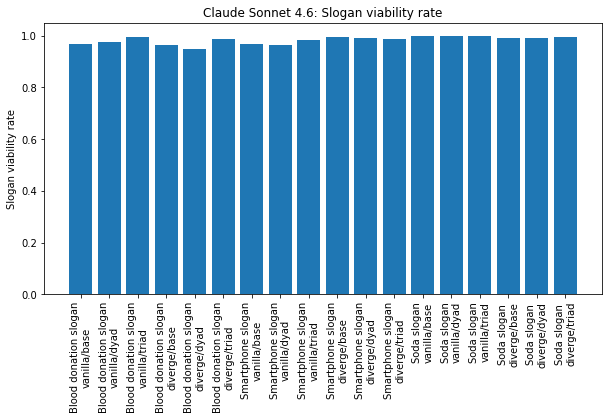

Saved figure: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/figures/slogan_viability_rate_by_condition_final_gpt_5_4.pdf


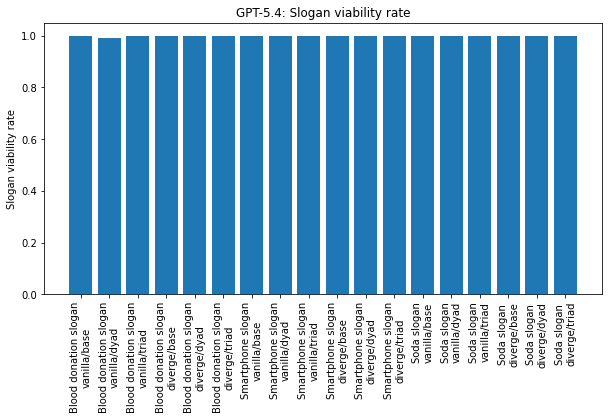

Saved figure: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/figures/slogan_viability_rate_by_condition_final_gemini_2_5_pro.pdf


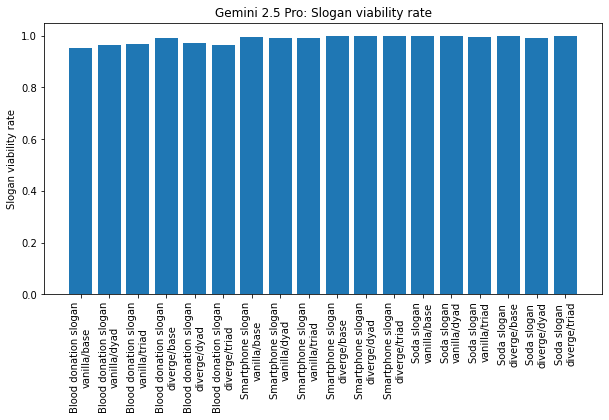

Saved figure: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/figures/slogan_task_fit_margin_by_condition_final_claude_sonnet_4_6.pdf


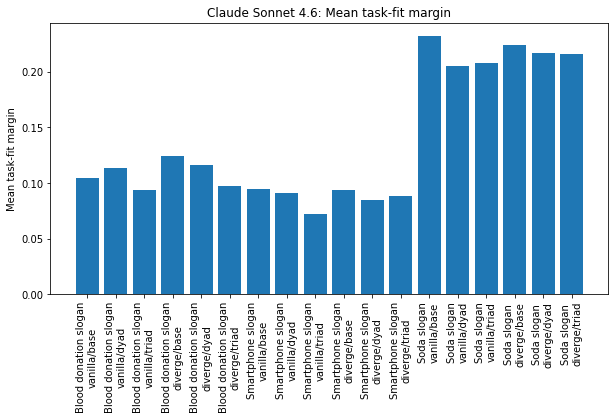

Saved figure: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/figures/slogan_task_fit_margin_by_condition_final_gpt_5_4.pdf


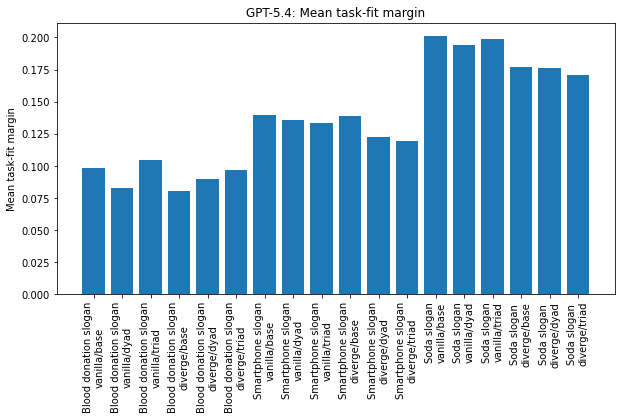

Saved figure: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/figures/slogan_task_fit_margin_by_condition_final_gemini_2_5_pro.pdf


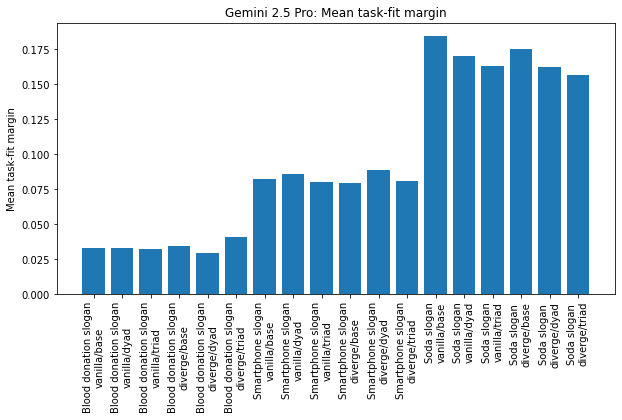

Saved figure: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/figures/slogan_phrase_non_template_by_condition_final_claude_sonnet_4_6.pdf


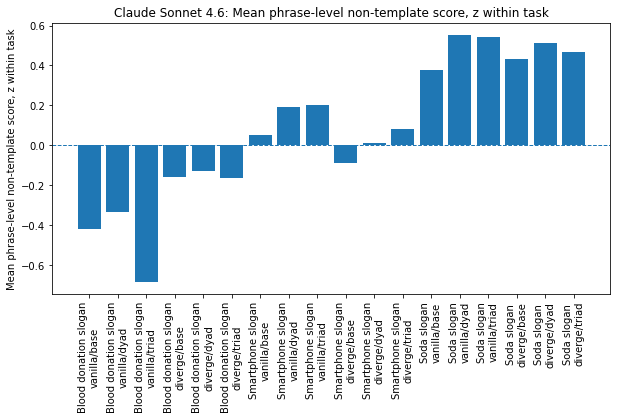

Saved figure: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/figures/slogan_phrase_non_template_by_condition_final_gpt_5_4.pdf


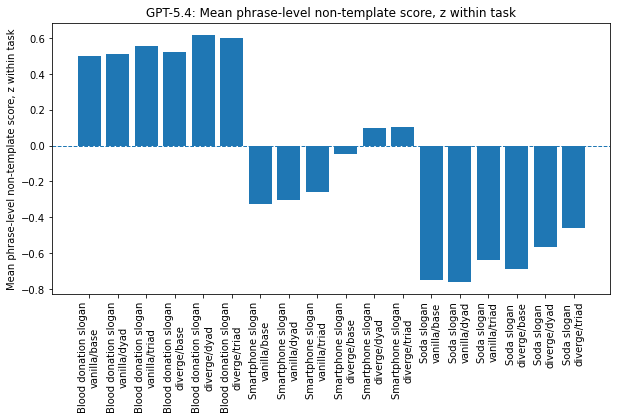

Saved figure: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/figures/slogan_phrase_non_template_by_condition_final_gemini_2_5_pro.pdf


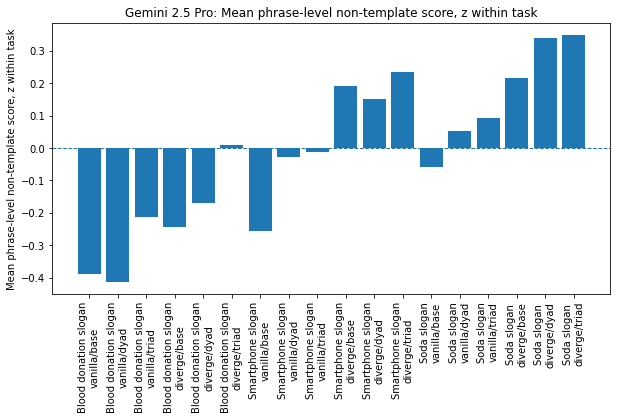

In [44]:
# -------------------------------------------------------------------
# Quick descriptive plots only -- no statistical tests yet
# -------------------------------------------------------------------

def plot_slogan_metric_by_condition(metric_col: str, ylabel: str, filename: str, zero_line: bool = False) -> None:
    plot_df = (
        slogan_cell_quality_summary
        .groupby(["provider_label", "task_label", "strategy", "condition"], observed=True)
        .agg(mean_metric=(metric_col, "mean"))
        .reset_index()
    )

    for provider_label in plot_df["provider_label"].unique():
        sub = plot_df[plot_df["provider_label"].eq(provider_label)].copy()

        fig, ax = plt.subplots(figsize=(10, 5))

        labels = []
        vals = []

        for task_label in sorted(sub["task_label"].unique()):
            for strategy in STRATEGY_ORDER:
                for condition in CONDITION_ORDER:
                    row = sub[
                        sub["task_label"].eq(task_label)
                        & sub["strategy"].eq(strategy)
                        & sub["condition"].eq(condition)
                    ]

                    labels.append(f"{task_label}\n{strategy}/{condition}")
                    vals.append(float(row["mean_metric"].iloc[0]) if len(row) else np.nan)

        ax.bar(np.arange(len(vals)), vals)
        ax.set_xticks(np.arange(len(vals)))
        ax.set_xticklabels(labels, rotation=90)
        ax.set_ylabel(ylabel)
        ax.set_title(f"{provider_label}: {ylabel}")

        if zero_line:
            ax.axhline(0, linestyle="--", linewidth=1)

        savefig_pdf(fig, f"{filename}_{safe_slug(provider_label)}")
        plt.show()


plot_slogan_metric_by_condition(
    metric_col="viability_rate",
    ylabel="Slogan viability rate",
    filename="slogan_viability_rate_by_condition_final",
    zero_line=False,
)

plot_slogan_metric_by_condition(
    metric_col="mean_task_fit_margin",
    ylabel="Mean task-fit margin",
    filename="slogan_task_fit_margin_by_condition_final",
    zero_line=True,
)

plot_slogan_metric_by_condition(
    metric_col="mean_lexical_non_template_z_task",
    ylabel="Mean phrase-level non-template score, z within task",
    filename="slogan_phrase_non_template_by_condition_final",
    zero_line=True,
)

In [45]:
# -------------------------------------------------------------------
# Save final slogan metric manifest
# -------------------------------------------------------------------

slogan_metric_manifest = {
    "quality_run_id": QUALITY_RUN_ID,
    "created_at_utc": dt.datetime.now(dt.timezone.utc).isoformat(),
    "diversity_analysis_root": str(DIVERSITY_ANALYSIS_ROOT),
    "data_pickle_path": str(data_pickle_path),
    "quality_output_root": str(QUALITY_OUTPUT_ROOT),
    "slogan_quality_metrics_parquet": str(slogan_quality_path),
    "slogan_quality_metrics_csv": str(slogan_quality_csv_path),
    "slogan_cell_quality_summary_csv": str(TABLE_DIR / "slogan_cell_quality_summary_final.csv"),
    "embedding_model_for_task_fit": EMBEDDING_MODEL_FOR_SLOGAN_FIT,
    "task_fit_embedding_source": task_fit_embedding_source,
    "slogan_task_briefs": SLOGAN_TASK_BRIEFS,
    "metric_definitions": {
        "slogan_viable": (
            "Nonblank, no more than 6 words, not detected as a list/multiple slogans, "
            "and no meta/refusal/instruction-leakage language."
        ),
        "slogan_fit_margin_vs_other_tasks": (
            "Cosine similarity to assigned slogan task brief minus maximum cosine similarity "
            "to the other slogan task briefs."
        ),
        "slogan_lexical_non_template_z_task": (
            "Negative within-task z-score of phrase-level leave-one-out bigram/trigram "
            "boilerplate commonness. Higher values indicate less reliance on repeated lexical templates."
        ),
    },
    "important_design_choice": (
        "Corpus-derived generic/task-specific unigram lists were not used in the main n-gram metric "
        "because they captured function words and model/task-specific phrase artifacts. The final "
        "non-template metric uses only bigram/trigram leave-one-out phrase repetition."
    ),
    "notes": [
        "These are objective quality-control metrics, not validated human creativity ratings.",
        "Reference-based semantic novelty is intentionally avoided to reduce overlap with population-level semantic diversity.",
        "LLM judges are intentionally not used.",
        "Statistical tests will be added later together with CLAUS and MAoSS quality scores.",
    ],
}

slogan_manifest_path = QUALITY_OUTPUT_ROOT / "slogan_quality_metric_manifest_final.json"
with open(slogan_manifest_path, "w", encoding="utf-8") as f:
    json.dump(slogan_metric_manifest, f, indent=2, ensure_ascii=False)

print("Saved slogan metric manifest:")
print(slogan_manifest_path)

print("\nMain file for later combined quality tests:")
print(slogan_quality_path)

Saved slogan metric manifest:
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/slogan_quality_metric_manifest_final.json

Main file for later combined quality tests:
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/slogan_quality_metrics.parquet


In [46]:
# -------------------------------------------------------------------
# Additional slogan QC summaries to paste back
# -------------------------------------------------------------------

# 1. Overall provider/task summary for the three main metrics.
slogan_metric_grand_summary = (
    slogan_quality_metrics
    .groupby(["provider", "provider_label", "model", "task_id", "task_label"], observed=True)
    .agg(
        n=("quality_row_id", "count"),

        viability_rate=("slogan_viable", "mean"),
        word_limit_ok_rate=("slogan_word_limit_ok", "mean"),

        mean_task_fit_margin=("slogan_fit_margin_vs_other_tasks", "mean"),
        median_task_fit_margin=("slogan_fit_margin_vs_other_tasks", "median"),
        q10_task_fit_margin=("slogan_fit_margin_vs_other_tasks", lambda x: np.quantile(x, 0.10)),
        task_fit_rank1_rate=("slogan_task_fit_rank1", "mean"),

        mean_lexical_non_template_z_task=("slogan_lexical_non_template_z_task", "mean"),
        median_lexical_non_template_z_task=("slogan_lexical_non_template_z_task", "median"),
        q10_lexical_non_template_z_task=("slogan_lexical_non_template_z_task", lambda x: np.quantile(x, 0.10)),

        mean_phrase_boilerplate_raw=("slogan_phrase_boilerplate_raw", "mean"),
        exact_duplicate_rate_taskwide=("slogan_has_exact_duplicate_in_task", "mean"),
        mean_exact_duplicate_rate_loo=("slogan_exact_duplicate_rate_loo", "mean"),
    )
    .reset_index()
)

export_table(slogan_metric_grand_summary, "slogan_metric_grand_summary")
display(slogan_metric_grand_summary)

,provider,provider_label,model,task_id,task_label,n,viability_rate,word_limit_ok_rate,mean_task_fit_margin,median_task_fit_margin,q10_task_fit_margin,task_fit_rank1_rate,mean_lexical_non_template_z_task,median_lexical_non_template_z_task,q10_lexical_non_template_z_task,mean_phrase_boilerplate_raw,exact_duplicate_rate_taskwide,mean_exact_duplicate_rate_loo
0,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,1800,0.972222,0.972222,0.108111,0.129130,-0.014420,0.830000,-0.314554,-0.456776,-1.603561,0.008452,0.898333,0.012592
1,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_smartphone,Smartphone slogan,1800,0.980556,0.980556,0.087357,0.106105,-0.012730,0.808333,0.076957,0.464237,-1.834026,0.008705,0.834444,0.006927
2,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_soda,Soda slogan,1800,0.994444,0.994444,0.216815,0.222996,0.105925,0.988889,0.480742,0.562063,-0.438141,0.004225,0.715556,0.003458
3,gemini,Gemini 2.5 Pro,gemini-2.5-pro,slogan_blood_donation,Blood donation slogan,1800,0.967778,0.967778,0.034077,0.012363,-0.067057,0.755556,-0.236056,-0.025558,-2.367624,0.007982,0.900556,0.015501
4,gemini,Gemini 2.5 Pro,gemini-2.5-pro,slogan_smartphone,Smartphone slogan,1800,0.994444,0.994444,0.082973,0.086989,-0.008219,0.868333,0.046092,0.107076,-1.418554,0.008932,0.881667,0.010188
5,gemini,Gemini 2.5 Pro,gemini-2.5-pro,slogan_soda,Soda slogan,1800,0.996667,0.996667,0.168540,0.175857,0.012582,0.931667,0.164392,0.310148,-0.862783,0.006034,0.794444,0.003134
6,openai,GPT-5.4,gpt-5.4,slogan_blood_donation,Blood donation slogan,1800,0.997778,0.997778,0.092066,0.065530,-0.035013,0.809444,0.550610,0.675865,-0.131843,0.003272,0.812778,0.004221
7,openai,GPT-5.4,gpt-5.4,slogan_smartphone,Smartphone slogan,1800,1.000000,1.000000,0.131654,0.127682,0.035999,0.954444,-0.123049,-0.174185,-1.498770,0.010175,0.851111,0.012348
8,openai,GPT-5.4,gpt-5.4,slogan_soda,Soda slogan,1800,1.000000,1.000000,0.186211,0.172333,0.056134,0.969444,-0.645134,-0.818128,-2.184556,0.010665,0.902222,0.014818


In [47]:
# 2. Compact cell-level table for later RQ-style testing.
slogan_quality_by_rq_cell = slogan_cell_quality_summary[
    [
        "provider",
        "provider_label",
        "model",
        "task_id",
        "task_label",
        "strategy",
        "condition",
        "anchor_count",
        "round",
        "n",
        "viability_rate",
        "mean_task_fit_margin",
        "median_task_fit_margin",
        "task_fit_rank1_rate",
        "mean_lexical_non_template_z_task",
        "median_lexical_non_template_z_task",
        "mean_phrase_boilerplate_raw",
        "exact_duplicate_rate",
        "mean_exact_duplicate_rate_loo",
    ]
].copy()

export_table(slogan_quality_by_rq_cell, "slogan_quality_by_rq_cell")
display(slogan_quality_by_rq_cell)

,provider,provider_label,model,task_id,task_label,strategy,condition,anchor_count,round,n,viability_rate,mean_task_fit_margin,median_task_fit_margin,task_fit_rank1_rate,mean_lexical_non_template_z_task,median_lexical_non_template_z_task,mean_phrase_boilerplate_raw,exact_duplicate_rate,mean_exact_duplicate_rate_loo
0,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,diverge,base,0,1,150,0.973333,0.149980,0.157094,0.993333,-1.049651,-1.311499,0.012853,0.913333,0.022699
1,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,diverge,base,0,2,150,0.953333,0.097689,0.068130,0.800000,0.729875,0.740777,0.002199,0.706667,0.000827
2,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,diverge,dyad,1,1,150,0.993333,0.149864,0.157094,0.993333,-0.948126,-1.164604,0.012245,0.940000,0.020488
3,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,diverge,dyad,1,2,150,0.906667,0.082905,0.043386,0.686667,0.690680,0.792797,0.002433,0.786667,0.002456
4,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,diverge,triad,2,1,150,0.993333,0.151505,0.157094,0.973333,-0.907748,-1.093352,0.012003,0.980000,0.020943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,openai,GPT-5.4,gpt-5.4,slogan_soda,Soda slogan,vanilla,base,0,2,150,1.000000,0.160024,0.152888,0.986667,-0.431066,-0.671312,0.009440,0.913333,0.006761
104,openai,GPT-5.4,gpt-5.4,slogan_soda,Soda slogan,vanilla,dyad,1,1,150,1.000000,0.238390,0.235347,1.000000,-1.186256,-0.818128,0.013760,0.993333,0.027110
105,openai,GPT-5.4,gpt-5.4,slogan_soda,Soda slogan,vanilla,dyad,1,2,150,1.000000,0.149509,0.152888,0.993333,-0.337036,-0.248905,0.008902,0.853333,0.005823
106,openai,GPT-5.4,gpt-5.4,slogan_soda,Soda slogan,vanilla,triad,2,1,150,1.000000,0.251997,0.288463,1.000000,-1.006246,-0.818128,0.012730,0.993333,0.029054


In [48]:
# 3. Within-cell exact duplication.
# This is more interpretable than task-wide "has duplicate somewhere".

cell_keys = [
    "provider", "model", "task_id", "strategy", "condition", "round"
]

slogan_quality_metrics["slogan_exact_count_within_cell"] = (
    slogan_quality_metrics
    .groupby(cell_keys + ["slogan_norm"], observed=True)["quality_row_id"]
    .transform("count")
)

slogan_quality_metrics["slogan_has_exact_duplicate_within_cell"] = (
    slogan_quality_metrics["slogan_exact_count_within_cell"].gt(1)
)

slogan_quality_metrics["slogan_exact_duplicate_rate_within_cell_loo"] = (
    (slogan_quality_metrics["slogan_exact_count_within_cell"] - 1)
    / (slogan_quality_metrics.groupby(cell_keys, observed=True)["quality_row_id"].transform("count") - 1)
)

slogan_within_cell_duplicate_summary = (
    slogan_quality_metrics
    .groupby(
        [
            "provider",
            "provider_label",
            "model",
            "task_id",
            "task_label",
            "strategy",
            "condition",
            "anchor_count",
            "round",
        ],
        observed=True,
    )
    .agg(
        n=("quality_row_id", "count"),
        within_cell_exact_duplicate_rate=("slogan_has_exact_duplicate_within_cell", "mean"),
        mean_within_cell_exact_duplicate_rate_loo=("slogan_exact_duplicate_rate_within_cell_loo", "mean"),
        max_exact_count_within_cell=("slogan_exact_count_within_cell", "max"),
        n_unique_slogans=("slogan_norm", "nunique"),
    )
    .reset_index()
)

slogan_within_cell_duplicate_summary["unique_slogan_rate"] = (
    slogan_within_cell_duplicate_summary["n_unique_slogans"]
    / slogan_within_cell_duplicate_summary["n"]
)

export_table(slogan_within_cell_duplicate_summary, "slogan_within_cell_duplicate_summary")
display(slogan_within_cell_duplicate_summary)

,provider,provider_label,model,task_id,task_label,strategy,condition,anchor_count,round,n,within_cell_exact_duplicate_rate,mean_within_cell_exact_duplicate_rate_loo,max_exact_count_within_cell,n_unique_slogans,unique_slogan_rate
0,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,diverge,base,0,1,150,0.840000,0.159911,52,35,0.233333
1,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,diverge,base,0,2,150,0.553333,0.010738,7,93,0.620000
2,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,diverge,dyad,1,1,150,0.900000,0.127069,45,33,0.220000
3,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,diverge,dyad,1,2,150,0.640000,0.036152,18,74,0.493333
4,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,diverge,triad,2,1,150,0.913333,0.126353,41,29,0.193333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,openai,GPT-5.4,gpt-5.4,slogan_soda,Soda slogan,vanilla,base,0,2,150,0.800000,0.054676,24,51,0.340000
104,openai,GPT-5.4,gpt-5.4,slogan_soda,Soda slogan,vanilla,dyad,1,1,150,0.973333,0.181924,41,12,0.080000
105,openai,GPT-5.4,gpt-5.4,slogan_soda,Soda slogan,vanilla,dyad,1,2,150,0.713333,0.053244,26,61,0.406667
106,openai,GPT-5.4,gpt-5.4,slogan_soda,Soda slogan,vanilla,triad,2,1,150,0.966667,0.212528,47,13,0.086667


In [49]:
# 4. Most repeated exact slogans by task/provider.
slogan_exact_repetition_table = (
    slogan_quality_metrics
    .groupby(["task_id", "task_label", "provider", "provider_label", "slogan_norm"], observed=True)
    .agg(
        count=("quality_row_id", "count"),
        example_slogan=("slogan_text", "first"),
        n_conditions=("condition", "nunique"),
        n_strategies=("strategy", "nunique"),
        n_rounds=("round", "nunique"),
        mean_task_fit_margin=("slogan_fit_margin_vs_other_tasks", "mean"),
        mean_lexical_non_template_z_task=("slogan_lexical_non_template_z_task", "mean"),
    )
    .reset_index()
    .sort_values(["task_id", "provider", "count"], ascending=[True, True, False])
)

slogan_exact_repetition_top = (
    slogan_exact_repetition_table
    .groupby(["task_id", "provider"], observed=True)
    .head(20)
    .reset_index(drop=True)
)

export_table(slogan_exact_repetition_top, "slogan_exact_repetition_top_by_task_provider")
display(slogan_exact_repetition_top)

,task_id,task_label,provider,provider_label,slogan_norm,count,example_slogan,n_conditions,n_strategies,n_rounds,mean_task_fit_margin,mean_lexical_non_template_z_task
0,slogan_blood_donation,Blood donation slogan,anthropic,Claude Sonnet 4.6,your blood someone's second chance,207,"Your blood, someone's second chance.",3,2,1,0.156610,-1.412025
1,slogan_blood_donation,Blood donation slogan,anthropic,Claude Sonnet 4.6,your blood runs through their story,163,Your blood runs through their story.,3,2,1,0.182213,-1.603561
2,slogan_blood_donation,Blood donation slogan,anthropic,Claude Sonnet 4.6,your blood their second chance,148,Your blood. Their second chance.,3,2,1,0.170390,-0.928596
3,slogan_blood_donation,Blood donation slogan,anthropic,Claude Sonnet 4.6,your blood runs in their veins,109,Your blood runs in their veins.,3,2,1,0.129130,-1.164604
4,slogan_blood_donation,Blood donation slogan,anthropic,Claude Sonnet 4.6,give life it costs you nothing,71,Give life. It costs you nothing.,3,1,1,0.145082,0.360668
...,...,...,...,...,...,...,...,...,...,...,...,...
175,slogan_soda,Soda slogan,openai,GPT-5.4,pop open the unexpected,19,Pop Open the Unexpected,3,2,1,0.046234,0.499541
176,slogan_soda,Soda slogan,openai,GPT-5.4,fizz beyond ordinary,18,Fizz Beyond Ordinary,3,2,1,0.270650,0.382351
177,slogan_soda,Soda slogan,openai,GPT-5.4,fizz the unexpected,17,Fizz the Unexpected.,3,2,1,0.237041,-0.362095
178,slogan_soda,Soda slogan,openai,GPT-5.4,pop open a daydream,16,Pop Open a Daydream,3,2,1,-0.077232,0.760452


In [50]:
# 5. Problem examples sampled from each metric.

low_fit_examples_by_task = (
    slogan_quality_metrics
    .sort_values("slogan_fit_margin_vs_other_tasks", ascending=True)
    .groupby(["task_id", "provider"], observed=True)
    .head(20)
    .reset_index(drop=True)
)

most_templated_by_task = (
    slogan_quality_metrics
    .sort_values("slogan_phrase_boilerplate_raw", ascending=False)
    .groupby(["task_id", "provider"], observed=True)
    .head(20)
    .reset_index(drop=True)
)

nonviable_examples_by_task = (
    slogan_quality_metrics
    .loc[~slogan_quality_metrics["slogan_viable"]]
    .sort_values(["task_id", "provider", "slogan_word_count_clean"], ascending=[True, True, False])
    .groupby(["task_id", "provider"], observed=True)
    .head(20)
    .reset_index(drop=True)
)

slogan_problem_examples_by_metric = pd.concat(
    [
        low_fit_examples_by_task.assign(problem_type="low_task_fit"),
        most_templated_by_task.assign(problem_type="high_phrase_boilerplate"),
        nonviable_examples_by_task.assign(problem_type="nonviable"),
    ],
    ignore_index=True,
)

example_cols = [
    "problem_type",
    "provider",
    "provider_label",
    "model",
    "task_id",
    "task_label",
    "strategy",
    "condition",
    "round",
    "group_id",
    "agent_id",
    "slogan_text",
    "slogan_word_count_clean",
    "slogan_viable",
    "slogan_fit_margin_vs_other_tasks",
    "slogan_task_fit_rank1",
    "slogan_phrase_boilerplate_raw",
    "slogan_lexical_non_template_z_task",
    "slogan_exact_duplicate_count_in_task",
]

slogan_problem_examples_by_metric = slogan_problem_examples_by_metric[
    [c for c in example_cols if c in slogan_problem_examples_by_metric.columns]
].copy()

export_table(slogan_problem_examples_by_metric, "slogan_problem_examples_by_metric")
display(slogan_problem_examples_by_metric)

,problem_type,provider,provider_label,model,task_id,task_label,strategy,condition,round,group_id,agent_id,slogan_text,slogan_word_count_clean,slogan_viable,slogan_fit_margin_vs_other_tasks,slogan_task_fit_rank1,slogan_phrase_boilerplate_raw,slogan_lexical_non_template_z_task,slogan_exact_duplicate_count_in_task
0,low_task_fit,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_smartphone,Smartphone slogan,diverge,dyad,2,dyad_074,dyad_074__a2,Sharper eyes. Softer on earth.,5,True,-0.159823,False,0.000005,1.260212,1
1,low_task_fit,gemini,Gemini 2.5 Pro,gemini-2.5-pro,slogan_blood_donation,Blood donation slogan,vanilla,triad,2,triad_003,triad_003__a3,A single drop can start a ripple.,7,False,-0.145551,False,0.001071,0.918122,1
2,low_task_fit,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_smartphone,Smartphone slogan,diverge,triad,2,triad_022,triad_022__a3,Silence the ordinary. Amplify everything else.,6,True,-0.136239,False,0.004563,0.640315,20
3,low_task_fit,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_smartphone,Smartphone slogan,diverge,triad,2,triad_018,triad_018__a2,Silence the ordinary. Amplify everything else.,6,True,-0.136239,False,0.004563,0.640315,20
4,low_task_fit,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_smartphone,Smartphone slogan,diverge,triad,2,triad_047,triad_047__a1,Silence the ordinary. Amplify everything else.,6,True,-0.136239,False,0.004563,0.640315,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,nonviable,gemini,Gemini 2.5 Pro,gemini-2.5-pro,slogan_soda,Soda slogan,diverge,dyad,1,dyad_007,dyad_007__a1,Your taste buds are about to riot.,7,False,0.176235,True,0.001980,0.873169,1
446,nonviable,gemini,Gemini 2.5 Pro,gemini-2.5-pro,slogan_soda,Soda slogan,diverge,dyad,1,dyad_038,dyad_038__a2,Where your taste buds go on vacation.,7,False,0.121996,True,0.001910,0.885301,1
447,nonviable,gemini,Gemini 2.5 Pro,gemini-2.5-pro,slogan_soda,Soda slogan,diverge,dyad,2,dyad_059,dyad_059__a2,Your taste buds are about to migrate.,7,False,0.090345,True,0.001980,0.873169,1
448,nonviable,gemini,Gemini 2.5 Pro,gemini-2.5-pro,slogan_soda,Soda slogan,vanilla,dyad,1,dyad_041,dyad_041__a2,Taste the fizz of a new era.,7,False,0.286984,True,0.006397,0.100944,1


In [51]:
# -------------------------------------------------------------------
# Freeze final slogan quality-control metrics for later statistical tests
# -------------------------------------------------------------------

FINAL_SLOGAN_QC_METRICS = {
    "slogan_viable": {
        "metric_family": "slogan_qc",
        "metric_label": "Task compliance",
        "metric_type": "binary",
        "higher_is_better": True,
        "description": "Nonblank, <=6 words, not list/multiple slogans, no meta/refusal language.",
    },
    "slogan_fit_margin_vs_other_tasks": {
        "metric_family": "slogan_qc",
        "metric_label": "Semantic task appropriateness",
        "metric_type": "continuous",
        "higher_is_better": True,
        "description": "Similarity to assigned slogan task brief minus max similarity to other slogan task briefs.",
    },
    "slogan_lexical_non_template_z_task": {
        "metric_family": "slogan_qc",
        "metric_label": "Phrase-level non-template score",
        "metric_type": "continuous_z",
        "higher_is_better": True,
        "description": "Negative within-task z-score of leave-one-out bigram/trigram boilerplate commonness.",
    },
}

required_cols = list(FINAL_SLOGAN_QC_METRICS.keys())
missing_cols = [c for c in required_cols if c not in slogan_quality_metrics.columns]

if missing_cols:
    raise RuntimeError(f"Missing final slogan QC metric columns: {missing_cols}")

slogan_quality_main_wide = slogan_quality_metrics[
    [
        "quality_row_id",
        "provider",
        "provider_label",
        "model",
        "task_id",
        "task_label",
        "task_family",
        "task_family_label",
        "strategy",
        "condition",
        "anchor_count",
        "round",
        "group_id",
        "agent_id",
        "agent_index",
        "request_key",
        "text_id",
        "slogan_text",
    ]
    + required_cols
].copy()

# Ensure numeric test columns.
slogan_quality_main_wide["slogan_viable"] = slogan_quality_main_wide["slogan_viable"].astype(float)

for col in required_cols:
    slogan_quality_main_wide[col] = pd.to_numeric(slogan_quality_main_wide[col], errors="coerce")

# Main tests should use all successful slogan outputs, not condition on viability.
# Viability is itself the compliance outcome.
qc_missing = slogan_quality_main_wide[required_cols].isna().sum().reset_index()
qc_missing.columns = ["metric", "n_missing"]

export_table(qc_missing, "final_slogan_qc_missingness")
display(qc_missing)

if qc_missing["n_missing"].sum() > 0:
    display(
        slogan_quality_main_wide.loc[
            slogan_quality_main_wide[required_cols].isna().any(axis=1),
            ["provider", "task_id", "strategy", "condition", "round", "slogan_text"] + required_cols
        ].head(50)
    )

,metric,n_missing
0,slogan_viable,0
1,slogan_fit_margin_vs_other_tasks,0
2,slogan_lexical_non_template_z_task,0


In [52]:
# -------------------------------------------------------------------
# Long-format version for combined quality bootstrap later
# -------------------------------------------------------------------

id_vars = [
    "quality_row_id",
    "provider",
    "provider_label",
    "model",
    "task_id",
    "task_label",
    "task_family",
    "task_family_label",
    "strategy",
    "condition",
    "anchor_count",
    "round",
    "group_id",
    "agent_id",
    "agent_index",
    "request_key",
    "text_id",
    "slogan_text",
]

slogan_quality_main_long = slogan_quality_main_wide.melt(
    id_vars=id_vars,
    value_vars=required_cols,
    var_name="quality_metric",
    value_name="quality_value",
)

metric_meta = pd.DataFrame([
    {
        "quality_metric": metric,
        **meta,
    }
    for metric, meta in FINAL_SLOGAN_QC_METRICS.items()
])

slogan_quality_main_long = slogan_quality_main_long.merge(
    metric_meta,
    on="quality_metric",
    how="left",
    validate="many_to_one",
)

# Explicit source label for later merging with AUT/Story quality data.
slogan_quality_main_long["quality_source"] = "slogan_objective_qc"
slogan_quality_main_long["quality_score_raw"] = slogan_quality_main_long["quality_value"]

# For later non-inferiority tests, all three metrics are already oriented so higher is better.
assert slogan_quality_main_long["higher_is_better"].all()

display(slogan_quality_main_long.head())

,quality_row_id,provider,provider_label,model,task_id,task_label,task_family,task_family_label,strategy,condition,...,slogan_text,quality_metric,quality_value,metric_family,metric_label,metric_type,higher_is_better,description,quality_source,quality_score_raw
0,b3480279b44a26b98471fccb,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,slogan,Slogan,diverge,base,...,"Your blood, someone's second chance.",slogan_viable,1.0,slogan_qc,Task compliance,binary,True,"Nonblank, <=6 words, not list/multiple slogans...",slogan_objective_qc,1.0
1,572a1c315b11351a6dd530c8,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,slogan,Slogan,diverge,base,...,Give a little. Someone lives more.,slogan_viable,1.0,slogan_qc,Task compliance,binary,True,"Nonblank, <=6 words, not list/multiple slogans...",slogan_objective_qc,1.0
2,37030daaa52c7092a45e132b,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,slogan,Slogan,diverge,base,...,Your blood runs in someone's future.,slogan_viable,1.0,slogan_qc,Task compliance,binary,True,"Nonblank, <=6 words, not list/multiple slogans...",slogan_objective_qc,1.0
3,6498351eb424bb8657da66fa,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,slogan,Slogan,diverge,base,...,One vein connects two beating hearts.,slogan_viable,1.0,slogan_qc,Task compliance,binary,True,"Nonblank, <=6 words, not list/multiple slogans...",slogan_objective_qc,1.0
4,17344ada6f671c8219384c70,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,slogan,Slogan,diverge,base,...,Your blood runs through their story.,slogan_viable,1.0,slogan_qc,Task compliance,binary,True,"Nonblank, <=6 words, not list/multiple slogans...",slogan_objective_qc,1.0


In [53]:
# -------------------------------------------------------------------
# Cell-level summaries for only the final three metrics
# -------------------------------------------------------------------

slogan_quality_main_cell = (
    slogan_quality_main_long
    .groupby(
        [
            "provider",
            "provider_label",
            "model",
            "task_id",
            "task_label",
            "task_family",
            "task_family_label",
            "strategy",
            "condition",
            "anchor_count",
            "round",
            "quality_metric",
            "metric_label",
            "metric_type",
            "quality_source",
        ],
        observed=True,
    )
    .agg(
        n=("quality_row_id", "count"),
        mean_quality=("quality_value", "mean"),
        median_quality=("quality_value", "median"),
        sd_quality=("quality_value", "std"),
        q10_quality=("quality_value", lambda x: np.quantile(x, 0.10)),
        q90_quality=("quality_value", lambda x: np.quantile(x, 0.90)),
    )
    .reset_index()
)

export_table(slogan_quality_main_cell, "final_slogan_qc_cell_summary")
display(slogan_quality_main_cell.head(40))

,provider,provider_label,model,task_id,task_label,task_family,task_family_label,strategy,condition,anchor_count,...,quality_metric,metric_label,metric_type,quality_source,n,mean_quality,median_quality,sd_quality,q10_quality,q90_quality
0,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,slogan,Slogan,diverge,base,0,...,slogan_fit_margin_vs_other_tasks,Semantic task appropriateness,continuous,slogan_objective_qc,150,0.149980,0.157094,0.045598,0.106003,0.182213
1,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,slogan,Slogan,diverge,base,0,...,slogan_lexical_non_template_z_task,Phrase-level non-template score,continuous_z,slogan_objective_qc,150,-1.049651,-1.311499,0.629007,-1.603561,-0.389783
2,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,slogan,Slogan,diverge,base,0,...,slogan_viable,Task compliance,binary,slogan_objective_qc,150,0.973333,1.000000,0.161647,1.000000,1.000000
3,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,slogan,Slogan,diverge,base,0,...,slogan_fit_margin_vs_other_tasks,Semantic task appropriateness,continuous,slogan_objective_qc,150,0.097689,0.068130,0.118298,-0.021947,0.304182
4,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,slogan,Slogan,diverge,base,0,...,slogan_lexical_non_template_z_task,Phrase-level non-template score,continuous_z,slogan_objective_qc,150,0.729875,0.740777,0.314913,0.350469,1.073667
5,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,slogan,Slogan,diverge,base,0,...,slogan_viable,Task compliance,binary,slogan_objective_qc,150,0.953333,1.000000,0.211631,1.000000,1.000000
6,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,slogan,Slogan,diverge,dyad,1,...,slogan_fit_margin_vs_other_tasks,Semantic task appropriateness,continuous,slogan_objective_qc,150,0.149864,0.157094,0.050942,0.094186,0.187875
7,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,slogan,Slogan,diverge,dyad,1,...,slogan_lexical_non_template_z_task,Phrase-level non-template score,continuous_z,slogan_objective_qc,150,-0.948126,-1.164604,0.694206,-1.603561,0.109093
8,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,slogan,Slogan,diverge,dyad,1,...,slogan_viable,Task compliance,binary,slogan_objective_qc,150,0.993333,1.000000,0.081650,1.000000,1.000000
9,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,slogan_blood_donation,Blood donation slogan,slogan,Slogan,diverge,dyad,1,...,slogan_fit_margin_vs_other_tasks,Semantic task appropriateness,continuous,slogan_objective_qc,150,0.082905,0.043386,0.120271,-0.029472,0.334384


In [54]:
# -------------------------------------------------------------------
# Save final slogan QC files
# -------------------------------------------------------------------

slogan_quality_main_wide_path = QUALITY_OUTPUT_ROOT / "final_slogan_qc_metrics_wide.parquet"
slogan_quality_main_long_path = QUALITY_OUTPUT_ROOT / "final_slogan_qc_metrics_long.parquet"

slogan_quality_main_wide_csv = TABLE_DIR / "final_slogan_qc_metrics_wide.csv"
slogan_quality_main_long_csv = TABLE_DIR / "final_slogan_qc_metrics_long.csv"

slogan_quality_main_wide.to_parquet(slogan_quality_main_wide_path, index=False)
slogan_quality_main_long.to_parquet(slogan_quality_main_long_path, index=False)

slogan_quality_main_wide.to_csv(slogan_quality_main_wide_csv, index=False)
slogan_quality_main_long.to_csv(slogan_quality_main_long_csv, index=False)

final_slogan_qc_manifest = {
    "created_at_utc": dt.datetime.now(dt.timezone.utc).isoformat(),
    "quality_run_id": QUALITY_RUN_ID,
    "quality_output_root": str(QUALITY_OUTPUT_ROOT),
    "wide_parquet": str(slogan_quality_main_wide_path),
    "long_parquet": str(slogan_quality_main_long_path),
    "wide_csv": str(slogan_quality_main_wide_csv),
    "long_csv": str(slogan_quality_main_long_csv),
    "final_metrics": FINAL_SLOGAN_QC_METRICS,
    "main_analysis_rule": (
        "Use all successful slogan outputs for all three QC metrics. "
        "Do not condition task-fit or non-template tests on viability; viability is analyzed separately."
    ),
    "excluded_from_main_tests": [
        "slogan_task_fit_rank1",
        "slogan_has_exact_duplicate_in_task",
        "slogan_exact_duplicate_rate_loo",
        "slogan_phrase_boilerplate_raw",
        "diagnostic example tables",
    ],
}

final_slogan_qc_manifest_path = QUALITY_OUTPUT_ROOT / "final_slogan_qc_manifest.json"

with open(final_slogan_qc_manifest_path, "w", encoding="utf-8") as f:
    json.dump(final_slogan_qc_manifest, f, indent=2, ensure_ascii=False)

print("Saved final slogan QC files:")
print(slogan_quality_main_wide_path)
print(slogan_quality_main_long_path)
print(final_slogan_qc_manifest_path)

Saved final slogan QC files:
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/final_slogan_qc_metrics_wide.parquet
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/final_slogan_qc_metrics_long.parquet
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/final_slogan_qc_manifest.json


In [55]:
# -------------------------------------------------------------------
# Process returned CLAUS scores for AUT
# -------------------------------------------------------------------

PREPARED_DIR = QUALITY_OUTPUT_ROOT / "prepared_quality_metrics"
PREPARED_DIR.mkdir(parents=True, exist_ok=True)

claus_returned_path = RETURNED_DIR / "CLAUS_returned_AUT_all_models.csv"

if not claus_returned_path.exists():
    # Flexible fallback if the browser/download changed the filename slightly.
    candidates = sorted(RETURNED_DIR.glob("*CLAUS*AUT*.csv"))
    if len(candidates) == 1:
        claus_returned_path = candidates[0]
        print("Using detected CLAUS file:")
        print(claus_returned_path)
    elif len(candidates) > 1:
        print("Found multiple possible CLAUS files:")
        for p in candidates:
            print("  ", p)
        raise FileNotFoundError("Please set claus_returned_path manually.")
    else:
        raise FileNotFoundError(
            f"Could not find CLAUS returned file at {claus_returned_path}. "
            "Place the returned CSV in RETURNED_DIR."
        )

claus_returned = pd.read_csv(claus_returned_path, encoding="utf-8-sig")

print("Loaded CLAUS returned file:")
print(claus_returned_path)
print(claus_returned.shape)
display(claus_returned.head())
print(claus_returned.columns.tolist())

Loaded CLAUS returned file:
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_returned_csvs/CLAUS_returned_AUT_all_models.csv
(27000, 27)


,item,response,quality_row_id,cap_upload_row,provider,provider_label,model,task_id,task_label,task_family,...,agent_index,request_key,text_id,word_count,response_word_count,response_n_chars,common_use,prediction,modelname,text
0,automobile tire,"stacked and filled with soil, used as a raised...",77d993b7312d5725704355e1,1,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,...,1,r1__ed4b70c212cc324219b1d60f,77d993b7312d5725704355e1,26,26,140,used on the wheel of an automobile,0.66,CLAUS,"Identify how surprising, creative, unexpected,..."
1,automobile tire,hung vertically from a dock piling as a cushio...,a7ca7d0c97763df33e263a25,2,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,...,1,r2__668c1941d0a0da8f68ddd2f2,a7ca7d0c97763df33e263a25,21,21,118,used on the wheel of an automobile,0.63,CLAUS,"Identify how surprising, creative, unexpected,..."
2,automobile tire,strung horizontally between two trees with rop...,c6ed12918022f46d1b9f228f,3,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,...,1,r1__943c81b2745feadd05d09e9f,c6ed12918022f46d1b9f228f,24,24,163,used on the wheel of an automobile,0.64,CLAUS,"Identify how surprising, creative, unexpected,..."
3,automobile tire,"the rubber sidewall, cut into strips and woven...",0ef3e63cf1bc12bd55c75022,4,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,...,1,r2__8a94adc496b363405ff863ba,0ef3e63cf1bc12bd55c75022,21,21,132,used on the wheel of an automobile,0.66,CLAUS,"Identify how surprising, creative, unexpected,..."
4,automobile tire,suspend a tire vertically from a sturdy tree b...,ea8965b9ba248aabfc23dd31,5,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,...,1,r1__47e676e0a2df1bfb1e9d9183,ea8965b9ba248aabfc23dd31,29,29,186,used on the wheel of an automobile,0.78,CLAUS,"Identify how surprising, creative, unexpected,..."


['item', 'response', 'quality_row_id', 'cap_upload_row', 'provider', 'provider_label', 'model', 'task_id', 'task_label', 'task_family', 'task_family_label', 'strategy', 'condition', 'anchor_count', 'round', 'group_id', 'agent_id', 'agent_index', 'request_key', 'text_id', 'word_count', 'response_word_count', 'response_n_chars', 'common_use', 'prediction', 'modelname', 'text']


In [56]:
# -------------------------------------------------------------------
# Validate and standardize CLAUS columns
# -------------------------------------------------------------------

required_claus_cols = [
    "quality_row_id",
    "provider",
    "provider_label",
    "model",
    "task_id",
    "task_label",
    "task_family",
    "task_family_label",
    "strategy",
    "condition",
    "anchor_count",
    "round",
    "group_id",
    "agent_id",
    "agent_index",
    "request_key",
    "text_id",
    "item",
    "response",
    "prediction",
    "modelname",
]

missing = [c for c in required_claus_cols if c not in claus_returned.columns]
if missing:
    raise RuntimeError(f"CLAUS returned file is missing required columns: {missing}")

aut_quality_main_wide = claus_returned.copy()

# Numeric score.
aut_quality_main_wide["claus_prediction"] = pd.to_numeric(
    aut_quality_main_wide["prediction"],
    errors="coerce",
)

# Basic cleanup / types.
aut_quality_main_wide["quality_row_id"] = aut_quality_main_wide["quality_row_id"].astype(str)
aut_quality_main_wide["task_family"] = aut_quality_main_wide["task_family"].astype(str)
aut_quality_main_wide["round"] = aut_quality_main_wide["round"].astype(int)
aut_quality_main_wide["anchor_count"] = aut_quality_main_wide["anchor_count"].astype(int)

# Defensive checks.
if not aut_quality_main_wide["task_family"].eq("aut").all():
    bad = aut_quality_main_wide["task_family"].value_counts(dropna=False)
    raise RuntimeError(f"CLAUS file contains non-AUT task_family values:\n{bad}")

if aut_quality_main_wide["quality_row_id"].duplicated().any():
    dupes = aut_quality_main_wide.loc[
        aut_quality_main_wide["quality_row_id"].duplicated(keep=False),
        ["quality_row_id", "provider", "task_id", "strategy", "condition", "round", "response"]
    ]
    display(dupes.head(50))
    raise RuntimeError("Duplicate quality_row_id values found in CLAUS file.")

if aut_quality_main_wide["claus_prediction"].isna().any():
    bad = aut_quality_main_wide.loc[
        aut_quality_main_wide["claus_prediction"].isna(),
        ["quality_row_id", "item", "response", "prediction"]
    ]
    display(bad.head(50))
    raise RuntimeError("Some CLAUS predictions could not be parsed as numeric.")

print("CLAUS validation passed.")
print("Rows:", len(aut_quality_main_wide))
print("Tasks:", sorted(aut_quality_main_wide["task_id"].unique()))
print("Prediction range:", aut_quality_main_wide["claus_prediction"].min(), aut_quality_main_wide["claus_prediction"].max())

CLAUS validation passed.
Rows: 27000
Tasks: ['aut_automobile_tire', 'aut_button', 'aut_key', 'aut_shoe', 'aut_wooden_pencil']
Prediction range: 0.46 0.82


In [57]:
# -------------------------------------------------------------------
# Add standardized versions for diagnostics / robustness
# -------------------------------------------------------------------
# Main statistical tests can use raw CLAUS prediction.
# The z-score columns are useful for cross-task descriptive summaries.

aut_quality_main_wide["claus_prediction_z_task"] = (
    aut_quality_main_wide
    .groupby("task_id", observed=True)["claus_prediction"]
    .transform(lambda x: (x - x.mean()) / x.std(ddof=0))
)

aut_quality_main_wide["claus_prediction_z_provider_task"] = (
    aut_quality_main_wide
    .groupby(["provider", "task_id"], observed=True)["claus_prediction"]
    .transform(lambda x: (x - x.mean()) / x.std(ddof=0))
)

claus_qc_summary = (
    aut_quality_main_wide
    .groupby(["provider", "provider_label", "task_id", "task_label"], observed=True)
    .agg(
        n=("quality_row_id", "count"),
        mean_claus=("claus_prediction", "mean"),
        sd_claus=("claus_prediction", "std"),
        median_claus=("claus_prediction", "median"),
        min_claus=("claus_prediction", "min"),
        max_claus=("claus_prediction", "max"),
        mean_word_count=("response_word_count", "mean"),
    )
    .reset_index()
)

export_table(claus_qc_summary, "final_aut_claus_qc_summary")
display(claus_qc_summary)

,provider,provider_label,task_id,task_label,n,mean_claus,sd_claus,median_claus,min_claus,max_claus,mean_word_count
0,anthropic,Claude Sonnet 4.6,aut_automobile_tire,AUT: automobile tire,1800,0.629628,0.058469,0.63,0.46,0.78,23.460000
1,anthropic,Claude Sonnet 4.6,aut_button,AUT: button,1800,0.667978,0.043708,0.66,0.50,0.81,19.312222
2,anthropic,Claude Sonnet 4.6,aut_key,AUT: key,1800,0.652928,0.038853,0.65,0.53,0.80,20.972222
3,anthropic,Claude Sonnet 4.6,aut_shoe,AUT: shoe,1800,0.676400,0.048402,0.68,0.49,0.81,21.652778
4,anthropic,Claude Sonnet 4.6,aut_wooden_pencil,AUT: wooden pencil,1800,0.658689,0.040547,0.66,0.52,0.78,21.407778
5,gemini,Gemini 2.5 Pro,aut_automobile_tire,AUT: automobile tire,1800,0.650694,0.060273,0.65,0.51,0.81,15.591111
6,gemini,Gemini 2.5 Pro,aut_button,AUT: button,1800,0.658956,0.051398,0.66,0.51,0.82,12.407778
7,gemini,Gemini 2.5 Pro,aut_key,AUT: key,1800,0.671394,0.043390,0.67,0.50,0.81,14.593333
8,gemini,Gemini 2.5 Pro,aut_shoe,AUT: shoe,1800,0.654456,0.041410,0.66,0.51,0.80,16.106111
9,gemini,Gemini 2.5 Pro,aut_wooden_pencil,AUT: wooden pencil,1800,0.638550,0.056166,0.63,0.50,0.78,13.351667


In [58]:
# -------------------------------------------------------------------
# Freeze AUT analysis-ready wide file
# -------------------------------------------------------------------

FINAL_AUT_QUALITY_METRICS = {
    "claus_prediction": {
        "metric_family": "validated_aut_quality",
        "metric_label": "CLAUS creativity score",
        "metric_type": "continuous",
        "higher_is_better": True,
        "description": "CLAUS neural score for Alternate Uses Task responses.",
    }
}

aut_keep_cols = [
    "quality_row_id",
    "cap_upload_row",
    "provider",
    "provider_label",
    "model",
    "task_id",
    "task_label",
    "task_family",
    "task_family_label",
    "strategy",
    "condition",
    "anchor_count",
    "round",
    "group_id",
    "agent_id",
    "agent_index",
    "request_key",
    "text_id",
    "item",
    "response",
    "common_use",
    "response_word_count",
    "response_n_chars",
    "claus_prediction",
    "claus_prediction_z_task",
    "claus_prediction_z_provider_task",
    "modelname",
]

aut_quality_main_wide = aut_quality_main_wide[
    [c for c in aut_keep_cols if c in aut_quality_main_wide.columns]
].copy()

# Consistent naming for later combined analysis.
aut_quality_main_wide["quality_source"] = "CLAUS"
aut_quality_main_wide["quality_metric_primary"] = "claus_prediction"

display(aut_quality_main_wide.head())

,quality_row_id,cap_upload_row,provider,provider_label,model,task_id,task_label,task_family,task_family_label,strategy,...,response,common_use,response_word_count,response_n_chars,claus_prediction,claus_prediction_z_task,claus_prediction_z_provider_task,modelname,quality_source,quality_metric_primary
0,77d993b7312d5725704355e1,1,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,Alternative uses,diverge,...,"stacked and filled with soil, used as a raised...",used on the wheel of an automobile,26,140,0.66,0.339216,0.519605,CLAUS,CLAUS,claus_prediction
1,a7ca7d0c97763df33e263a25,2,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,Alternative uses,diverge,...,hung vertically from a dock piling as a cushio...,used on the wheel of an automobile,21,118,0.63,-0.206007,0.006368,CLAUS,CLAUS,claus_prediction
2,c6ed12918022f46d1b9f228f,3,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,Alternative uses,diverge,...,strung horizontally between two trees with rop...,used on the wheel of an automobile,24,163,0.64,-0.024266,0.177447,CLAUS,CLAUS,claus_prediction
3,0ef3e63cf1bc12bd55c75022,4,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,Alternative uses,diverge,...,"the rubber sidewall, cut into strips and woven...",used on the wheel of an automobile,21,132,0.66,0.339216,0.519605,CLAUS,CLAUS,claus_prediction
4,ea8965b9ba248aabfc23dd31,5,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,Alternative uses,diverge,...,suspend a tire vertically from a sturdy tree b...,used on the wheel of an automobile,29,186,0.78,2.520109,2.572554,CLAUS,CLAUS,claus_prediction


In [59]:
# -------------------------------------------------------------------
# Create AUT long-format quality file for combined analysis
# -------------------------------------------------------------------

aut_id_vars = [
    "quality_row_id",
    "cap_upload_row",
    "provider",
    "provider_label",
    "model",
    "task_id",
    "task_label",
    "task_family",
    "task_family_label",
    "strategy",
    "condition",
    "anchor_count",
    "round",
    "group_id",
    "agent_id",
    "agent_index",
    "request_key",
    "text_id",
    "item",
    "response",
    "common_use",
    "response_word_count",
    "response_n_chars",
]

aut_quality_main_long = aut_quality_main_wide.melt(
    id_vars=[c for c in aut_id_vars if c in aut_quality_main_wide.columns],
    value_vars=["claus_prediction"],
    var_name="quality_metric",
    value_name="quality_value",
)

aut_metric_meta = pd.DataFrame([
    {
        "quality_metric": metric,
        **meta,
    }
    for metric, meta in FINAL_AUT_QUALITY_METRICS.items()
])

aut_quality_main_long = aut_quality_main_long.merge(
    aut_metric_meta,
    on="quality_metric",
    how="left",
    validate="many_to_one",
)

aut_quality_main_long["quality_source"] = "CLAUS"
aut_quality_main_long["quality_score_raw"] = aut_quality_main_long["quality_value"]

assert aut_quality_main_long["higher_is_better"].all()

display(aut_quality_main_long.head())

,quality_row_id,cap_upload_row,provider,provider_label,model,task_id,task_label,task_family,task_family_label,strategy,...,response_n_chars,quality_metric,quality_value,metric_family,metric_label,metric_type,higher_is_better,description,quality_source,quality_score_raw
0,77d993b7312d5725704355e1,1,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,Alternative uses,diverge,...,140,claus_prediction,0.66,validated_aut_quality,CLAUS creativity score,continuous,True,CLAUS neural score for Alternate Uses Task res...,CLAUS,0.66
1,a7ca7d0c97763df33e263a25,2,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,Alternative uses,diverge,...,118,claus_prediction,0.63,validated_aut_quality,CLAUS creativity score,continuous,True,CLAUS neural score for Alternate Uses Task res...,CLAUS,0.63
2,c6ed12918022f46d1b9f228f,3,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,Alternative uses,diverge,...,163,claus_prediction,0.64,validated_aut_quality,CLAUS creativity score,continuous,True,CLAUS neural score for Alternate Uses Task res...,CLAUS,0.64
3,0ef3e63cf1bc12bd55c75022,4,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,Alternative uses,diverge,...,132,claus_prediction,0.66,validated_aut_quality,CLAUS creativity score,continuous,True,CLAUS neural score for Alternate Uses Task res...,CLAUS,0.66
4,ea8965b9ba248aabfc23dd31,5,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,Alternative uses,diverge,...,186,claus_prediction,0.78,validated_aut_quality,CLAUS creativity score,continuous,True,CLAUS neural score for Alternate Uses Task res...,CLAUS,0.78


In [60]:
# -------------------------------------------------------------------
# Cell-level AUT summary for later paper tables
# -------------------------------------------------------------------

aut_quality_main_cell = (
    aut_quality_main_long
    .groupby(
        [
            "provider",
            "provider_label",
            "model",
            "task_id",
            "task_label",
            "task_family",
            "task_family_label",
            "strategy",
            "condition",
            "anchor_count",
            "round",
            "quality_metric",
            "metric_label",
            "metric_type",
            "quality_source",
        ],
        observed=True,
    )
    .agg(
        n=("quality_row_id", "count"),
        mean_quality=("quality_value", "mean"),
        median_quality=("quality_value", "median"),
        sd_quality=("quality_value", "std"),
        q10_quality=("quality_value", lambda x: np.quantile(x, 0.10)),
        q90_quality=("quality_value", lambda x: np.quantile(x, 0.90)),
    )
    .reset_index()
)

export_table(aut_quality_main_cell, "final_aut_claus_cell_summary")
display(aut_quality_main_cell.head(40))

,provider,provider_label,model,task_id,task_label,task_family,task_family_label,strategy,condition,anchor_count,...,quality_metric,metric_label,metric_type,quality_source,n,mean_quality,median_quality,sd_quality,q10_quality,q90_quality
0,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,Alternative uses,diverge,base,0,...,claus_prediction,CLAUS creativity score,continuous,CLAUS,150,0.648133,0.650,0.043123,0.599,0.701
1,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,Alternative uses,diverge,base,0,...,claus_prediction,CLAUS creativity score,continuous,CLAUS,150,0.681133,0.680,0.044322,0.630,0.740
2,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,Alternative uses,diverge,dyad,1,...,claus_prediction,CLAUS creativity score,continuous,CLAUS,150,0.643867,0.640,0.044853,0.590,0.700
3,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,Alternative uses,diverge,dyad,1,...,claus_prediction,CLAUS creativity score,continuous,CLAUS,150,0.678667,0.680,0.041477,0.630,0.730
4,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,Alternative uses,diverge,triad,2,...,claus_prediction,CLAUS creativity score,continuous,CLAUS,150,0.647867,0.640,0.041524,0.600,0.700
5,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,Alternative uses,diverge,triad,2,...,claus_prediction,CLAUS creativity score,continuous,CLAUS,150,0.682200,0.680,0.041706,0.640,0.740
6,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,Alternative uses,vanilla,base,0,...,claus_prediction,CLAUS creativity score,continuous,CLAUS,150,0.590067,0.580,0.036974,0.550,0.650
7,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,Alternative uses,vanilla,base,0,...,claus_prediction,CLAUS creativity score,continuous,CLAUS,150,0.596400,0.600,0.053436,0.518,0.660
8,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,Alternative uses,vanilla,dyad,1,...,claus_prediction,CLAUS creativity score,continuous,CLAUS,150,0.586067,0.570,0.037361,0.550,0.640
9,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,aut_automobile_tire,AUT: automobile tire,aut,Alternative uses,vanilla,dyad,1,...,claus_prediction,CLAUS creativity score,continuous,CLAUS,150,0.588267,0.580,0.064316,0.500,0.670


In [61]:
# -------------------------------------------------------------------
# Save AUT analysis-ready files
# -------------------------------------------------------------------

aut_quality_main_wide_path = PREPARED_DIR / "final_aut_claus_quality_metrics_wide.parquet"
aut_quality_main_long_path = PREPARED_DIR / "final_aut_claus_quality_metrics_long.parquet"

aut_quality_main_wide_csv = PREPARED_DIR / "final_aut_claus_quality_metrics_wide.csv"
aut_quality_main_long_csv = PREPARED_DIR / "final_aut_claus_quality_metrics_long.csv"

aut_quality_main_wide.to_parquet(aut_quality_main_wide_path, index=False)
aut_quality_main_long.to_parquet(aut_quality_main_long_path, index=False)

aut_quality_main_wide.to_csv(aut_quality_main_wide_csv, index=False)
aut_quality_main_long.to_csv(aut_quality_main_long_csv, index=False)

final_aut_claus_manifest = {
    "created_at_utc": dt.datetime.now(dt.timezone.utc).isoformat(),
    "quality_run_id": QUALITY_RUN_ID,
    "quality_output_root": str(QUALITY_OUTPUT_ROOT),
    "prepared_dir": str(PREPARED_DIR),
    "returned_csv": str(claus_returned_path),
    "wide_parquet": str(aut_quality_main_wide_path),
    "long_parquet": str(aut_quality_main_long_path),
    "wide_csv": str(aut_quality_main_wide_csv),
    "long_csv": str(aut_quality_main_long_csv),
    "final_metrics": FINAL_AUT_QUALITY_METRICS,
    "main_analysis_rule": (
        "Use CLAUS prediction as the primary individual-quality metric for AUT. "
        "Higher values indicate higher predicted creativity/originality."
    ),
    "n_rows": int(len(aut_quality_main_wide)),
    "tasks": sorted(aut_quality_main_wide["task_id"].unique()),
    "score_range": {
        "min": float(aut_quality_main_wide["claus_prediction"].min()),
        "max": float(aut_quality_main_wide["claus_prediction"].max()),
    },
}

final_aut_claus_manifest_path = PREPARED_DIR / "final_aut_claus_quality_manifest.json"

with open(final_aut_claus_manifest_path, "w", encoding="utf-8") as f:
    json.dump(final_aut_claus_manifest, f, indent=2, ensure_ascii=False)

print("Saved final AUT CLAUS quality files:")
print(aut_quality_main_wide_path)
print(aut_quality_main_long_path)
print(final_aut_claus_manifest_path)

Saved final AUT CLAUS quality files:
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/prepared_quality_metrics/final_aut_claus_quality_metrics_wide.parquet
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/prepared_quality_metrics/final_aut_claus_quality_metrics_long.parquet
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/prepared_quality_metrics/final_aut_claus_quality_manifest.json


In [62]:
# -------------------------------------------------------------------
# Optional: copy final slogan QC files into PREPARED_DIR for consistency
# -------------------------------------------------------------------

import shutil

src_slogan_wide = QUALITY_OUTPUT_ROOT / "final_slogan_qc_metrics_wide.parquet"
src_slogan_long = QUALITY_OUTPUT_ROOT / "final_slogan_qc_metrics_long.parquet"

if src_slogan_wide.exists():
    shutil.copy2(src_slogan_wide, PREPARED_DIR / src_slogan_wide.name)
    print("Copied:", PREPARED_DIR / src_slogan_wide.name)

if src_slogan_long.exists():
    shutil.copy2(src_slogan_long, PREPARED_DIR / src_slogan_long.name)
    print("Copied:", PREPARED_DIR / src_slogan_long.name)

Copied: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/prepared_quality_metrics/final_slogan_qc_metrics_wide.parquet
Copied: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/prepared_quality_metrics/final_slogan_qc_metrics_long.parquet


In [63]:
STORY_ITEM_FOR_CAP = {
    "story_jungle": "adventure-jungle-exploration",
    "story_parachute": "parachute-falling-survival",
    "story_horror": "horror-chill-bones",
    "story_life_last_seconds": "life-years-seconds",
}

STORY_FULL_PROMPT_FOR_TRACKING = {
    "story_jungle": "Write a story about an adventure in the jungle.",
    "story_parachute": "The parachute isn’t opening up.",
    "story_horror": "Write a short horror story designed to chill the bones.",
    "story_life_last_seconds": (
        "The first sentence must describe 100 years of a character's life. "
        "The next 7 sentences must describe the last 10 seconds of that character's life."
    ),
}

In [64]:
# -------------------------------------------------------------------
# Regenerate MAoSS upload files with cue-style item column
# -------------------------------------------------------------------

STORY_ITEM_FOR_CAP = {
    "story_jungle": "adventure-jungle-exploration",
    "story_parachute": "parachute-falling-survival",
    "story_horror": "horror-chill-bones",
    "story_life_last_seconds": "life-years-seconds",
}

STORY_FULL_PROMPT_FOR_TRACKING = {
    "story_jungle": "Write a story about an adventure in the jungle.",
    "story_parachute": "The parachute isn’t opening up.",
    "story_horror": "Write a short horror story designed to chill the bones.",
    "story_life_last_seconds": (
        "The first sentence must describe 100 years of a character's life. "
        "The next 7 sentences must describe the last 10 seconds of that character's life."
    ),
}

story_for_maoss = quality_base[quality_base["task_family"].eq("story")].copy()

story_for_maoss["item"] = story_for_maoss["task_id"].map(STORY_ITEM_FOR_CAP)
story_for_maoss["full_prompt_for_tracking"] = story_for_maoss["task_id"].map(STORY_FULL_PROMPT_FOR_TRACKING)
story_for_maoss["response"] = story_for_maoss["response"].map(clean_cap_response_text)

missing_story_items = sorted(
    story_for_maoss.loc[story_for_maoss["item"].isna(), "task_id"].unique()
)
if missing_story_items:
    raise RuntimeError(f"Missing story item mappings: {missing_story_items}")

story_tracking_cols = [
    "quality_row_id",
    "cap_upload_row",
    "provider",
    "provider_label",
    "model",
    "task_id",
    "task_label",
    "task_family",
    "task_family_label",
    "strategy",
    "condition",
    "anchor_count",
    "round",
    "group_id",
    "agent_id",
    "agent_index",
    "request_key",
    "text_id",
    "word_count",
    "response_word_count",
    "response_n_chars",
    "rough_sentence_count",
    "story_sentence_flag",
    "full_prompt_for_tracking",
]

story_maoss_full = story_for_maoss[
    ["item", "response"] + [c for c in story_tracking_cols if c in story_for_maoss.columns]
].copy()

story_maoss_minimal = story_maoss_full[["item", "response"]].copy()
story_maoss_key = story_maoss_full.drop(columns=["item", "response"]).copy()

maoss_full_path = UPLOAD_DIR / "MAoSS_upload_story_all_models_FULL_with_ids_CUE_ITEMS.csv"
maoss_minimal_path = UPLOAD_DIR / "MAoSS_upload_story_all_models_MINIMAL_item_response_CUE_ITEMS.csv"
maoss_key_path = UPLOAD_DIR / "MAoSS_upload_story_all_models_ROW_KEY_CUE_ITEMS.csv"

write_cap_csv(story_maoss_full, maoss_full_path)
write_cap_csv(story_maoss_minimal, maoss_minimal_path)
write_cap_csv(story_maoss_key, maoss_key_path)

for provider in PROVIDER_ORDER:
    story_provider = story_maoss_full[story_maoss_full["provider"].eq(provider)].copy()

    if not story_provider.empty:
        write_cap_csv(
            story_provider,
            UPLOAD_DIR / f"MAoSS_upload_story_{provider}_FULL_with_ids_CUE_ITEMS.csv",
        )

print("Recommended MAoSS upload file:")
print(maoss_full_path)

display(story_maoss_full[["item", "task_id", "full_prompt_for_tracking", "response"]].head())
display(story_maoss_full["item"].value_counts())

Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_upload_story_all_models_FULL_with_ids_CUE_ITEMS.csv
Rows:  21,600
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_upload_story_all_models_MINIMAL_item_response_CUE_ITEMS.csv
Rows:  21,600
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_upload_story_all_models_ROW_KEY_CUE_ITEMS.csv
Rows:  21,600
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_upload_story_openai_FULL_with_ids_CUE_ITEMS.csv
Rows:  7,200
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_upload_story_anthropic_FULL_with_ids_CUE_ITEMS.csv
Rows:  7,200
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_upload_story_gemini_FULL_with_ids_CUE_ITEMS.csv
Rows:  7,200
Recommended MAoSS upload file:
a

,item,task_id,full_prompt_for_tracking,response
27000,horror-chill-bones,story_horror,Write a short horror story designed to chill t...,"The night Maya moved into her college dorm, sh..."
27001,horror-chill-bones,story_horror,Write a short horror story designed to chill t...,Every kid in Harrow Falls knew you never answe...
27002,horror-chill-bones,story_horror,Write a short horror story designed to chill t...,The mirror in my grandmother's attic had been ...
27003,horror-chill-bones,story_horror,Write a short horror story designed to chill t...,The voicemail from my best friend came in at 2...
27004,horror-chill-bones,story_horror,Write a short horror story designed to chill t...,"The summer my grandmother died, she left me he..."


item
horror-chill-bones              5400
adventure-jungle-exploration    5400
life-years-seconds              5400
parachute-falling-survival      5400
Name: count, dtype: int64

In [65]:
# -------------------------------------------------------------------
# Split MAoSS story uploads into 5 parts per provider
# -------------------------------------------------------------------
# Creates:
#   MAoSS_upload_story_openai_part01of05_FULL_with_ids_CUE_ITEMS.csv
#   ...
#   MAoSS_upload_story_gemini_part05of05_FULL_with_ids_CUE_ITEMS.csv
#
# Also creates matching MINIMAL and ROW_KEY files as backup.
# -------------------------------------------------------------------

MAOSS_N_SPLITS_PER_PROVIDER = 5

MAOSS_SPLIT_DIR = UPLOAD_DIR / f"MAoSS_story_CUE_ITEMS_split_{MAOSS_N_SPLITS_PER_PROVIDER}_per_provider"
MAOSS_SPLIT_DIR.mkdir(parents=True, exist_ok=True)

# Defensive check: story_maoss_full should exist from the cue-item regeneration cell.
if "story_maoss_full" not in globals():
    raise RuntimeError(
        "story_maoss_full is not defined. Run the MAoSS cue-item regeneration cell first."
    )

required_cols = [
    "item", "response", "quality_row_id", "provider", "model", "task_id",
    "strategy", "condition", "round", "group_id", "agent_id"
]

missing_cols = [c for c in required_cols if c not in story_maoss_full.columns]
if missing_cols:
    raise RuntimeError(f"story_maoss_full is missing required columns: {missing_cols}")

# Use a stable row order before splitting.
story_maoss_split_base = story_maoss_full.sort_values(
    [
        "provider",
        "task_id",
        "strategy",
        "condition",
        "group_id",
        "agent_id",
        "round",
    ]
).reset_index(drop=True).copy()

# Add a global split row just for merging/auditing later.
story_maoss_split_base["maoss_global_upload_row"] = np.arange(1, len(story_maoss_split_base) + 1)

split_manifest_rows = []

for provider in PROVIDER_ORDER:
    provider_df = story_maoss_split_base[
        story_maoss_split_base["provider"].eq(provider)
    ].copy().reset_index(drop=True)

    if provider_df.empty:
        print(f"Skipping empty provider: {provider}")
        continue

    provider_df["maoss_provider_upload_row"] = np.arange(1, len(provider_df) + 1)

    # np.array_split keeps chunks as equal as possible.
    split_indices = np.array_split(np.arange(len(provider_df)), MAOSS_N_SPLITS_PER_PROVIDER)

    for split_idx, idx_values in enumerate(split_indices, start=1):
        split_df = provider_df.iloc[idx_values].copy().reset_index(drop=True)
        split_df["maoss_split_index"] = split_idx
        split_df["maoss_split_total"] = MAOSS_N_SPLITS_PER_PROVIDER
        split_df["maoss_split_row"] = np.arange(1, len(split_df) + 1)

        stem = (
            f"MAoSS_upload_story_{provider}"
            f"_part{split_idx:02d}of{MAOSS_N_SPLITS_PER_PROVIDER:02d}"
        )

        full_path = MAOSS_SPLIT_DIR / f"{stem}_FULL_with_ids_CUE_ITEMS.csv"
        minimal_path = MAOSS_SPLIT_DIR / f"{stem}_MINIMAL_item_response_CUE_ITEMS.csv"
        key_path = MAOSS_SPLIT_DIR / f"{stem}_ROW_KEY_CUE_ITEMS.csv"

        # Put item and response first.
        full_cols = ["item", "response"] + [
            c for c in split_df.columns if c not in ["item", "response"]
        ]

        split_full = split_df[full_cols].copy()
        split_minimal = split_full[["item", "response"]].copy()
        split_key = split_full.drop(columns=["item", "response"]).copy()

        write_cap_csv(split_full, full_path)
        write_cap_csv(split_minimal, minimal_path)
        write_cap_csv(split_key, key_path)

        split_manifest_rows.append({
            "provider": provider,
            "split_index": split_idx,
            "split_total": MAOSS_N_SPLITS_PER_PROVIDER,
            "n_rows": len(split_full),
            "full_path": str(full_path),
            "minimal_path": str(minimal_path),
            "key_path": str(key_path),
            "first_quality_row_id": split_full["quality_row_id"].iloc[0],
            "last_quality_row_id": split_full["quality_row_id"].iloc[-1],
        })

maoss_split_manifest = pd.DataFrame(split_manifest_rows)

export_table(maoss_split_manifest, "maoss_story_split_upload_manifest")

manifest_json_path = MAOSS_SPLIT_DIR / "MAoSS_story_split_upload_manifest.json"
with open(manifest_json_path, "w", encoding="utf-8") as f:
    json.dump(
        {
            "created_at_utc": dt.datetime.now(dt.timezone.utc).isoformat(),
            "n_splits_per_provider": MAOSS_N_SPLITS_PER_PROVIDER,
            "split_dir": str(MAOSS_SPLIT_DIR),
            "recommended_upload_pattern": "*_FULL_with_ids_CUE_ITEMS.csv",
            "fallback_upload_pattern": "*_MINIMAL_item_response_CUE_ITEMS.csv",
            "notes": [
                "Upload the FULL files first because CAP preserved extra columns for CLAUS.",
                "If CAP drops metadata or errors on extra columns, upload MINIMAL files and keep matching ROW_KEY files for row-order merging.",
                "Returned files should be renamed to match provider and part index for easy concatenation later.",
            ],
            "files": split_manifest_rows,
        },
        f,
        indent=2,
        ensure_ascii=False,
    )

print("\nSaved MAoSS split manifest:")
print(manifest_json_path)

display(maoss_split_manifest)

print("\nRecommended files to upload:")
for path in maoss_split_manifest["full_path"]:
    print(path)

Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_5_per_provider/MAoSS_upload_story_openai_part01of05_FULL_with_ids_CUE_ITEMS.csv
Rows:  1,440
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_5_per_provider/MAoSS_upload_story_openai_part01of05_MINIMAL_item_response_CUE_ITEMS.csv
Rows:  1,440
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_5_per_provider/MAoSS_upload_story_openai_part01of05_ROW_KEY_CUE_ITEMS.csv
Rows:  1,440
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_5_per_provider/MAoSS_upload_story_openai_part02of05_FULL_with_ids_CUE_ITEMS.csv
Rows:  1,440
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_5_per_provider/MAoSS_upload_sto

Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_5_per_provider/MAoSS_upload_story_gemini_part04of05_FULL_with_ids_CUE_ITEMS.csv
Rows:  1,440
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_5_per_provider/MAoSS_upload_story_gemini_part04of05_MINIMAL_item_response_CUE_ITEMS.csv
Rows:  1,440
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_5_per_provider/MAoSS_upload_story_gemini_part04of05_ROW_KEY_CUE_ITEMS.csv
Rows:  1,440
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_5_per_provider/MAoSS_upload_story_gemini_part05of05_FULL_with_ids_CUE_ITEMS.csv
Rows:  1,440
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_5_per_provider/MAoSS_upload_sto

,provider,split_index,split_total,n_rows,full_path,minimal_path,key_path,first_quality_row_id,last_quality_row_id
0,openai,1,5,1440,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,604712732da9929c932a5fa7,6c6d6f5e21d425f5036c1009
1,openai,2,5,1440,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,4981c9553a522c12f4d4fb02,362cc2739c2c6691d0312cb1
2,openai,3,5,1440,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,4b635abf96ba94d36fa5d852,e5d066e1cb4383f395916ec1
3,openai,4,5,1440,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,095815dd371bd330d2ff8910,cee69d848e863f10de439f7a
4,openai,5,5,1440,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,45405d464b4e8278ea8b60c2,20b11fd5b8e11edfef066a30
5,anthropic,1,5,1440,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,77352000ef26038c7ce59fd2,1ee6810b7f0896df17909bbd
6,anthropic,2,5,1440,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,f10e18f695f700b0c5805e40,c45f5ecae6ccebb271ed9101
7,anthropic,3,5,1440,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,6d2eec33d09d36cfab2d6374,fdc29e50545773e5b097b15b
8,anthropic,4,5,1440,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,2aa237a8070436b48f6d5cb2,5883d040e982988e3c0a01db
9,anthropic,5,5,1440,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,84505cbb7d039cd455cb022d,66abc38b46bf84ff90c522a9



Recommended files to upload:
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_5_per_provider/MAoSS_upload_story_openai_part01of05_FULL_with_ids_CUE_ITEMS.csv
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_5_per_provider/MAoSS_upload_story_openai_part02of05_FULL_with_ids_CUE_ITEMS.csv
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_5_per_provider/MAoSS_upload_story_openai_part03of05_FULL_with_ids_CUE_ITEMS.csv
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_5_per_provider/MAoSS_upload_story_openai_part04of05_FULL_with_ids_CUE_ITEMS.csv
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_5_per_provider/MAoSS_upload_story_openai_part05of05_FULL_with_ids_CUE_ITEMS.csv
analysis_o

In [66]:
# -------------------------------------------------------------------
# Split MAoSS story uploads into 6 parts per provider
# -------------------------------------------------------------------

MAOSS_N_SPLITS_PER_PROVIDER = 6

MAOSS_SPLIT_DIR = UPLOAD_DIR / f"MAoSS_story_CUE_ITEMS_split_{MAOSS_N_SPLITS_PER_PROVIDER}_per_provider"
MAOSS_SPLIT_DIR.mkdir(parents=True, exist_ok=True)

if "story_maoss_full" not in globals():
    raise RuntimeError(
        "story_maoss_full is not defined. Run the MAoSS cue-item regeneration cell first."
    )

required_cols = [
    "item", "response", "quality_row_id", "provider", "model", "task_id",
    "strategy", "condition", "round", "group_id", "agent_id"
]

missing_cols = [c for c in required_cols if c not in story_maoss_full.columns]
if missing_cols:
    raise RuntimeError(f"story_maoss_full is missing required columns: {missing_cols}")

story_maoss_split_base = story_maoss_full.sort_values(
    [
        "provider",
        "task_id",
        "strategy",
        "condition",
        "group_id",
        "agent_id",
        "round",
    ]
).reset_index(drop=True).copy()

story_maoss_split_base["maoss_global_upload_row"] = np.arange(1, len(story_maoss_split_base) + 1)

split_manifest_rows = []

for provider in PROVIDER_ORDER:
    provider_df = story_maoss_split_base[
        story_maoss_split_base["provider"].eq(provider)
    ].copy().reset_index(drop=True)

    if provider_df.empty:
        print(f"Skipping empty provider: {provider}")
        continue

    provider_df["maoss_provider_upload_row"] = np.arange(1, len(provider_df) + 1)

    split_indices = np.array_split(np.arange(len(provider_df)), MAOSS_N_SPLITS_PER_PROVIDER)

    for split_idx, idx_values in enumerate(split_indices, start=1):
        split_df = provider_df.iloc[idx_values].copy().reset_index(drop=True)
        split_df["maoss_split_index"] = split_idx
        split_df["maoss_split_total"] = MAOSS_N_SPLITS_PER_PROVIDER
        split_df["maoss_split_row"] = np.arange(1, len(split_df) + 1)

        stem = (
            f"MAoSS_upload_story_{provider}"
            f"_part{split_idx:02d}of{MAOSS_N_SPLITS_PER_PROVIDER:02d}"
        )

        full_path = MAOSS_SPLIT_DIR / f"{stem}_FULL_with_ids_CUE_ITEMS.csv"
        minimal_path = MAOSS_SPLIT_DIR / f"{stem}_MINIMAL_item_response_CUE_ITEMS.csv"
        key_path = MAOSS_SPLIT_DIR / f"{stem}_ROW_KEY_CUE_ITEMS.csv"

        full_cols = ["item", "response"] + [
            c for c in split_df.columns if c not in ["item", "response"]
        ]

        split_full = split_df[full_cols].copy()
        split_minimal = split_full[["item", "response"]].copy()
        split_key = split_full.drop(columns=["item", "response"]).copy()

        write_cap_csv(split_full, full_path)
        write_cap_csv(split_minimal, minimal_path)
        write_cap_csv(split_key, key_path)

        split_manifest_rows.append({
            "provider": provider,
            "split_index": split_idx,
            "split_total": MAOSS_N_SPLITS_PER_PROVIDER,
            "n_rows": len(split_full),
            "full_path": str(full_path),
            "minimal_path": str(minimal_path),
            "key_path": str(key_path),
            "first_quality_row_id": split_full["quality_row_id"].iloc[0],
            "last_quality_row_id": split_full["quality_row_id"].iloc[-1],
        })

maoss_split_manifest = pd.DataFrame(split_manifest_rows)

export_table(maoss_split_manifest, "maoss_story_split_upload_manifest_6_per_provider")

manifest_json_path = MAOSS_SPLIT_DIR / "MAoSS_story_split_upload_manifest_6_per_provider.json"
with open(manifest_json_path, "w", encoding="utf-8") as f:
    json.dump(
        {
            "created_at_utc": dt.datetime.now(dt.timezone.utc).isoformat(),
            "n_splits_per_provider": MAOSS_N_SPLITS_PER_PROVIDER,
            "rows_per_provider": {
                provider: int(
                    story_maoss_split_base["provider"].eq(provider).sum()
                )
                for provider in PROVIDER_ORDER
            },
            "split_dir": str(MAOSS_SPLIT_DIR),
            "recommended_upload_pattern": "*_FULL_with_ids_CUE_ITEMS.csv",
            "fallback_upload_pattern": "*_MINIMAL_item_response_CUE_ITEMS.csv",
            "files": split_manifest_rows,
        },
        f,
        indent=2,
        ensure_ascii=False,
    )

print("\nSaved MAoSS 6-split manifest:")
print(manifest_json_path)

display(maoss_split_manifest)

print("\nRecommended files to upload:")
for path in maoss_split_manifest["full_path"]:
    print(path)

Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_6_per_provider/MAoSS_upload_story_openai_part01of06_FULL_with_ids_CUE_ITEMS.csv
Rows:  1,200
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_6_per_provider/MAoSS_upload_story_openai_part01of06_MINIMAL_item_response_CUE_ITEMS.csv
Rows:  1,200
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_6_per_provider/MAoSS_upload_story_openai_part01of06_ROW_KEY_CUE_ITEMS.csv
Rows:  1,200
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_6_per_provider/MAoSS_upload_story_openai_part02of06_FULL_with_ids_CUE_ITEMS.csv
Rows:  1,200
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_6_per_provider/MAoSS_upload_sto

Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_6_per_provider/MAoSS_upload_story_gemini_part04of06_FULL_with_ids_CUE_ITEMS.csv
Rows:  1,200
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_6_per_provider/MAoSS_upload_story_gemini_part04of06_MINIMAL_item_response_CUE_ITEMS.csv
Rows:  1,200
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_6_per_provider/MAoSS_upload_story_gemini_part04of06_ROW_KEY_CUE_ITEMS.csv
Rows:  1,200
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_6_per_provider/MAoSS_upload_story_gemini_part05of06_FULL_with_ids_CUE_ITEMS.csv
Rows:  1,200
Wrote: analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_6_per_provider/MAoSS_upload_sto

,provider,split_index,split_total,n_rows,full_path,minimal_path,key_path,first_quality_row_id,last_quality_row_id
0,openai,1,6,1200,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,604712732da9929c932a5fa7,94e44a6d9f79b6e2b3fe0ecf
1,openai,2,6,1200,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,a9eb3e90b188ada0dccedaba,8bc1342480959b57919e3a79
2,openai,3,6,1200,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,09ebeb55d1b5bed92f65ff7b,69f6bddb9eb4772f3501b9d8
3,openai,4,6,1200,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,4ca6eb660bebfc8e4433cba1,a095831f144556faf258c13a
4,openai,5,6,1200,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,ed6e063edb85f39d1fd61654,0c7eec0a2af699506f2d9c3e
5,openai,6,6,1200,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,7151fd4649de8399d1339b5f,20b11fd5b8e11edfef066a30
6,anthropic,1,6,1200,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,77352000ef26038c7ce59fd2,c8d9793317ef12b4dca55e59
7,anthropic,2,6,1200,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,1b719f045820a17247e669b9,341ddd4a2fb61ed68f468ede
8,anthropic,3,6,1200,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,e111c8ad440ce628e01ad38c,e5391ed944a15687f21d2a2b
9,anthropic,4,6,1200,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,analysis_outputs/deflect_creativity_quality/qu...,969a1659a84ede19f3a20a87,d0fd113ce1744d4ddf18d454



Recommended files to upload:
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_6_per_provider/MAoSS_upload_story_openai_part01of06_FULL_with_ids_CUE_ITEMS.csv
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_6_per_provider/MAoSS_upload_story_openai_part02of06_FULL_with_ids_CUE_ITEMS.csv
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_6_per_provider/MAoSS_upload_story_openai_part03of06_FULL_with_ids_CUE_ITEMS.csv
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_6_per_provider/MAoSS_upload_story_openai_part04of06_FULL_with_ids_CUE_ITEMS.csv
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_6_per_provider/MAoSS_upload_story_openai_part05of06_FULL_with_ids_CUE_ITEMS.csv
analysis_o

In [67]:
# -------------------------------------------------------------------
# Process returned MAoSS story split files
# -------------------------------------------------------------------

PREPARED_DIR = QUALITY_OUTPUT_ROOT / "prepared_quality_metrics"
PREPARED_DIR.mkdir(parents=True, exist_ok=True)

MAOSS_N_SPLITS_PER_PROVIDER = 6
MAOSS_SPLIT_DIR = UPLOAD_DIR / f"MAoSS_story_CUE_ITEMS_split_{MAOSS_N_SPLITS_PER_PROVIDER}_per_provider"

print("Returned files expected in:")
print(RETURNED_DIR)
print("\nUpload split/key files expected in:")
print(MAOSS_SPLIT_DIR)

Returned files expected in:
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_returned_csvs

Upload split/key files expected in:
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/cap_upload_csvs/MAoSS_story_CUE_ITEMS_split_6_per_provider


In [68]:
# -------------------------------------------------------------------
# Helper: load one returned MAoSS split, with row-key fallback
# -------------------------------------------------------------------

def load_one_maoss_returned_split(
    provider: str,
    split_idx: int,
    split_total: int = MAOSS_N_SPLITS_PER_PROVIDER,
) -> pd.DataFrame:
    returned_path = (
        RETURNED_DIR
        / f"MAoSS_returned_story_{provider}_part{split_idx:02d}of{split_total:02d}.csv"
    )

    if not returned_path.exists():
        raise FileNotFoundError(f"Missing returned MAoSS file: {returned_path}")

    returned = pd.read_csv(returned_path, encoding="utf-8-sig")
    returned.columns = [str(c).strip() for c in returned.columns]

    key_path = (
        MAOSS_SPLIT_DIR
        / f"MAoSS_upload_story_{provider}_part{split_idx:02d}of{split_total:02d}_ROW_KEY_CUE_ITEMS.csv"
    )

    if key_path.exists():
        key = pd.read_csv(key_path, encoding="utf-8-sig")
        key.columns = [str(c).strip() for c in key.columns]

        if len(returned) != len(key):
            raise RuntimeError(
                f"Row-count mismatch for {provider} part {split_idx}: "
                f"returned={len(returned)}, key={len(key)}"
            )

        # If CAP preserved quality_row_id, validate row order against the key.
        if "quality_row_id" in returned.columns:
            mismatch = (
                returned["quality_row_id"].astype(str).to_numpy()
                != key["quality_row_id"].astype(str).to_numpy()
            )
            if mismatch.any():
                bad_n = int(mismatch.sum())
                raise RuntimeError(
                    f"quality_row_id mismatch against ROW_KEY for {provider} "
                    f"part {split_idx}; mismatched rows={bad_n}"
                )

        # If CAP dropped metadata, restore it by row order.
        for col in key.columns:
            if col not in returned.columns:
                returned[col] = key[col].to_numpy()

    else:
        print(f"WARNING: No ROW_KEY file found for {provider} part {split_idx}: {key_path}")

    returned["maoss_returned_file"] = str(returned_path)
    returned["maoss_returned_provider_from_filename"] = provider
    returned["maoss_returned_split_index_from_filename"] = split_idx
    returned["maoss_returned_split_total_from_filename"] = split_total

    return returned

In [69]:
# -------------------------------------------------------------------
# Load and concatenate all MAoSS returned split files
# -------------------------------------------------------------------

maoss_parts = []

for provider in PROVIDER_ORDER:
    for split_idx in range(1, MAOSS_N_SPLITS_PER_PROVIDER + 1):
        part = load_one_maoss_returned_split(
            provider=provider,
            split_idx=split_idx,
            split_total=MAOSS_N_SPLITS_PER_PROVIDER,
        )
        maoss_parts.append(part)

maoss_returned_all = pd.concat(maoss_parts, ignore_index=True)

print("Combined MAoSS returned rows:", maoss_returned_all.shape)
display(maoss_returned_all.head())
print(maoss_returned_all.columns.tolist())

Combined MAoSS returned rows: (21600, 38)


,item,response,quality_row_id,cap_upload_row,provider,provider_label,model,task_id,task_label,task_family,...,maoss_split_index,maoss_split_total,maoss_split_row,prediction,modelname,text,maoss_returned_file,maoss_returned_provider_from_filename,maoss_returned_split_index_from_filename,maoss_returned_split_total_from_filename
0,horror-chill-bones,"when the town siren wailed at 2:17 a.m., every...",604712732da9929c932a5fa7,41401,openai,GPT-5.4,gpt-5.4,story_horror,Story: horror,story,...,1,6,1,0.67,MAoSS,"when the town siren wailed at 2:17 a.m., every...",analysis_outputs/deflect_creativity_quality/qu...,openai,1,6
1,horror-chill-bones,"every night at 1:13, the old elevator in our a...",5f3256756cc4ec4059fbf644,41402,openai,GPT-5.4,gpt-5.4,story_horror,Story: horror,story,...,1,6,2,0.66,MAoSS,"every night at 1:13, the old elevator in our a...",analysis_outputs/deflect_creativity_quality/qu...,openai,1,6
2,horror-chill-bones,"at 2:13 every morning, the baby monitor on mar...",83a1a31d54f5903cd32169e9,41403,openai,GPT-5.4,gpt-5.4,story_horror,Story: horror,story,...,1,6,3,0.68,MAoSS,"at 2:13 every morning, the baby monitor on mar...",analysis_outputs/deflect_creativity_quality/qu...,openai,1,6
3,horror-chill-bones,"every winter, the lake behind eli’s town froze...",b6667905f1cfd1cc9b3019bc,41404,openai,GPT-5.4,gpt-5.4,story_horror,Story: horror,story,...,1,6,4,0.70,MAoSS,"every winter, the lake behind eli’s town froze...",analysis_outputs/deflect_creativity_quality/qu...,openai,1,6
4,horror-chill-bones,"at 2:13 every morning, the old elevator in my ...",a04ccaa1769d8f3e4833e4b1,41405,openai,GPT-5.4,gpt-5.4,story_horror,Story: horror,story,...,1,6,5,0.66,MAoSS,"at 2:13 every morning, the old elevator in my ...",analysis_outputs/deflect_creativity_quality/qu...,openai,1,6


['item', 'response', 'quality_row_id', 'cap_upload_row', 'provider', 'provider_label', 'model', 'task_id', 'task_label', 'task_family', 'task_family_label', 'strategy', 'condition', 'anchor_count', 'round', 'group_id', 'agent_id', 'agent_index', 'request_key', 'text_id', 'word_count', 'response_word_count', 'response_n_chars', 'rough_sentence_count', 'story_sentence_flag', 'full_prompt_for_tracking', 'maoss_global_upload_row', 'maoss_provider_upload_row', 'maoss_split_index', 'maoss_split_total', 'maoss_split_row', 'prediction', 'modelname', 'text', 'maoss_returned_file', 'maoss_returned_provider_from_filename', 'maoss_returned_split_index_from_filename', 'maoss_returned_split_total_from_filename']


In [70]:
# -------------------------------------------------------------------
# Validate MAoSS combined returned file
# -------------------------------------------------------------------

required_maoss_cols = [
    "quality_row_id",
    "provider",
    "provider_label",
    "model",
    "task_id",
    "task_label",
    "task_family",
    "task_family_label",
    "strategy",
    "condition",
    "anchor_count",
    "round",
    "group_id",
    "agent_id",
    "agent_index",
    "request_key",
    "text_id",
    "item",
    "response",
    "prediction",
    "modelname",
]

missing = [c for c in required_maoss_cols if c not in maoss_returned_all.columns]
if missing:
    raise RuntimeError(f"MAoSS returned files are missing required columns: {missing}")

story_quality_main_wide = maoss_returned_all.copy()

story_quality_main_wide["maoss_prediction"] = pd.to_numeric(
    story_quality_main_wide["prediction"],
    errors="coerce",
)

story_quality_main_wide["quality_row_id"] = story_quality_main_wide["quality_row_id"].astype(str)
story_quality_main_wide["task_family"] = story_quality_main_wide["task_family"].astype(str)
story_quality_main_wide["round"] = story_quality_main_wide["round"].astype(int)
story_quality_main_wide["anchor_count"] = story_quality_main_wide["anchor_count"].astype(int)

if not story_quality_main_wide["task_family"].eq("story").all():
    bad = story_quality_main_wide["task_family"].value_counts(dropna=False)
    raise RuntimeError(f"MAoSS file contains non-story task_family values:\n{bad}")

if story_quality_main_wide["quality_row_id"].duplicated().any():
    dupes = story_quality_main_wide.loc[
        story_quality_main_wide["quality_row_id"].duplicated(keep=False),
        [
            "quality_row_id", "provider", "task_id", "strategy",
            "condition", "round", "response"
        ],
    ]
    display(dupes.head(50))
    raise RuntimeError("Duplicate quality_row_id values found in MAoSS combined file.")

if story_quality_main_wide["maoss_prediction"].isna().any():
    bad = story_quality_main_wide.loc[
        story_quality_main_wide["maoss_prediction"].isna(),
        ["quality_row_id", "item", "response", "prediction"],
    ]
    display(bad.head(50))
    raise RuntimeError("Some MAoSS predictions could not be parsed as numeric.")

expected_n = 21600
if len(story_quality_main_wide) != expected_n:
    raise RuntimeError(f"Expected {expected_n} story rows, got {len(story_quality_main_wide)}.")

expected_tasks = {
    "story_jungle",
    "story_parachute",
    "story_horror",
    "story_life_last_seconds",
}
actual_tasks = set(story_quality_main_wide["task_id"].unique())

if actual_tasks != expected_tasks:
    raise RuntimeError(f"Unexpected story tasks: {sorted(actual_tasks)}")

print("MAoSS validation passed.")
print("Rows:", len(story_quality_main_wide))
print("Tasks:", sorted(story_quality_main_wide["task_id"].unique()))
print("Prediction range:", story_quality_main_wide["maoss_prediction"].min(), story_quality_main_wide["maoss_prediction"].max())

display(
    story_quality_main_wide
    .groupby(["provider", "task_id"], observed=True)
    .size()
    .reset_index(name="n")
)

MAoSS validation passed.
Rows: 21600
Tasks: ['story_horror', 'story_jungle', 'story_life_last_seconds', 'story_parachute']
Prediction range: 0.53 0.76


,provider,task_id,n
0,anthropic,story_horror,1800
1,anthropic,story_jungle,1800
2,anthropic,story_life_last_seconds,1800
3,anthropic,story_parachute,1800
4,gemini,story_horror,1800
5,gemini,story_jungle,1800
6,gemini,story_life_last_seconds,1800
7,gemini,story_parachute,1800
8,openai,story_horror,1800
9,openai,story_jungle,1800


In [71]:
# -------------------------------------------------------------------
# Split-file QC summary
# -------------------------------------------------------------------

maoss_split_qc_summary = (
    story_quality_main_wide
    .groupby(
        [
            "maoss_returned_provider_from_filename",
            "maoss_returned_split_index_from_filename",
        ],
        observed=True,
    )
    .agg(
        n=("quality_row_id", "count"),
        n_unique_ids=("quality_row_id", "nunique"),
        mean_prediction=("maoss_prediction", "mean"),
        min_prediction=("maoss_prediction", "min"),
        max_prediction=("maoss_prediction", "max"),
    )
    .reset_index()
    .rename(
        columns={
            "maoss_returned_provider_from_filename": "provider_from_filename",
            "maoss_returned_split_index_from_filename": "split_index",
        }
    )
)

export_table(maoss_split_qc_summary, "final_story_maoss_split_qc_summary")
display(maoss_split_qc_summary)

,provider_from_filename,split_index,n,n_unique_ids,mean_prediction,min_prediction,max_prediction
0,anthropic,1,1200,1200,0.657442,0.57,0.72
1,anthropic,2,1200,1200,0.679758,0.57,0.75
2,anthropic,3,1200,1200,0.706417,0.65,0.75
3,anthropic,4,1200,1200,0.679667,0.62,0.73
4,anthropic,5,1200,1200,0.678592,0.57,0.73
5,anthropic,6,1200,1200,0.682242,0.59,0.73
6,gemini,1,1200,1200,0.664200,0.54,0.73
7,gemini,2,1200,1200,0.694750,0.53,0.76
8,gemini,3,1200,1200,0.727408,0.68,0.76
9,gemini,4,1200,1200,0.715983,0.61,0.75


In [72]:
# -------------------------------------------------------------------
# Add standardized versions for diagnostics / robustness
# -------------------------------------------------------------------
# Main statistical tests can use raw MAoSS prediction.
# z-score columns are useful for cross-task descriptive summaries.

story_quality_main_wide["maoss_prediction_z_task"] = (
    story_quality_main_wide
    .groupby("task_id", observed=True)["maoss_prediction"]
    .transform(lambda x: (x - x.mean()) / x.std(ddof=0))
)

story_quality_main_wide["maoss_prediction_z_provider_task"] = (
    story_quality_main_wide
    .groupby(["provider", "task_id"], observed=True)["maoss_prediction"]
    .transform(lambda x: (x - x.mean()) / x.std(ddof=0))
)

maoss_qc_summary = (
    story_quality_main_wide
    .groupby(["provider", "provider_label", "task_id", "task_label"], observed=True)
    .agg(
        n=("quality_row_id", "count"),
        mean_maoss=("maoss_prediction", "mean"),
        sd_maoss=("maoss_prediction", "std"),
        median_maoss=("maoss_prediction", "median"),
        min_maoss=("maoss_prediction", "min"),
        max_maoss=("maoss_prediction", "max"),
        mean_word_count=("response_word_count", "mean"),
        mean_sentence_count=("rough_sentence_count", "mean"),
    )
    .reset_index()
)

export_table(maoss_qc_summary, "final_story_maoss_qc_summary")
display(maoss_qc_summary)

,provider,provider_label,task_id,task_label,n,mean_maoss,sd_maoss,median_maoss,min_maoss,max_maoss,mean_word_count,mean_sentence_count
0,anthropic,Claude Sonnet 4.6,story_horror,Story: horror,1800,0.655606,0.024075,0.66,0.57,0.72,200.777778,7.713889
1,anthropic,Claude Sonnet 4.6,story_jungle,Story: jungle,1800,0.706806,0.014313,0.71,0.65,0.75,249.720000,7.858333
2,anthropic,Claude Sonnet 4.6,story_life_last_seconds,Story: life / last seconds,1800,0.678411,0.020695,0.68,0.62,0.73,234.287222,8.659444
3,anthropic,Claude Sonnet 4.6,story_parachute,Story: parachute,1800,0.681922,0.019924,0.68,0.57,0.73,215.526667,7.873333
4,gemini,Gemini 2.5 Pro,story_horror,Story: horror,1800,0.662739,0.027337,0.67,0.53,0.73,139.900556,7.322222
5,gemini,Gemini 2.5 Pro,story_jungle,Story: jungle,1800,0.728167,0.012376,0.73,0.68,0.76,169.868333,7.898889
6,gemini,Gemini 2.5 Pro,story_life_last_seconds,Story: life / last seconds,1800,0.714344,0.020470,0.72,0.61,0.75,153.773333,7.976667
7,gemini,Gemini 2.5 Pro,story_parachute,Story: parachute,1800,0.692217,0.024887,0.70,0.58,0.75,146.145556,7.761111
8,openai,GPT-5.4,story_horror,Story: horror,1800,0.678744,0.021370,0.68,0.61,0.74,197.660000,7.106667
9,openai,GPT-5.4,story_jungle,Story: jungle,1800,0.731489,0.010555,0.73,0.69,0.76,249.460000,7.937778


In [73]:
# -------------------------------------------------------------------
# Freeze story analysis-ready wide file
# -------------------------------------------------------------------

FINAL_STORY_QUALITY_METRICS = {
    "maoss_prediction": {
        "metric_family": "validated_story_quality",
        "metric_label": "MAoSS creativity score",
        "metric_type": "continuous",
        "higher_is_better": True,
        "description": (
            "MAoSS neural score for short-story creativity. "
            "Applied with cue-style item descriptors derived from each prompt."
        ),
    }
}

story_keep_cols = [
    "quality_row_id",
    "cap_upload_row",
    "provider",
    "provider_label",
    "model",
    "task_id",
    "task_label",
    "task_family",
    "task_family_label",
    "strategy",
    "condition",
    "anchor_count",
    "round",
    "group_id",
    "agent_id",
    "agent_index",
    "request_key",
    "text_id",
    "item",
    "response",
    "full_prompt_for_tracking",
    "response_word_count",
    "response_n_chars",
    "rough_sentence_count",
    "story_sentence_flag",
    "maoss_prediction",
    "maoss_prediction_z_task",
    "maoss_prediction_z_provider_task",
    "modelname",
    "maoss_global_upload_row",
    "maoss_provider_upload_row",
    "maoss_split_index",
    "maoss_split_total",
    "maoss_split_row",
    "maoss_returned_file",
]

story_quality_main_wide = story_quality_main_wide[
    [c for c in story_keep_cols if c in story_quality_main_wide.columns]
].copy()

story_quality_main_wide["quality_source"] = "MAoSS"
story_quality_main_wide["quality_metric_primary"] = "maoss_prediction"

display(story_quality_main_wide.head())

,quality_row_id,cap_upload_row,provider,provider_label,model,task_id,task_label,task_family,task_family_label,strategy,...,maoss_prediction_z_provider_task,modelname,maoss_global_upload_row,maoss_provider_upload_row,maoss_split_index,maoss_split_total,maoss_split_row,maoss_returned_file,quality_source,quality_metric_primary
0,604712732da9929c932a5fa7,41401,openai,GPT-5.4,gpt-5.4,story_horror,Story: horror,story,Story,diverge,...,-0.409306,MAoSS,14401,1,1,6,1,analysis_outputs/deflect_creativity_quality/qu...,MAoSS,maoss_prediction
1,5f3256756cc4ec4059fbf644,41402,openai,GPT-5.4,gpt-5.4,story_horror,Story: horror,story,Story,diverge,...,-0.877382,MAoSS,14402,2,1,6,2,analysis_outputs/deflect_creativity_quality/qu...,MAoSS,maoss_prediction
2,83a1a31d54f5903cd32169e9,41403,openai,GPT-5.4,gpt-5.4,story_horror,Story: horror,story,Story,diverge,...,0.058769,MAoSS,14403,3,1,6,3,analysis_outputs/deflect_creativity_quality/qu...,MAoSS,maoss_prediction
3,b6667905f1cfd1cc9b3019bc,41404,openai,GPT-5.4,gpt-5.4,story_horror,Story: horror,story,Story,diverge,...,0.994921,MAoSS,14404,4,1,6,4,analysis_outputs/deflect_creativity_quality/qu...,MAoSS,maoss_prediction
4,a04ccaa1769d8f3e4833e4b1,41405,openai,GPT-5.4,gpt-5.4,story_horror,Story: horror,story,Story,diverge,...,-0.877382,MAoSS,14405,5,1,6,5,analysis_outputs/deflect_creativity_quality/qu...,MAoSS,maoss_prediction


In [74]:
# -------------------------------------------------------------------
# Create story long-format quality file for combined analysis
# -------------------------------------------------------------------

story_id_vars = [
    "quality_row_id",
    "cap_upload_row",
    "provider",
    "provider_label",
    "model",
    "task_id",
    "task_label",
    "task_family",
    "task_family_label",
    "strategy",
    "condition",
    "anchor_count",
    "round",
    "group_id",
    "agent_id",
    "agent_index",
    "request_key",
    "text_id",
    "item",
    "response",
    "full_prompt_for_tracking",
    "response_word_count",
    "response_n_chars",
    "rough_sentence_count",
    "story_sentence_flag",
]

story_quality_main_long = story_quality_main_wide.melt(
    id_vars=[c for c in story_id_vars if c in story_quality_main_wide.columns],
    value_vars=["maoss_prediction"],
    var_name="quality_metric",
    value_name="quality_value",
)

story_metric_meta = pd.DataFrame([
    {
        "quality_metric": metric,
        **meta,
    }
    for metric, meta in FINAL_STORY_QUALITY_METRICS.items()
])

story_quality_main_long = story_quality_main_long.merge(
    story_metric_meta,
    on="quality_metric",
    how="left",
    validate="many_to_one",
)

story_quality_main_long["quality_source"] = "MAoSS"
story_quality_main_long["quality_score_raw"] = story_quality_main_long["quality_value"]

assert story_quality_main_long["higher_is_better"].all()

display(story_quality_main_long.head())

,quality_row_id,cap_upload_row,provider,provider_label,model,task_id,task_label,task_family,task_family_label,strategy,...,story_sentence_flag,quality_metric,quality_value,metric_family,metric_label,metric_type,higher_is_better,description,quality_source,quality_score_raw
0,604712732da9929c932a5fa7,41401,openai,GPT-5.4,gpt-5.4,story_horror,Story: horror,story,Story,diverge,...,True,maoss_prediction,0.67,validated_story_quality,MAoSS creativity score,continuous,True,MAoSS neural score for short-story creativity....,MAoSS,0.67
1,5f3256756cc4ec4059fbf644,41402,openai,GPT-5.4,gpt-5.4,story_horror,Story: horror,story,Story,diverge,...,True,maoss_prediction,0.66,validated_story_quality,MAoSS creativity score,continuous,True,MAoSS neural score for short-story creativity....,MAoSS,0.66
2,83a1a31d54f5903cd32169e9,41403,openai,GPT-5.4,gpt-5.4,story_horror,Story: horror,story,Story,diverge,...,True,maoss_prediction,0.68,validated_story_quality,MAoSS creativity score,continuous,True,MAoSS neural score for short-story creativity....,MAoSS,0.68
3,b6667905f1cfd1cc9b3019bc,41404,openai,GPT-5.4,gpt-5.4,story_horror,Story: horror,story,Story,diverge,...,False,maoss_prediction,0.70,validated_story_quality,MAoSS creativity score,continuous,True,MAoSS neural score for short-story creativity....,MAoSS,0.70
4,a04ccaa1769d8f3e4833e4b1,41405,openai,GPT-5.4,gpt-5.4,story_horror,Story: horror,story,Story,diverge,...,True,maoss_prediction,0.66,validated_story_quality,MAoSS creativity score,continuous,True,MAoSS neural score for short-story creativity....,MAoSS,0.66


In [75]:
# -------------------------------------------------------------------
# Cell-level story summary for later paper tables
# -------------------------------------------------------------------

story_quality_main_cell = (
    story_quality_main_long
    .groupby(
        [
            "provider",
            "provider_label",
            "model",
            "task_id",
            "task_label",
            "task_family",
            "task_family_label",
            "strategy",
            "condition",
            "anchor_count",
            "round",
            "quality_metric",
            "metric_label",
            "metric_type",
            "quality_source",
        ],
        observed=True,
    )
    .agg(
        n=("quality_row_id", "count"),
        mean_quality=("quality_value", "mean"),
        median_quality=("quality_value", "median"),
        sd_quality=("quality_value", "std"),
        q10_quality=("quality_value", lambda x: np.quantile(x, 0.10)),
        q90_quality=("quality_value", lambda x: np.quantile(x, 0.90)),
    )
    .reset_index()
)

export_table(story_quality_main_cell, "final_story_maoss_cell_summary")
display(story_quality_main_cell.head(40))

,provider,provider_label,model,task_id,task_label,task_family,task_family_label,strategy,condition,anchor_count,...,quality_metric,metric_label,metric_type,quality_source,n,mean_quality,median_quality,sd_quality,q10_quality,q90_quality
0,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,story_horror,Story: horror,story,Story,diverge,base,0,...,maoss_prediction,MAoSS creativity score,continuous,MAoSS,150,0.662867,0.66,0.022326,0.639,0.690
1,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,story_horror,Story: horror,story,Story,diverge,base,0,...,maoss_prediction,MAoSS creativity score,continuous,MAoSS,150,0.654733,0.66,0.024044,0.620,0.690
2,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,story_horror,Story: horror,story,Story,diverge,dyad,1,...,maoss_prediction,MAoSS creativity score,continuous,MAoSS,150,0.663733,0.67,0.022212,0.630,0.690
3,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,story_horror,Story: horror,story,Story,diverge,dyad,1,...,maoss_prediction,MAoSS creativity score,continuous,MAoSS,150,0.655933,0.66,0.023775,0.620,0.680
4,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,story_horror,Story: horror,story,Story,diverge,triad,2,...,maoss_prediction,MAoSS creativity score,continuous,MAoSS,150,0.662600,0.67,0.023271,0.630,0.690
5,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,story_horror,Story: horror,story,Story,diverge,triad,2,...,maoss_prediction,MAoSS creativity score,continuous,MAoSS,150,0.658733,0.66,0.023752,0.620,0.690
6,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,story_horror,Story: horror,story,Story,vanilla,base,0,...,maoss_prediction,MAoSS creativity score,continuous,MAoSS,150,0.647933,0.65,0.023468,0.620,0.680
7,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,story_horror,Story: horror,story,Story,vanilla,base,0,...,maoss_prediction,MAoSS creativity score,continuous,MAoSS,150,0.653000,0.66,0.025376,0.620,0.680
8,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,story_horror,Story: horror,story,Story,vanilla,dyad,1,...,maoss_prediction,MAoSS creativity score,continuous,MAoSS,150,0.648533,0.65,0.023470,0.620,0.680
9,anthropic,Claude Sonnet 4.6,claude-sonnet-4-6,story_horror,Story: horror,story,Story,vanilla,dyad,1,...,maoss_prediction,MAoSS creativity score,continuous,MAoSS,150,0.655333,0.66,0.023191,0.620,0.690


In [76]:
# -------------------------------------------------------------------
# Save story analysis-ready files
# -------------------------------------------------------------------

story_quality_main_wide_path = PREPARED_DIR / "final_story_maoss_quality_metrics_wide.parquet"
story_quality_main_long_path = PREPARED_DIR / "final_story_maoss_quality_metrics_long.parquet"

story_quality_main_wide_csv = PREPARED_DIR / "final_story_maoss_quality_metrics_wide.csv"
story_quality_main_long_csv = PREPARED_DIR / "final_story_maoss_quality_metrics_long.csv"

story_quality_main_wide.to_parquet(story_quality_main_wide_path, index=False)
story_quality_main_long.to_parquet(story_quality_main_long_path, index=False)

story_quality_main_wide.to_csv(story_quality_main_wide_csv, index=False)
story_quality_main_long.to_csv(story_quality_main_long_csv, index=False)

final_story_maoss_manifest = {
    "created_at_utc": dt.datetime.now(dt.timezone.utc).isoformat(),
    "quality_run_id": QUALITY_RUN_ID,
    "quality_output_root": str(QUALITY_OUTPUT_ROOT),
    "prepared_dir": str(PREPARED_DIR),
    "returned_dir": str(RETURNED_DIR),
    "split_dir": str(MAOSS_SPLIT_DIR),
    "wide_parquet": str(story_quality_main_wide_path),
    "long_parquet": str(story_quality_main_long_path),
    "wide_csv": str(story_quality_main_wide_csv),
    "long_csv": str(story_quality_main_long_csv),
    "final_metrics": FINAL_STORY_QUALITY_METRICS,
    "main_analysis_rule": (
        "Use MAoSS prediction as the primary individual-quality metric for stories. "
        "Higher values indicate higher predicted story creativity."
    ),
    "item_column_note": (
        "The item column uses cue-style descriptors derived from the original prompts, "
        "because MAoSS was designed for short-story tasks with cue-style items."
    ),
    "n_rows": int(len(story_quality_main_wide)),
    "tasks": sorted(story_quality_main_wide["task_id"].unique()),
    "score_range": {
        "min": float(story_quality_main_wide["maoss_prediction"].min()),
        "max": float(story_quality_main_wide["maoss_prediction"].max()),
    },
}

final_story_maoss_manifest_path = PREPARED_DIR / "final_story_maoss_quality_manifest.json"

with open(final_story_maoss_manifest_path, "w", encoding="utf-8") as f:
    json.dump(final_story_maoss_manifest, f, indent=2, ensure_ascii=False)

print("Saved final story MAoSS quality files:")
print(story_quality_main_wide_path)
print(story_quality_main_long_path)
print(final_story_maoss_manifest_path)

Saved final story MAoSS quality files:
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/prepared_quality_metrics/final_story_maoss_quality_metrics_wide.parquet
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/prepared_quality_metrics/final_story_maoss_quality_metrics_long.parquet
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/prepared_quality_metrics/final_story_maoss_quality_manifest.json


In [77]:
# -------------------------------------------------------------------
# Optional: combine AUT, story, and slogan prepared quality-long files
# -------------------------------------------------------------------

prepared_long_candidates = {
    "aut": PREPARED_DIR / "final_aut_claus_quality_metrics_long.parquet",
    "story": PREPARED_DIR / "final_story_maoss_quality_metrics_long.parquet",
    "slogan": PREPARED_DIR / "final_slogan_qc_metrics_long.parquet",
}

# Fallback if slogan file was saved at QUALITY_OUTPUT_ROOT rather than PREPARED_DIR.
if not prepared_long_candidates["slogan"].exists():
    fallback_slogan = QUALITY_OUTPUT_ROOT / "final_slogan_qc_metrics_long.parquet"
    if fallback_slogan.exists():
        prepared_long_candidates["slogan"] = fallback_slogan

missing_prepared = {
    name: path
    for name, path in prepared_long_candidates.items()
    if not path.exists()
}

if missing_prepared:
    print("Not all prepared long files exist yet:")
    for name, path in missing_prepared.items():
        print(f"  {name}: {path}")
else:
    prepared_quality_long_all = pd.concat(
        [
            pd.read_parquet(path).assign(prepared_task_block=name)
            for name, path in prepared_long_candidates.items()
        ],
        ignore_index=True,
        sort=False,
    )

    prepared_quality_long_all_path = PREPARED_DIR / "final_quality_metrics_all_tasks_long.parquet"
    prepared_quality_long_all_csv = PREPARED_DIR / "final_quality_metrics_all_tasks_long.csv"

    prepared_quality_long_all.to_parquet(prepared_quality_long_all_path, index=False)
    prepared_quality_long_all.to_csv(prepared_quality_long_all_csv, index=False)

    combined_quality_summary = (
        prepared_quality_long_all
        .groupby(["task_family", "quality_source", "quality_metric"], observed=True)
        .agg(
            n=("quality_row_id", "count"),
            n_tasks=("task_id", "nunique"),
            mean_quality=("quality_value", "mean"),
            min_quality=("quality_value", "min"),
            max_quality=("quality_value", "max"),
        )
        .reset_index()
    )

    export_table(combined_quality_summary, "final_quality_metrics_all_tasks_summary")

    print("Saved combined prepared quality file:")
    print(prepared_quality_long_all_path)
    print(prepared_quality_long_all_csv)

    display(combined_quality_summary)

Saved combined prepared quality file:
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/prepared_quality_metrics/final_quality_metrics_all_tasks_long.parquet
analysis_outputs/deflect_creativity_quality/quality_20260518_195510/prepared_quality_metrics/final_quality_metrics_all_tasks_long.csv


,task_family,quality_source,quality_metric,n,n_tasks,mean_quality,min_quality,max_quality
0,aut,CLAUS,claus_prediction,27000,5,6.586770e-01,0.460000,0.820000
1,slogan,slogan_objective_qc,slogan_fit_margin_vs_other_tasks,16200,3,1.230894e-01,-0.159823,0.437189
2,slogan,slogan_objective_qc,slogan_lexical_non_template_z_task,16200,3,-8.095034e-17,-3.197642,1.260949
3,slogan,slogan_objective_qc,slogan_viable,16200,3,9.893210e-01,0.000000,1.000000
4,story,MAoSS,maoss_prediction,21600,4,6.937306e-01,0.530000,0.760000
